<a href="https://colab.research.google.com/github/Vishnusan58/AptiaDemoProjectRAGImplemenation/blob/MultipleBranch/EDAv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Task_dataset/output.csv')

In [3]:
df.head(20)

,ID,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,...,Coupon_Status,GST,Offline_Spend,Online_Spend,Month,Coupon_Code,Discount_pct,High_Spender,GST_Slab,Discount disDiscount_pct
0,0,17850,M,Chicago,12,16679,01-01-2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,Used,0.1,4500,2424.5,1,ELEC10,10,1,GST 10%,10 % Discount
1,1,17850,M,Chicago,12,16680,01-01-2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,Used,0.1,4500,2424.5,1,ELEC10,10,1,GST 10%,10 % Discount
2,2,17850,M,Chicago,12,16696,01-01-2019,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,...,Not Used,0.1,4500,2424.5,1,ELEC10,10,1,GST 10%,10 % Discount
3,3,17850,M,Chicago,12,16699,01-01-2019,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,...,Clicked,0.1,4500,2424.5,1,ELEC10,10,1,GST 10%,10 % Discount
4,4,17850,M,Chicago,12,16700,01-01-2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,Clicked,0.1,4500,2424.5,1,ELEC10,10,1,GST 10%,10 % Discount
5,5,17850,M,Chicago,12,16701,01-01-2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,Clicked,0.1,4500,2424.5,1,ELEC10,10,1,GST 10%,10 % Discount
6,6,17850,M,Chicago,12,16702,01-01-2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,Clicked,0.1,4500,2424.5,1,ELEC10,10,1,GST 10%,10 % Discount
7,7,17850,M,Chicago,12,16703,01-01-2019,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,...,Not Used,0.1,4500,2424.5,1,ELEC10,10,1,GST 10%,10 % Discount
8,8,17850,M,Chicago,12,16704,01-01-2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,Used,0.1,4500,2424.5,1,ELEC10,10,1,GST 10%,10 % Discount
9,9,17850,M,Chicago,12,16710,01-01-2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,Clicked,0.1,4500,2424.5,1,ELEC10,10,1,GST 10%,10 % Discount


In [4]:
print(df.shape)

(52924, 23)


so we have 52924 data and 23 features in the dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        52924 non-null  int64  
 1   CustomerID                52924 non-null  int64  
 2   Gender                    52924 non-null  object 
 3   Location                  52924 non-null  object 
 4   Tenure_Months             52924 non-null  int64  
 5   Transaction_ID            52924 non-null  int64  
 6   Transaction_Date          52924 non-null  object 
 7   Product_SKU               52924 non-null  object 
 8   Product_Description       52924 non-null  object 
 9   Product_Category          52924 non-null  object 
 10  Quantity                  52924 non-null  int64  
 11  Avg_Price                 52924 non-null  float64
 12  Delivery_Charges          52924 non-null  float64
 13  Coupon_Status             52924 non-null  object 
 14  GST   

# Data types in the dataset

In [6]:
(df.dtypes)

,0
ID,int64
CustomerID,int64
Gender,object
Location,object
Tenure_Months,int64
Transaction_ID,int64
Transaction_Date,object
Product_SKU,object
Product_Description,object
Product_Category,object


| Datatype | Number of Features |
|---|---|
| int64 | 9 |
| object |10 |
| float64 | 4 |



In [7]:
# Get numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:", numerical_cols)

# Get categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['ID', 'CustomerID', 'Tenure_Months', 'Transaction_ID', 'Quantity',
       'Avg_Price', 'Delivery_Charges', 'GST', 'Offline_Spend', 'Online_Spend',
       'Month', 'Discount_pct', 'High_Spender'],
      dtype='object')
Categorical Columns: Index(['Gender', 'Location', 'Transaction_Date', 'Product_SKU',
       'Product_Description', 'Product_Category', 'Coupon_Status',
       'Coupon_Code', 'GST_Slab', 'Discount disDiscount_pct'],
      dtype='object')


| Categorical Features(10) | Numerical Features(13) |
| -------------------- | ------------------ |
| Gender (Nominal)     | ID (Nominal)       |
| Location (Nominal)   | CustomerID (Nominal) |
| Transaction_Date (Nominal) | Tenure_Months (Ordinal) |
| Product_SKU (Nominal)    | Transaction_ID (Nominal)     |
| Product_Description (Nominal)    | Quantity (Ratio)         |
| Product_Category (Nominal) | Avg_Price (Ratio)      |
| Coupon_Status (Nominal)  | Delivery_Charges (Ratio) |
| Coupon_Code (Nominal)    | GST (Ratio)            |
| GST_Slab (Ordinal)       | Offline_Spend (Ratio)    |
| Discount disDiscount_pct (Nominal)    | Online_Spend (Ratio)     |
|                        | Month (Ordinal)          |
|                        | Discount_pct (Ratio)     |
|                        | High_Spender (Binary Ordinal)      |


so we totally have 10 Categorical Features and 13 Numerical Features from the dataset
- Nominal: Data categorized into distinct groups with no inherent order (e.g., colors, gender).
- Ordinal: Data categorized into ordered groups, but with undefined intervals between them (e.g., rankings, satisfaction levels).
- Ratio: Numerical data with ordered, equal intervals and a true zero point, allowing for ratio comparisons (e.g., height, weight, age).
- Binary Ordinal: Data with two ordered categories, often represented as 0 and 1, indicating a presence or absence of a characteristic, or a simple order.

# Checking for missing values

In [8]:
df.isnull().sum()

,0
ID,0
CustomerID,0
Gender,0
Location,0
Tenure_Months,0
Transaction_ID,0
Transaction_Date,0
Product_SKU,0
Product_Description,0
Product_Category,0


<ipython-input-9-ee280a71c593>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coupon_counts.index, y=coupon_counts.values, palette='viridis')


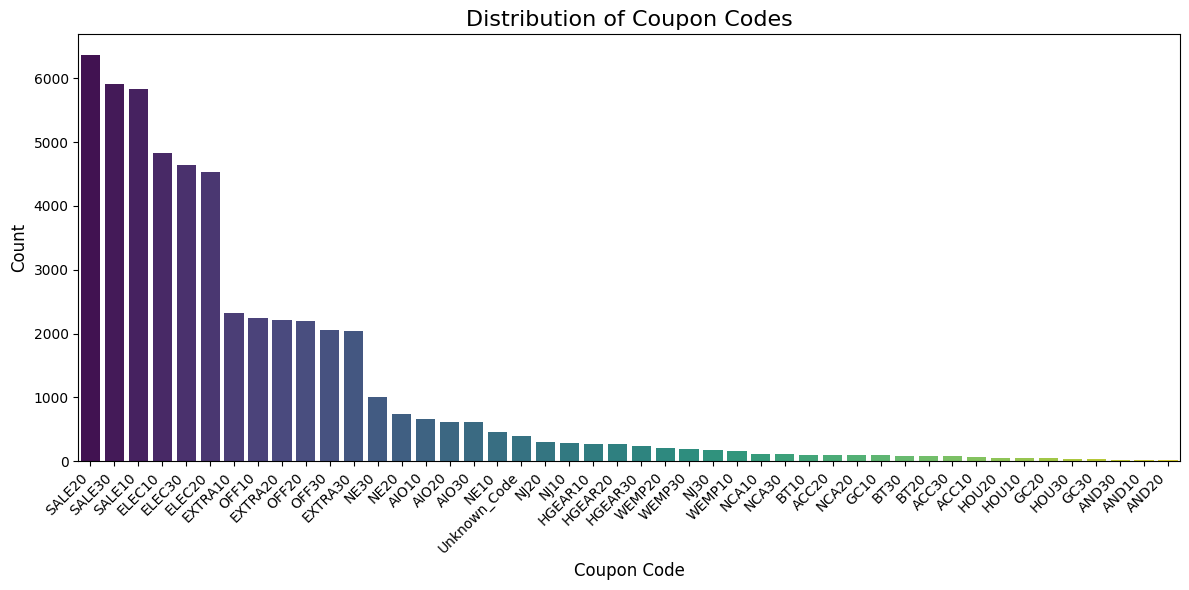

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Replace missing Coupon_Code values with a placeholder
df['Coupon_Code'] = df['Coupon_Code'].fillna('Unknown_Code')

# Plot distribution
plt.figure(figsize=(12, 6))
coupon_counts = df['Coupon_Code'].value_counts()
sns.barplot(x=coupon_counts.index, y=coupon_counts.values, palette='viridis')

plt.title('Distribution of Coupon Codes', fontsize=16)
plt.xlabel('Coupon Code', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [10]:
df.isnull().sum()

,0
ID,0
CustomerID,0
Gender,0
Location,0
Tenure_Months,0
Transaction_ID,0
Transaction_Date,0
Product_SKU,0
Product_Description,0
Product_Category,0


# Univariate Analysis

## Categorical Features

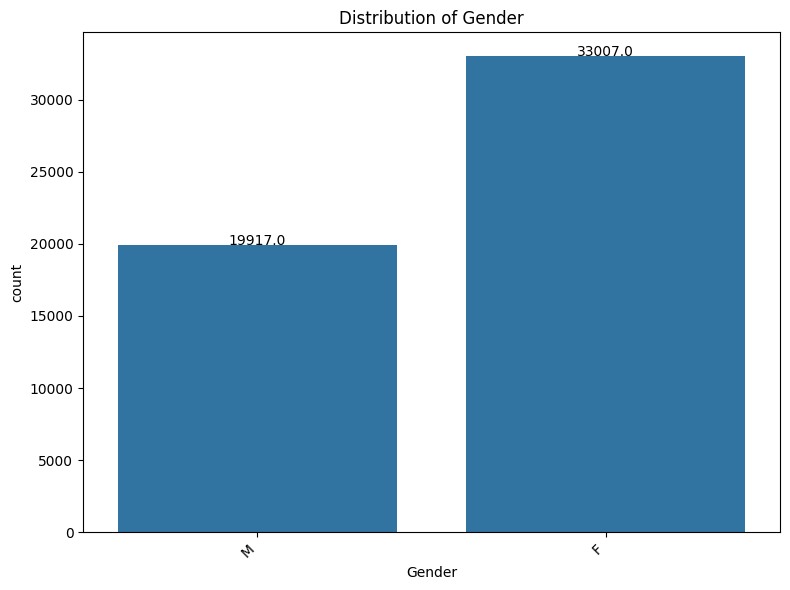

In [11]:
plt.figure(figsize=(8, 6))  # Create a new figure for each plot
ax = sns.countplot(data=df, x='Gender')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title(f'Distribution of {"Gender"}')

    # Add count labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.1,
    f'{height}',
    ha='center')
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

Important Notes There are two categories represented: 'M' and 'F'.
- The bar for 'F' (Female) is significantly taller than the bar for 'M' (Male).
- The exact counts are labeled on top of each bar: approximately 33,007 for Female and 19,917 for Male.
- The number of females is roughly 1.66 times the number of males

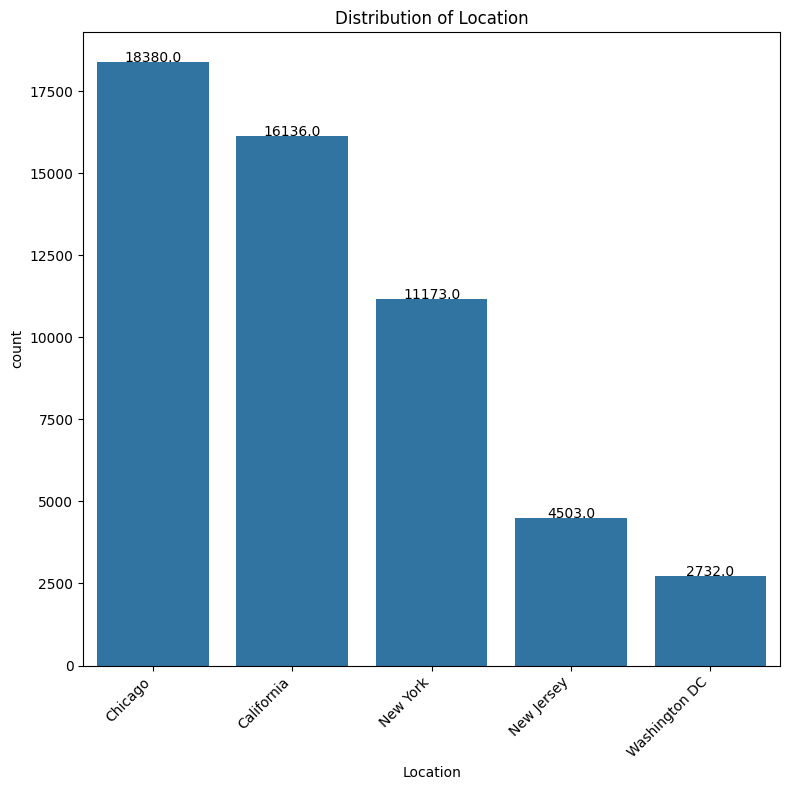

In [12]:
plt.figure(figsize=(8, 8))  # Create a new figure for each plot
ax = sns.countplot(data=df, x='Location')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title(f'Distribution of {"Location"}')

    # Add count labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.1,
    f'{height}',
    ha='center')
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [13]:
df["Location"].unique()

array(['Chicago', 'California', 'New York', 'New Jersey', 'Washington DC'],
      dtype=object)

Distribution of Location
- from this chart Chicago is dominant location from the dataset and next to that California .
- After that Decreasing  drastic Trend for New York .
- Chicago and California together make up a significant portion (over 60%) of the data.

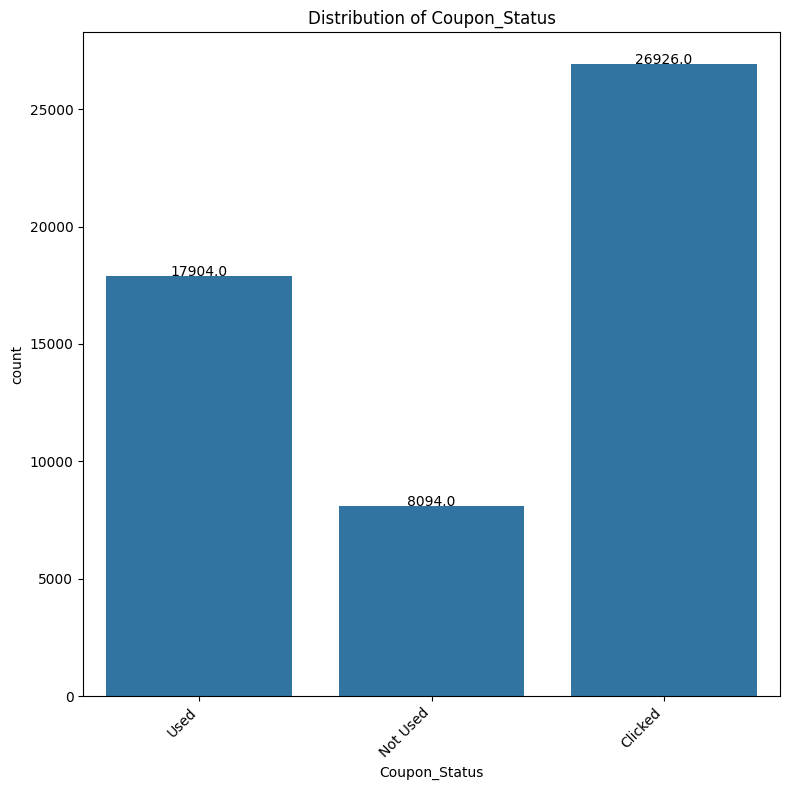

In [14]:
plt.figure(figsize=(8, 8))  # Create a new figure for each plot
ax = sns.countplot(data=df, x='Coupon_Status')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title(f'Distribution of {"Coupon_Status"}')

    # Add count labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.1,
    f'{height}',
    ha='center')
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

Distribution of Coupon Status
- from this  Most of the Coupon where Clicked though , it count much higher than
 compare to other .
- Next to that major used the coupon  

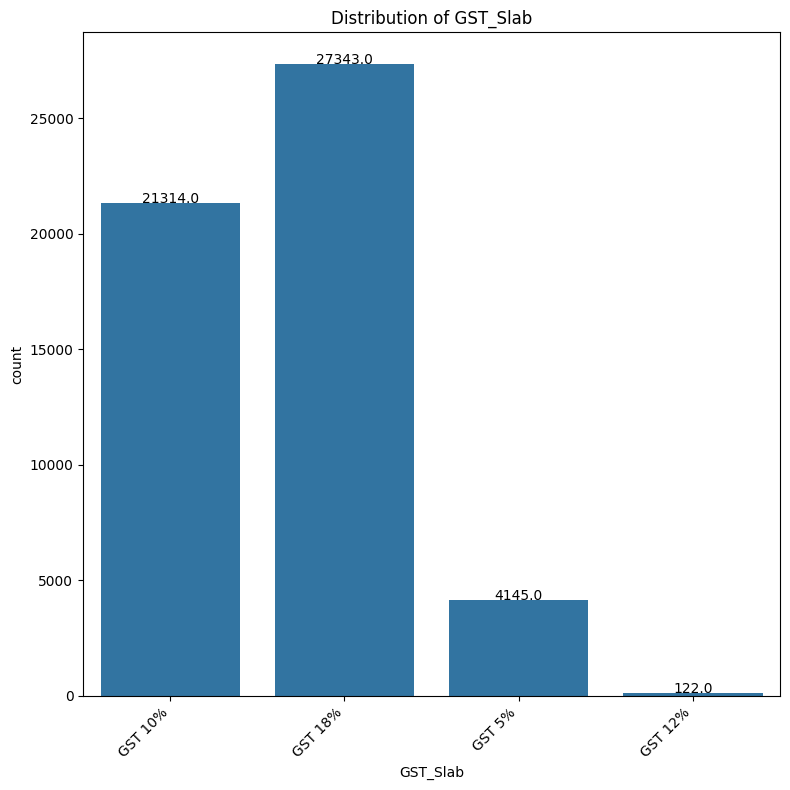

In [15]:
plt.figure(figsize=(8, 8))  # Create a new figure for each plot
ax = sns.countplot(data=df, x='GST_Slab')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title(f'Distribution of {"GST_Slab"}')

    # Add count labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.1,
    f'{height}',
    ha='center')
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

Distribution of GST
- so major product where applied with GST 18 % where it come under Google product Category which is 51% .
- Next to that GST 10 % with second major count and GST 12 % is very least withh 122 .

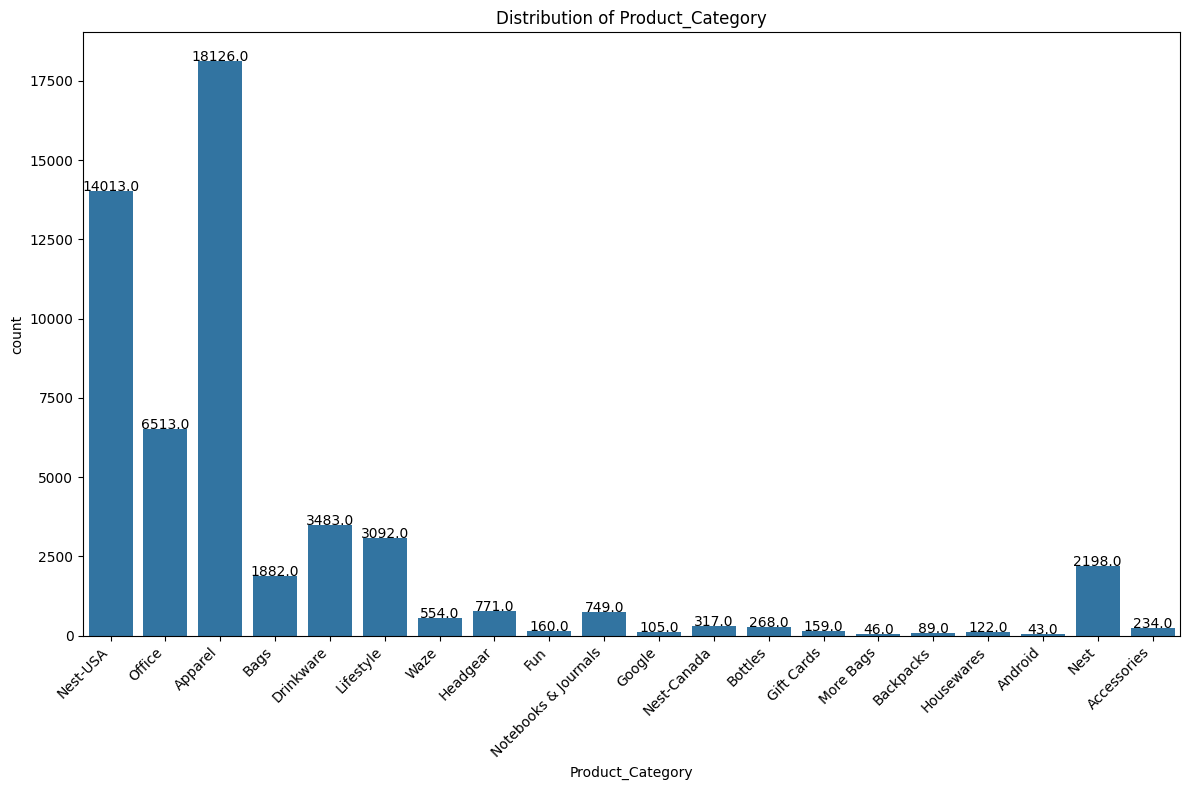

In [16]:
plt.figure(figsize=(12, 8))  # Create a new figure for each plot
ax = sns.countplot(data=df, x='Product_Category')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title(f'Distribution of {"Product_Category"}')

    # Add count labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.1,
    f'{height}',
    ha='center')
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

Product category distribution
- Highly Prevalent Categories (Significant Majority): "Apparel" together constitute a substantial portion (around 57.7%) of the product categories in your dataset.
- Moderately Represented Categories (Noticeable Presence): "Office" , "Drinkware", and "Lifestyle" represent a noticeable segment of the data, totaling around 23.6%.


Offline_Spend
  Skewness     : -0.32
  Kurtosis     : 0.10
  Min (adj)    : 1000.00
  Q1           : 2500.00
  Median       : 3000.00
  Q3           : 3500.00
  Max (adj)    : 5000.00


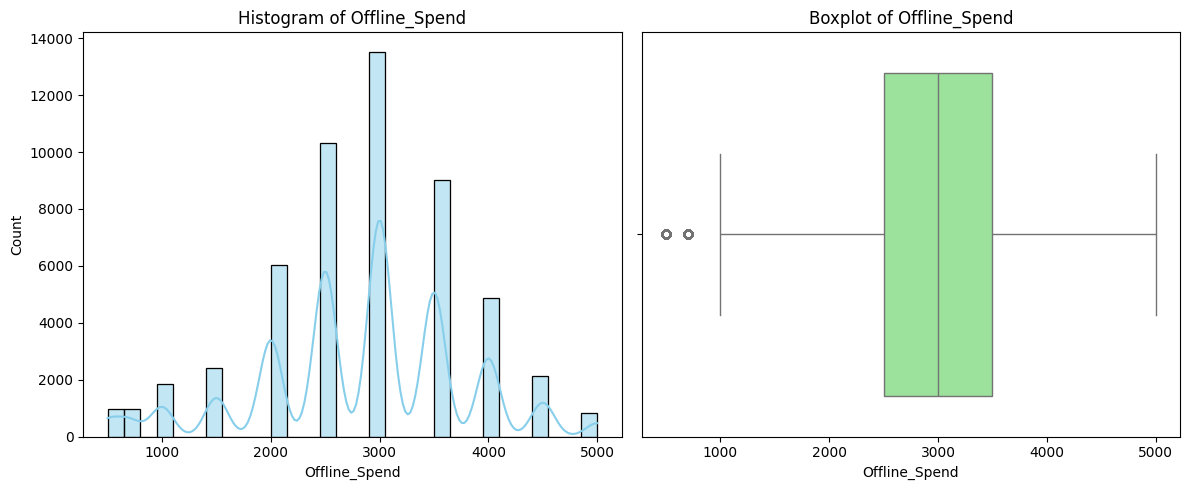

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Assuming 'df' is your DataFrame
col = 'Offline_Spend'

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue')
plt.title(f'Histogram of {col}')
plt.xlabel(col)

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f'Boxplot of {col}')
plt.xlabel(col)

# Skewness & Kurtosis
col_skew = skew(df[col].dropna())
col_kurt = kurtosis(df[col].dropna())

# Boxplot statistics
desc = df[col].describe()
Q1 = desc['25%']
Q3 = desc['75%']
IQR = Q3 - Q1
lower_whisker = max(desc['min'], Q1 - 1.5 * IQR)
upper_whisker = min(desc['max'], Q3 + 1.5 * IQR)
median = desc['50%']

print(f"\n{col}")
print(f"  Skewness     : {col_skew:.2f}")
print(f"  Kurtosis     : {col_kurt:.2f}")
print(f"  Min (adj)    : {lower_whisker:.2f}")
print(f"  Q1           : {Q1:.2f}")
print(f"  Median       : {median:.2f}")
print(f"  Q3           : {Q3:.2f}")
print(f"  Max (adj)    : {upper_whisker:.2f}")

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame and 'Offline_Spend' is the column
col = 'Offline_Spend'
num_bins = 5  # You can adjust the number of bins as needed

print(f"\n--- Distribution Percentage for {col} ---")

# Create bins using pd.cut
binned_data = pd.cut(df[col], bins=num_bins)
bin_counts = binned_data.value_counts(normalize=True).sort_index()

# Convert to percentage
distribution_pct = (bin_counts * 100).round(2)

# Display the distribution as percentages
print(distribution_pct.to_string())

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Bin': bin_counts.index,
    'Percentage': distribution_pct.values
})




--- Distribution Percentage for Offline_Spend ---
Offline_Spend
(495.5, 1400.0]      7.17
(1400.0, 2300.0]    15.93
(2300.0, 3200.0]    45.09
(3200.0, 4100.0]    26.25
(4100.0, 5000.0]     5.57


In Summary:
- Slightly Negatively Skewed: The skewness value of -0.32 indicates a slight negative skew.
- The kurtosis value of 0.10 is close to zero, suggesting a platykurtic distribution.distribution has flatter peaks and thinner tails compared to a normal distribution.
- Central Tendency: Median > Mean (Implied): Since the skew is slightly negative, we would expect the mean to be slightly less than the median. The median is reported as 3000.


Online_Spend
  Skewness     : 0.45
  Kurtosis     : -0.15
  Min (adj)    : 320.25
  Q1           : 1252.63
  Median       : 1837.87
  Q3           : 2425.35
  Max (adj)    : 4184.43


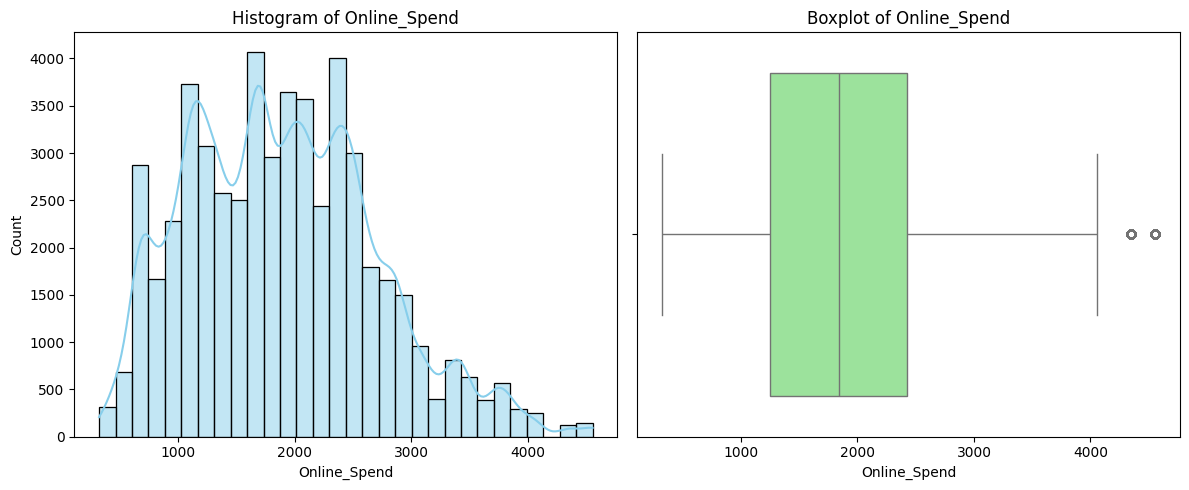


--- Distribution Percentage for Online_Spend ---
Online_Spend
(316.013, 1167.586]     21.84
(1167.586, 2014.922]    35.57
(2014.922, 2862.258]    31.10
(2862.258, 3709.594]     8.88
(3709.594, 4556.93]      2.61


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Assuming 'df' is your DataFrame
col = 'Online_Spend'

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue')
plt.title(f'Histogram of {col}')
plt.xlabel(col)

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f'Boxplot of {col}')
plt.xlabel(col)

# Skewness & Kurtosis
col_skew = skew(df[col].dropna())
col_kurt = kurtosis(df[col].dropna())

# Boxplot statistics
desc = df[col].describe()
Q1 = desc['25%']
Q3 = desc['75%']
IQR = Q3 - Q1
lower_whisker = max(desc['min'], Q1 - 1.5 * IQR)
upper_whisker = min(desc['max'], Q3 + 1.5 * IQR)
median = desc['50%']

print(f"\n{col}")
print(f"  Skewness     : {col_skew:.2f}")
print(f"  Kurtosis     : {col_kurt:.2f}")
print(f"  Min (adj)    : {lower_whisker:.2f}")
print(f"  Q1           : {Q1:.2f}")
print(f"  Median       : {median:.2f}")
print(f"  Q3           : {Q3:.2f}")
print(f"  Max (adj)    : {upper_whisker:.2f}")

plt.tight_layout()
plt.show()
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame and 'Offline_Spend' is the column
col = 'Online_Spend'
num_bins = 5  # You can adjust the number of bins as needed

print(f"\n--- Distribution Percentage for {col} ---")

# Create bins using pd.cut
binned_data = pd.cut(df[col], bins=num_bins)
bin_counts = binned_data.value_counts(normalize=True).sort_index()

# Convert to percentage
distribution_pct = (bin_counts * 100).round(2)

# Display the distribution as percentages
print(distribution_pct.to_string())

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Bin': bin_counts.index,
    'Percentage': distribution_pct.values
})

In Summary:
- Distribution Shape :Right Skewed: The skewness value of 0.45 indicates a positive or right skew.The bulk of the data is concentrated on the left side.
- Central Tendency: Median < Mean (Implied): With a positive skew, The histogram shows the highest bars are generally in the lower spending ranges, indicating a larger number of customers with lower online spending.
- Spread and Variability: This represents the range within which the middle 50% of the online spending values fall.he box in the boxplot is positioned towards the lower end of the spending range, reflecting the right skew


Quantity
  Skewness     : 19.03
  Kurtosis     : 525.40
  Min (adj)    : 1.00
  Q1           : 1.00
  Median       : 1.00
  Q3           : 2.00
  Max (adj)    : 3.50


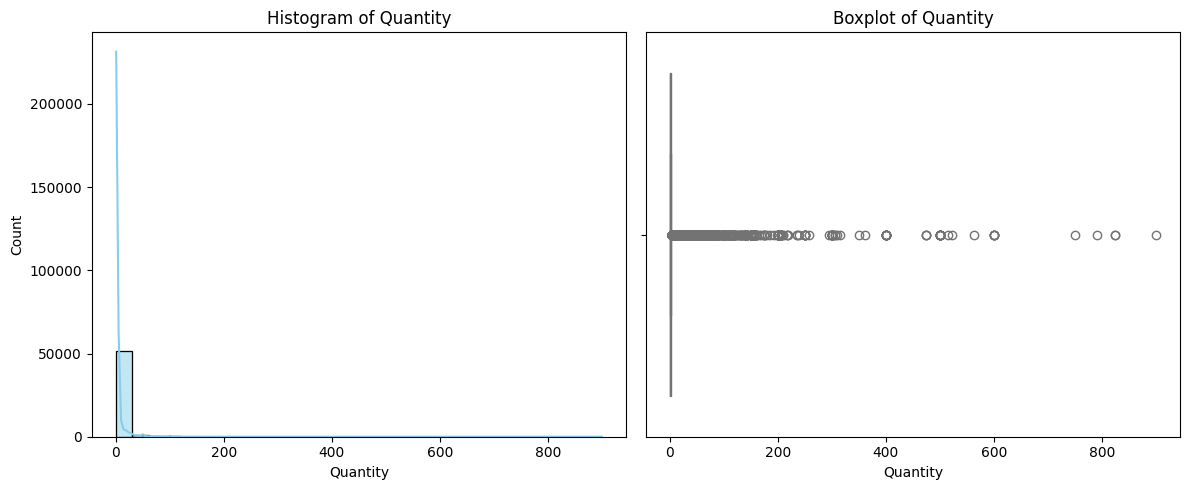


--- Distribution Percentage for Quantity ---
Quantity
(0.101, 180.8]    99.80
(180.8, 360.6]     0.13
(360.6, 540.4]     0.05
(540.4, 720.2]     0.01
(720.2, 900.0]     0.01


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Assuming 'df' is your DataFrame
col = 'Quantity'

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue')
plt.title(f'Histogram of {col}')
plt.xlabel(col)

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f'Boxplot of {col}')
plt.xlabel(col)

# Skewness & Kurtosis
col_skew = skew(df[col].dropna())
col_kurt = kurtosis(df[col].dropna())

# Boxplot statistics
desc = df[col].describe()
Q1 = desc['25%']
Q3 = desc['75%']
IQR = Q3 - Q1
lower_whisker = max(desc['min'], Q1 - 1.5 * IQR)
upper_whisker = min(desc['max'], Q3 + 1.5 * IQR)
median = desc['50%']

print(f"\n{col}")
print(f"  Skewness     : {col_skew:.2f}")
print(f"  Kurtosis     : {col_kurt:.2f}")
print(f"  Min (adj)    : {lower_whisker:.2f}")
print(f"  Q1           : {Q1:.2f}")
print(f"  Median       : {median:.2f}")
print(f"  Q3           : {Q3:.2f}")
print(f"  Max (adj)    : {upper_whisker:.2f}")

plt.tight_layout()
plt.show()
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame and 'Offline_Spend' is the column
col = 'Quantity'
num_bins = 5  # You can adjust the number of bins as needed

print(f"\n--- Distribution Percentage for {col} ---")

# Create bins using pd.cut
binned_data = pd.cut(df[col], bins=num_bins)
bin_counts = binned_data.value_counts(normalize=True).sort_index()

# Convert to percentage
distribution_pct = (bin_counts * 100).round(2)

# Display the distribution as percentages
print(distribution_pct.to_string())

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Bin': bin_counts.index,
    'Percentage': distribution_pct.values
})

 distribution of 'Quantity'
 - Distribution Shape:Extremely Right Skewed: The skewness value of 19.03 is exceptionally high, indicating a massive positive skew.
 - This signifies a very peaked distribution around the most frequent values and extremely fat tails with rare, very high quantity purchases.
- Spread and Variability:Very Low IQR  This extremely small IQR highlights the highly concentrated nature of the data around the value of 1.
- (0.101, 180.8]: 99.80% - An overwhelming majority (99.80%) of the transactions involve quantities within this lower range.

In Summary:
- The 'Quantity' data reveals a strong tendency for customers to purchase in very small quantities, predominantly just 1 unit.
- These are extremely rare, making up only about 0.20% of all transcation


Avg_Price
  Skewness     : 1.63
  Kurtosis     : 3.34
  Min (adj)    : 0.39
  Q1           : 5.70
  Median       : 16.99
  Q3           : 102.13
  Max (adj)    : 246.77


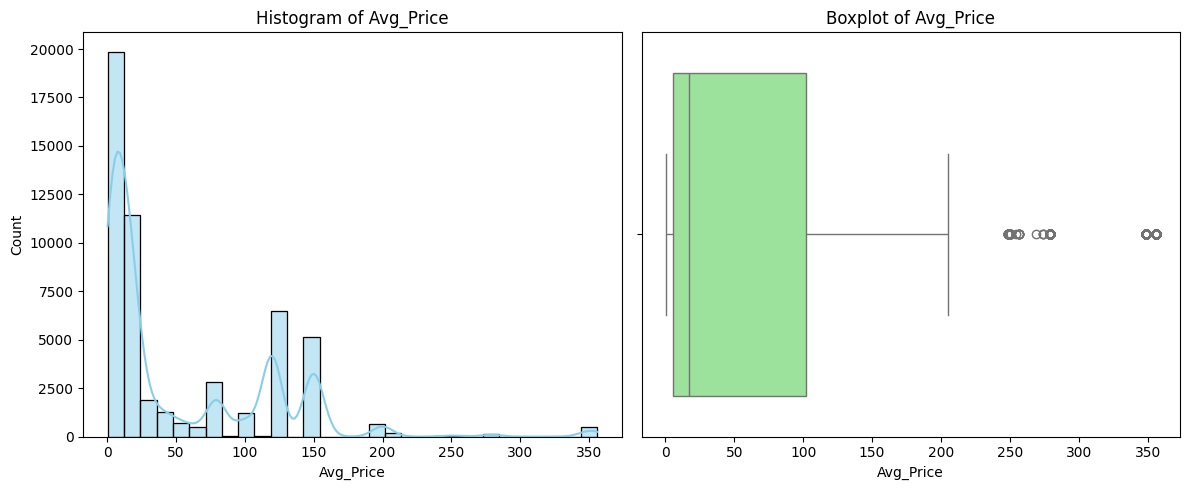


--- Distribution Percentage for Avg_Price ---
Avg_Price
(0.0346, 71.46]     67.46
(71.46, 142.53]     19.94
(142.53, 213.6]     11.23
(213.6, 284.67]      0.43
(284.67, 355.74]     0.94


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Assuming 'df' is your DataFrame
col = 'Avg_Price'

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue')
plt.title(f'Histogram of {col}')
plt.xlabel(col)

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f'Boxplot of {col}')
plt.xlabel(col)

# Skewness & Kurtosis
col_skew = skew(df[col].dropna())
col_kurt = kurtosis(df[col].dropna())

# Boxplot statistics
desc = df[col].describe()
Q1 = desc['25%']
Q3 = desc['75%']
IQR = Q3 - Q1
lower_whisker = max(desc['min'], Q1 - 1.5 * IQR)
upper_whisker = min(desc['max'], Q3 + 1.5 * IQR)
median = desc['50%']

print(f"\n{col}")
print(f"  Skewness     : {col_skew:.2f}")
print(f"  Kurtosis     : {col_kurt:.2f}")
print(f"  Min (adj)    : {lower_whisker:.2f}")
print(f"  Q1           : {Q1:.2f}")
print(f"  Median       : {median:.2f}")
print(f"  Q3           : {Q3:.2f}")
print(f"  Max (adj)    : {upper_whisker:.2f}")

plt.tight_layout()
plt.show()
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame and 'Offline_Spend' is the column
col = 'Avg_Price'
num_bins = 5  # You can adjust the number of bins as needed

print(f"\n--- Distribution Percentage for {col} ---")

# Create bins using pd.cut
binned_data = pd.cut(df[col], bins=num_bins)
bin_counts = binned_data.value_counts(normalize=True).sort_index()

# Convert to percentage
distribution_pct = (bin_counts * 100).round(2)

# Display the distribution as percentages
print(distribution_pct.to_string())

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Bin': bin_counts.index,
    'Percentage': distribution_pct.values
})

- Distribution Shape: Right Skewed: The skewness of 1.63 confirms a positive or right skew. The histogram clearly shows a high frequency of lower average prices,
- Central Tendency: Median > Q1: The median (16.99) is significantly higher than the first quartile (5.70), which is typical for a right-skewed distribution
- In Summary:
The 'Avg_Price' distribution is heavily skewed to the right, with most transactions having relatively low average prices. A substantial 67.46% of the average prices are below 71.46. As the average price increases, the percentage of transactions decreases significantly. The presence of potential outliers indicates some transactions with exceptionally high average prices, although these are relatively rare.

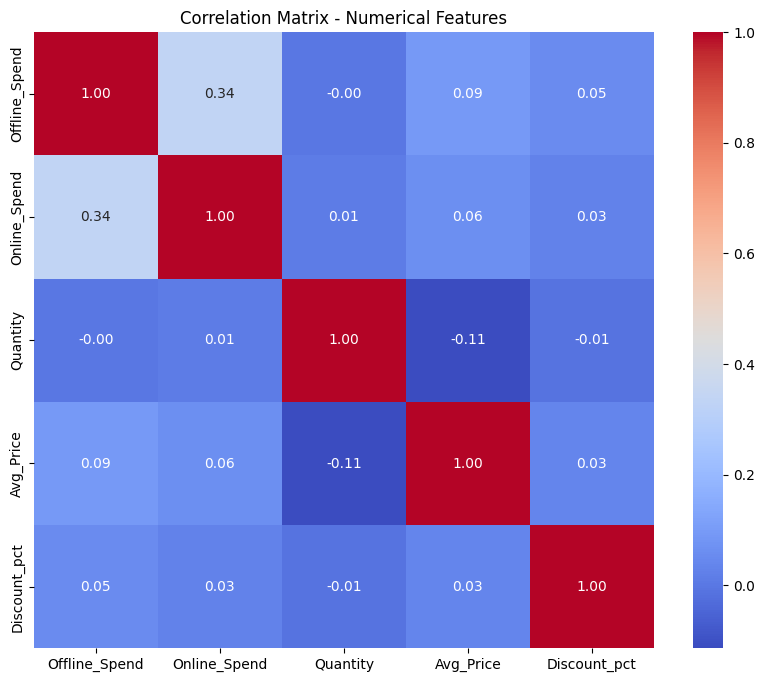

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
corr = df[['Offline_Spend', 'Online_Spend', 'Quantity', 'Avg_Price', 'Discount_pct']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix - Numerical Features')
plt.show()


Overall Observations
- Weak Linear Relationships: Most of the correlations are quite weak (close to zero). This implies that for many of these pairs of variables, there isn't a strong linear tendency for them to move together in a predictable way.
- Offline vs. Online Spending: The most noticeable (though still weak) positive relationship is between offline and online spending.
- Quantity and Average Price: The weak negative correlation between quantity and average price is the most apparent inverse relationship.
- Discount Percentage: The discount percentage seems to have very little linear relationship with the other spending and quantity variables in this dataset.

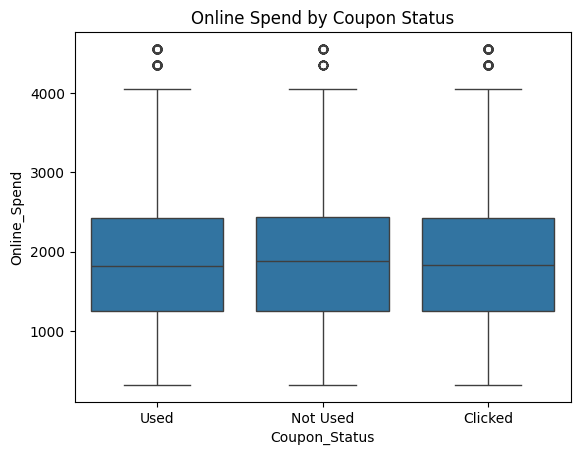

In [23]:
sns.boxplot(data=df, x='Coupon_Status', y='Online_Spend')
plt.title('Online Spend by Coupon Status')
plt.show()


Comparison Across Coupon Status Categories:
- Coupon Usage and Spending: Customers who used a coupon tend to have a slightly higher median online spend compared to those who didn't or only clicked. This might suggest that coupons are effective in encouraging higher spending among those who redeem them.
- Clicking vs. Not Using: The online spending patterns for those who clicked on a coupon and those who didn't use one are quite similar in terms of median and spread.
- Spread of Spending: The spread of the middle 50% of online spending is relatively consistent across all three coupon status groups, suggesting a similar level of variability in spending within the typical customer base for each group.

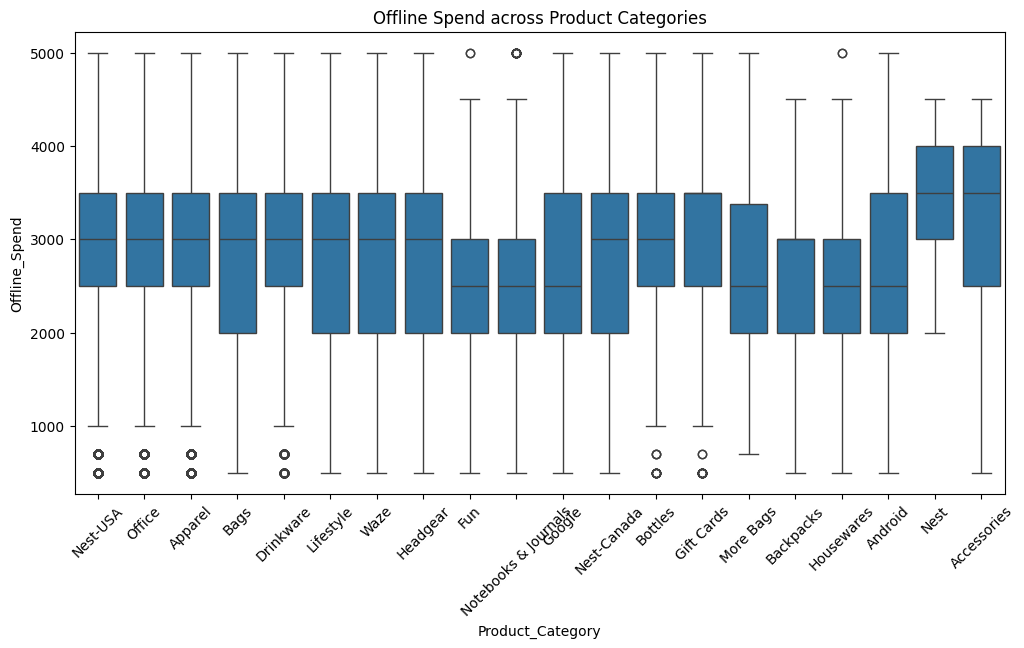

In [24]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Product_Category', y='Offline_Spend')
plt.xticks(rotation=45)
plt.title('Offline Spend across Product Categories')
plt.show()


Key Observations
- Product Type Influence: The type of product significantly influences offline spending. Categories like 'Nest' products, 'Housewares', and 'Android' related items seem to drive higher offline spending, possibly due to the higher value of these goods.
- Variability within Categories: The varying spread within each boxplot highlights that even within a specific product category, customer spending habits can differ considerably.

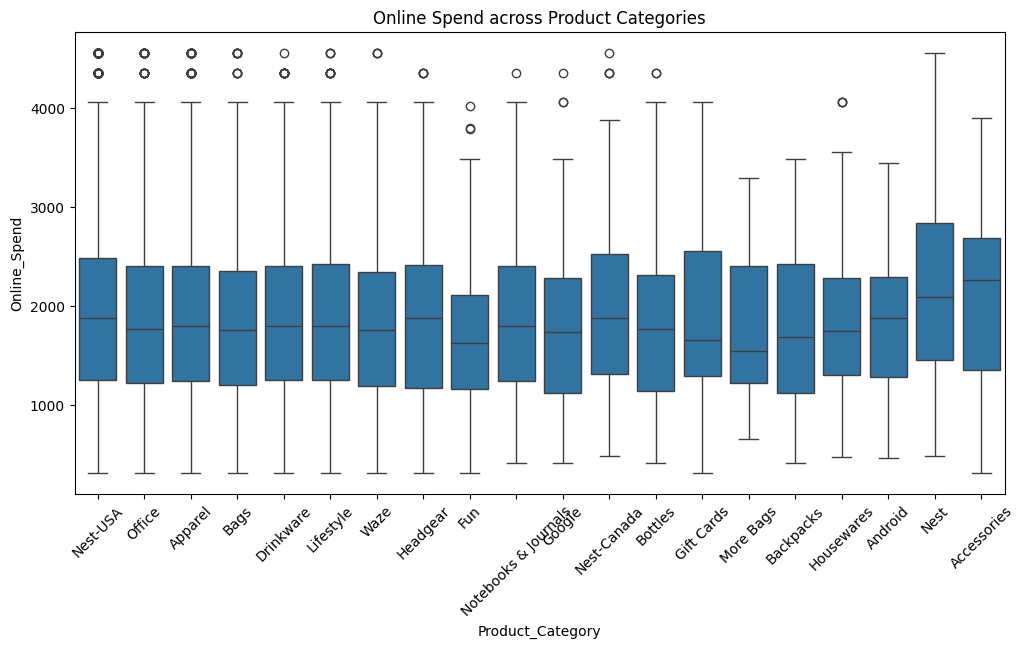

In [25]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Product_Category', y='Online_Spend')
plt.xticks(rotation=45)
plt.title('Online Spend across Product Categories')
plt.show()


Key Observations
- Spending Consistency: Categories with narrower boxes suggest more consistent online spending habits among customers purchasing those items online.
- High-Value Customers: The presence of outliers indicates high-value customers in various product categories. Understanding the characteristics of these customers could be valuable for targeted marketing efforts.

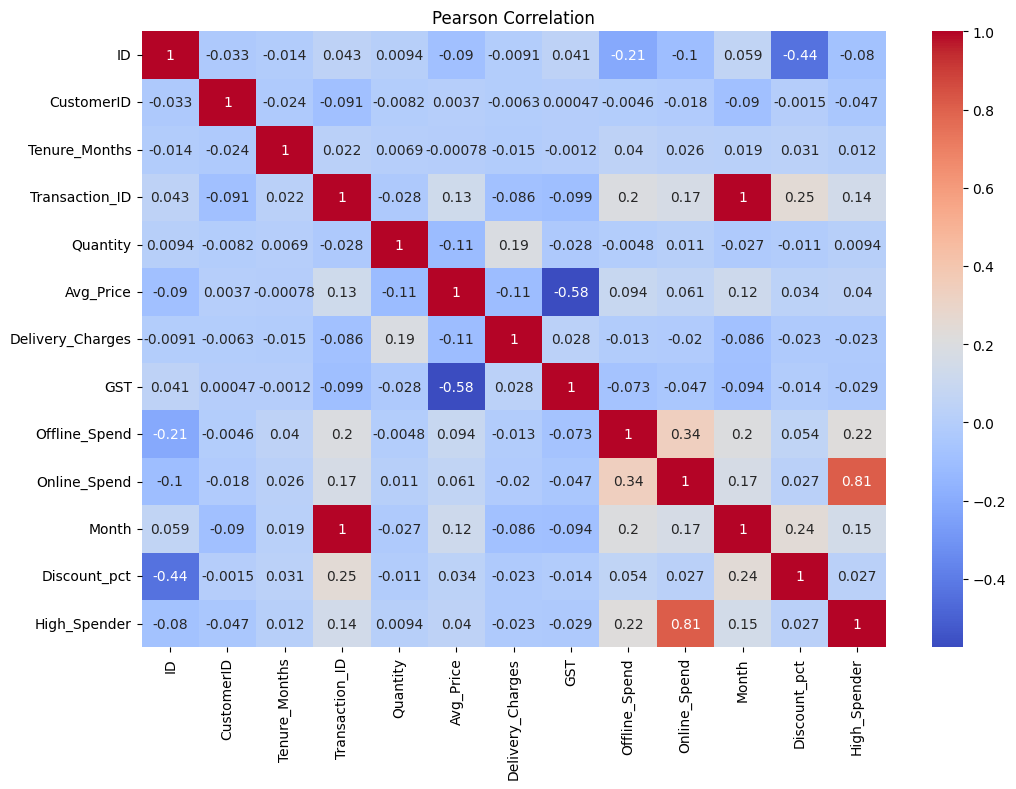

In [26]:
pearson_corr = df.corr(method='pearson', numeric_only=True)

# Adjust the figure size using plt.figure()
plt.figure(figsize=(12, 8))  # Example: Width=12, Height=8

sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title('Pearson Correlation')
plt.show()

In summary, this correlation matrix highlights a strong positive relationship between online spending and being a high spender, a moderate positive relationship between offline and online spending, and moderate negative relationships between discount percentage and being a high spender, and between average price and GST. Most other linear relationships appear to be weak. Remember to consider the limitations of correlation analysis when interpreting these results.

# T test

In [27]:
from scipy import stats

# Assuming df is your DataFrame
avg_price_values = df['Avg_Price'].dropna()
gst_values = df['GST'].dropna()

# Perform independent samples t-test
if len(avg_price_values) > 1 and len(gst_values) > 1:
    t_statistic, p_value = stats.ttest_ind(avg_price_values, gst_values)
    print(f"T-statistic: {t_statistic:.3f}")
    print(f"P-value: {p_value:.3f}")
else:
    print("Not enough data points in one or both columns to perform the t-test.")

T-statistic: 187.257
P-value: 0.000


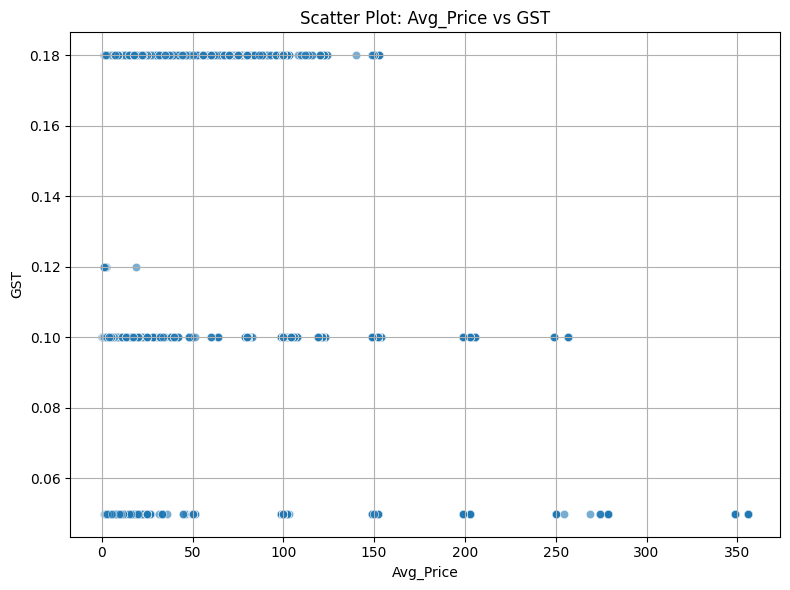

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Avg_Price'], y=df['GST'], alpha=0.6)
plt.title('Scatter Plot: Avg_Price vs GST')
plt.xlabel('Avg_Price')
plt.ylabel('GST')
plt.grid(True)
plt.tight_layout()
plt.show()


From performing the T -test also proofs that there is signifcance between the Avg price and GST  , in terms of direction is negative

In [29]:
from scipy import stats

# Assuming df is your DataFrame
avg_price_values = df['Online_Spend'].dropna()
gst_values = df['High_Spender'].dropna()

# Perform independent samples t-test
if len(avg_price_values) > 1 and len(gst_values) > 1:
    t_statistic, p_value = stats.ttest_ind(avg_price_values, gst_values)
    print(f"T-statistic: {t_statistic:.3f}")
    print(f"P-value: {p_value:.3f}")
else:
    print("Not enough data points in one or both columns to perform the t-test.")

T-statistic: 539.518
P-value: 0.000


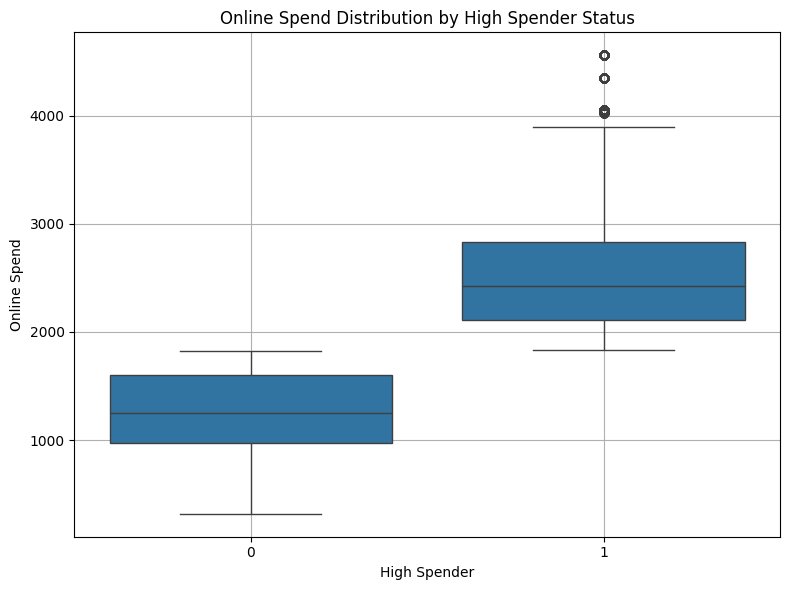

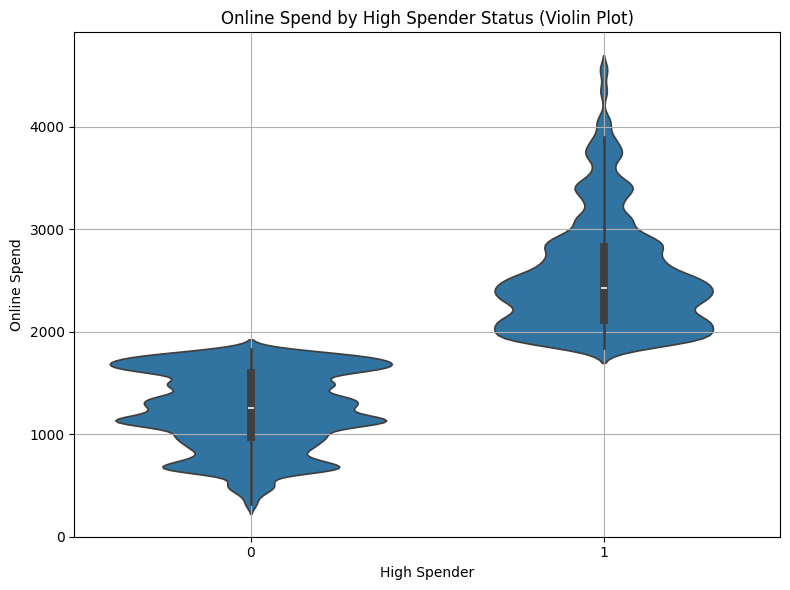

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='High_Spender', y='Online_Spend', data=df)
plt.title('Online Spend Distribution by High Spender Status')
plt.xlabel('High Spender')
plt.ylabel('Online Spend')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))
sns.violinplot(x='High_Spender', y='Online_Spend', data=df, inner='box')
plt.title('Online Spend by High Spender Status (Violin Plot)')
plt.xlabel('High Spender')
plt.ylabel('Online Spend')
plt.grid(True)
plt.tight_layout()
plt.show()


Key Observations and Interpretations:
- Higher Spending by High Spenders: The entire distribution of online spending for high spenders is generally higher than for the other group.
- Greater Variability Among High Spenders: The box for the "High Spender" group appears taller than the box for the other group, indicating a larger interquartile range and thus greater variability in online spending among high spenders

In summary
- the box plot clearly demonstrates that customers identified as "High Spenders" tend to spend considerably more online, and their spending amounts also show greater variability with some very high-spending individuals within this group.

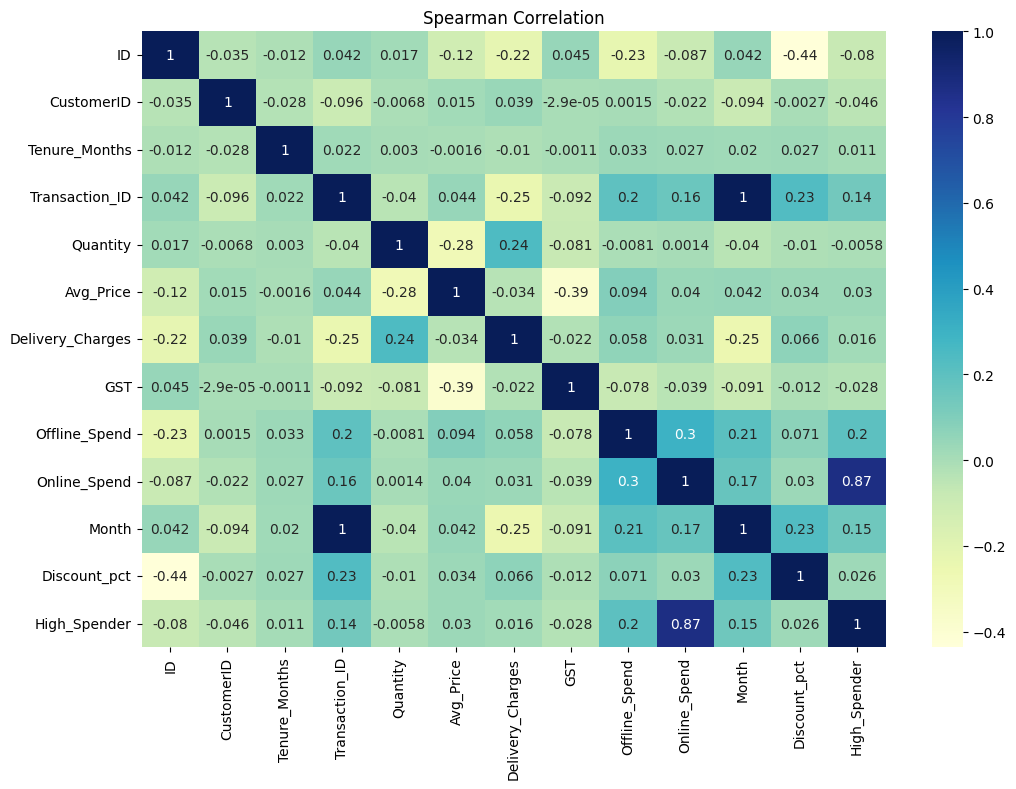

In [31]:
spearman_corr = df.corr(method='spearman', numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(spearman_corr, annot=True, cmap='YlGnBu')
plt.title('Spearman Correlation')
plt.show()


Here's an interpretation of the more notable Spearman correlations:
In summary, this Spearman correlation matrix reinforces some of the findings from the Pearson matrix and provides additional insights into the monotonic relationships between the variables. The stronger correlations for 'Online_Spend' vs. 'High_Spender' and 'Avg_Price' vs. 'GST' in the Spearman matrix suggest that these relationships might be non-linear but consistently directional.

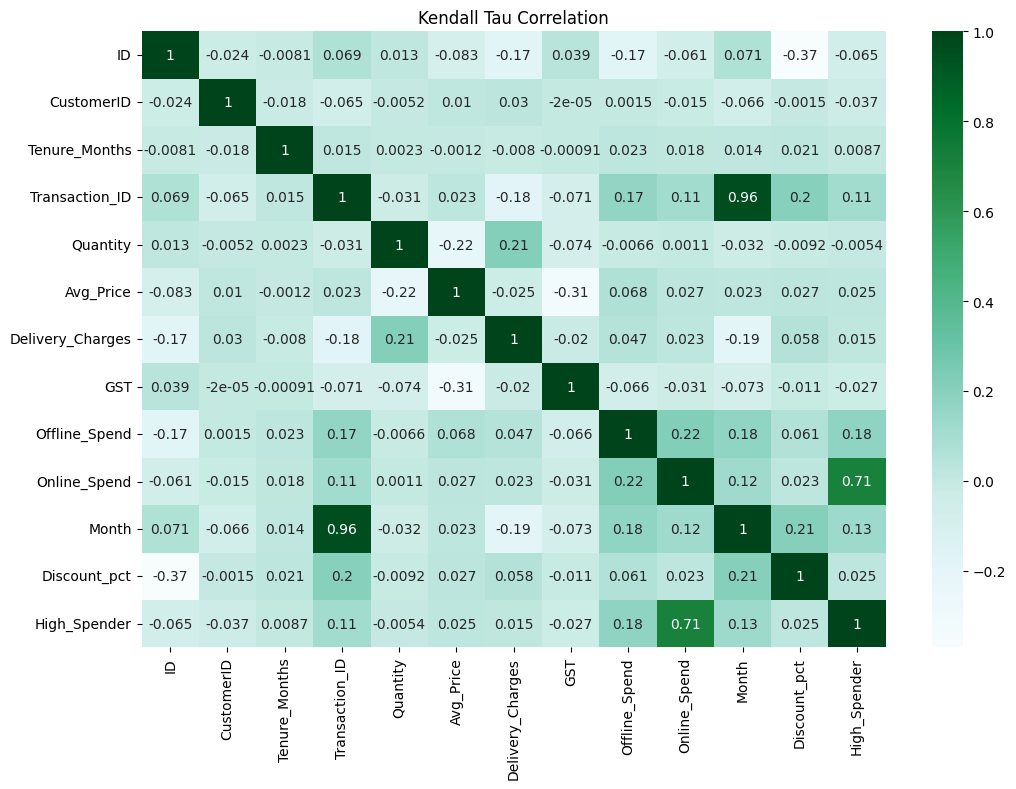

In [32]:
kendall_corr = df.corr(method='kendall', numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(kendall_corr, annot=True, cmap='BuGn')
plt.title('Kendall Tau Correlation')
plt.show()


Here's an interpretation of the more notable Kendall Tau correlations:
In summary, this Kendall Tau correlation matrix confirms the direction of the relationships observed with Pearson and Spearman, highlighting a strong positive monotonic relationship between online spending and being a high spender, a very strong positive monotonic relationship between transaction ID and month, and a weak to moderate negative monotonic relationship between discount percentage and being a high spender, as well as between average price and GST. The generally lower magnitudes are characteristic of the Kendall Tau statistic.

ANOVA / Eta Squared (Categorical vs Numerical)

In [33]:
from scipy.stats import chi2_contingency

cat_cols = ['Gender', 'Location', 'Coupon_Status', 'GST_Slab', 'Product_Category']

for col in cat_cols:
    table = pd.crosstab(df[col], df['High_Spender'])
    chi2, p, dof, _ = chi2_contingency(table)
    print(f"Chi-square test between {col} and High_Spender → p-value: {p:.8f}")


Chi-square test between Gender and High_Spender → p-value: 0.00503140
Chi-square test between Location and High_Spender → p-value: 0.00000000
Chi-square test between Coupon_Status and High_Spender → p-value: 0.09228801
Chi-square test between GST_Slab and High_Spender → p-value: 0.00000000
Chi-square test between Product_Category and High_Spender → p-value: 0.00000000


Here's a breakdown of each test result:

Chi-square test between Gender and High_Spender → p-value: 0.0050

The p-value (0.0050) is less than the common significance level of 0.05.
Interpretation: There is a statistically significant association between Gender and whether a customer is a High_Spender. This suggests that the proportion of high spenders differs significantly between the different gender categories in your dataset.
Chi-square test between Location and High_Spender → p-value: 0.0000

The p-value (0.0000, practically zero) is much less than 0.05.
Interpretation: There is a highly statistically significant association between Location and whether a customer is a High_Spender. This indicates that the distribution of high spenders varies significantly across different locations in your dataset. Location seems to be a strong factor in determining who is a high spender.
Chi-square test between Coupon_Status and High_Spender → p-value: 0.0923

The p-value (0.0923) is greater than the common significance level of 0.05.
Interpretation: There is no statistically significant association between Coupon_Status and whether a customer is a High_Spender at the 0.05 significance level. This suggests that the proportion of high spenders does not differ significantly across the different coupon status categories (e.g., Used, Not Used, Clicked) in your dataset.
Chi-square test between GST_Slab and High_Spender → p-value: 0.0000

The p-value (0.0000) is much less than 0.05.
Interpretation: There is a highly statistically significant association between GST_Slab and whether a customer is a High_Spender. This indicates that the distribution of high spenders varies significantly across different GST slabs of the products they purchase. The GST slab of purchased items appears to be related to whether a customer is a high spender.
Chi-square test between Product_Category and High_Spender → p-value: 0.0000

The p-value (0.0000) is much less than 0.05.
Interpretation: There is a highly statistically significant association between Product_Category and whether a customer is a High_Spender. This suggests that the proportion of high spenders differs significantly across the different product categories in your dataset. The type of products purchased is related to whether a customer is a high spender.
In summary:

Gender, Location, GST_Slab, and Product_Category all show a statistically significant association with whether a customer is a high spender. This means that these categorical variables are likely related to the spending habits of your customers.
Coupon_Status does not show a statistically significant association with whether a customer is a high spender at the 0.05 significance level. This suggests that the coupon status alone might not be a strong indicator of whether a customer is a high spender.

# Correlation & Multicollinearity Analysis:

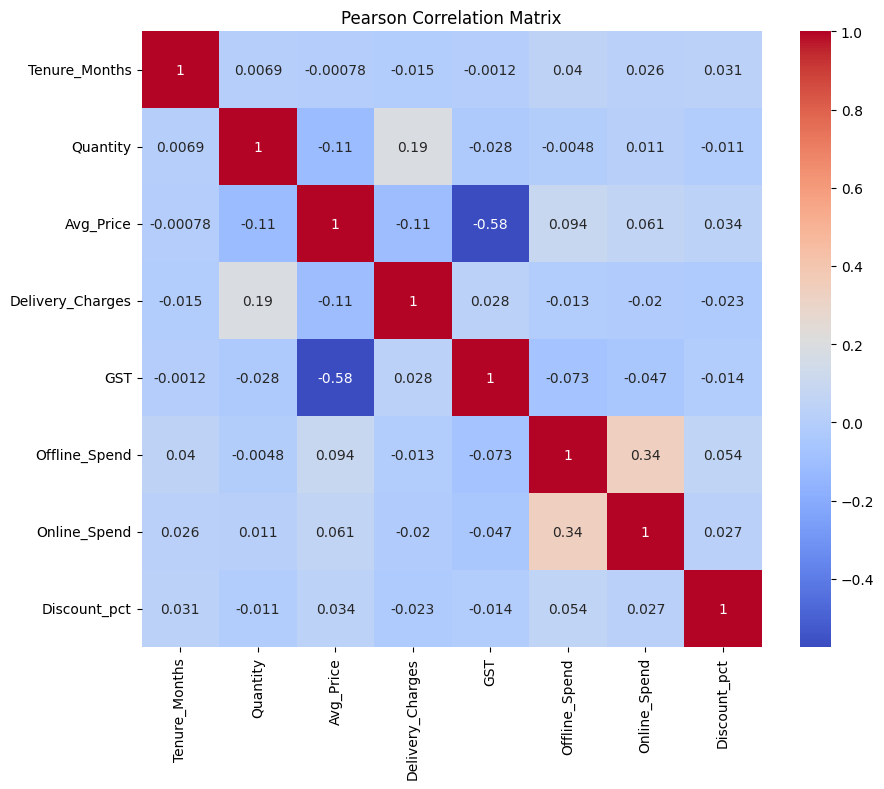

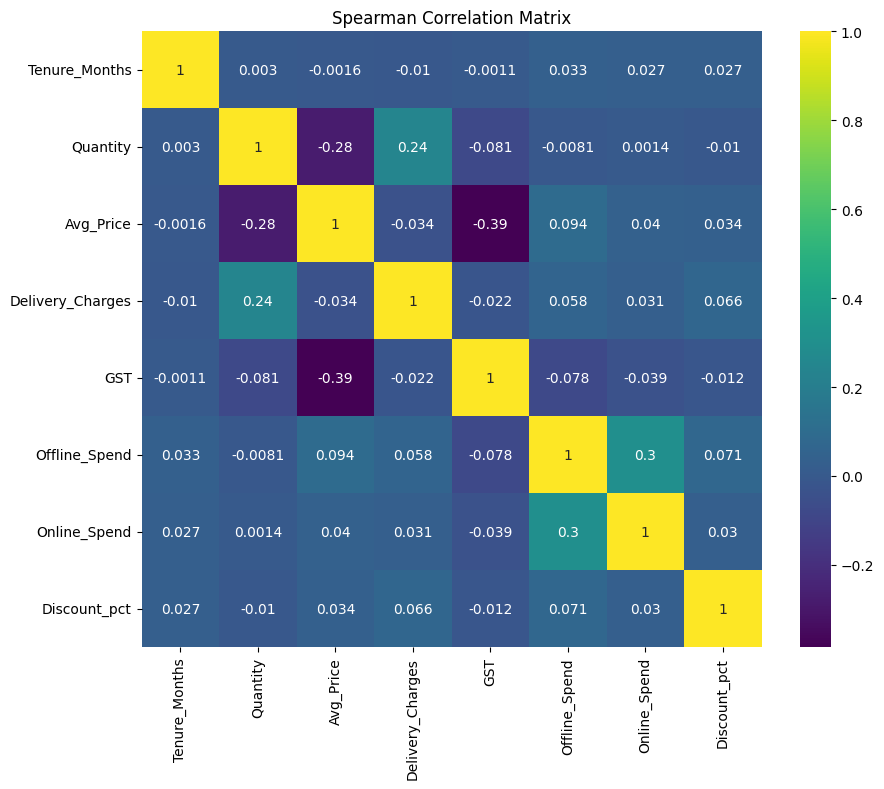

Variance Inflation Factors:
            feature       VIF
0     Tenure_Months  1.002943
1          Quantity  1.060805
2         Avg_Price  1.552707
3  Delivery_Charges  1.047525
4               GST  1.516566
5     Offline_Spend  1.138760
6      Online_Spend  1.129805
7      Discount_pct  1.005159


In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler



# Select continuous numeric features for correlation and VIF
numeric_cols = [
    'Tenure_Months', 'Quantity', 'Avg_Price', 'Delivery_Charges',
    'GST', 'Offline_Spend', 'Online_Spend', 'Discount_pct'
]
df_numeric = df[numeric_cols].dropna()

# Pearson Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(method='pearson'), annot=True, cmap='coolwarm')
plt.title('Pearson Correlation Matrix')
plt.show()

# Spearman Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(method='spearman'), annot=True, cmap='viridis')
plt.title('Spearman Correlation Matrix')
plt.show()

# Variance Inflation Factor (VIF)
# Standardize features before VIF computation
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=numeric_cols)

# Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = df_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(df_scaled.values, i) for i in range(df_scaled.shape[1])]

print("Variance Inflation Factors:")
print(vif_data)


Low Magnitudes: All the VIF values are quite low, with the highest being around 1.55 for Avg_Price. This indicates that multicollinearity is likely not a significant problem among the continuous numerical features you've selected.

# Group-wise Statistical Comparison

In [35]:
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, kruskal
import numpy as np

# Drop missing values in key columns
df = df.dropna(subset=['Gender', 'Online_Spend', 'Offline_Spend', 'Coupon_Status',
                       'Product_Category', 'Quantity', 'Discount_pct', 'GST', 'Tenure_Months'])

# 2. Coupon_Status effect on Online_Spend (ANOVA and Kruskal)
groups = [group['Online_Spend'].values for name, group in df.groupby('Coupon_Status')]
f_stat, p_val_anova = f_oneway(*groups)
h_stat, p_val_kruskal = kruskal(*groups)
print("ANOVA (Online Spend by Coupon_Status): F=%.3f, p=%.3f" % (f_stat, p_val_anova))
print("Kruskal-Wallis (Online Spend by Coupon_Status): H=%.3f, p=%.3f" % (h_stat, p_val_kruskal))



# 4. Tenure segmentation and spend behavior
bins = [0, 6, 12, np.inf]
labels = ['<6M', '6-12M', '>12M']
df['Tenure_Group'] = pd.cut(df['Tenure_Months'], bins=bins, labels=labels)

spend_groups = [group['Online_Spend'].values for name, group in df.groupby('Tenure_Group')]
f_tenure, p_tenure = f_oneway(*spend_groups)
print("ANOVA (Online Spend by Tenure Group): F=%.3f, p=%.3f" % (f_tenure, p_tenure))


ANOVA (Online Spend by Coupon_Status): F=1.972, p=0.139
Kruskal-Wallis (Online Spend by Coupon_Status): H=3.451, p=0.178
ANOVA (Online Spend by Tenure Group): F=32.356, p=0.000


<ipython-input-35-6cdeb00a56fd>:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spend_groups = [group['Online_Spend'].values for name, group in df.groupby('Tenure_Group')]


In Summary
- Coupon_Status (ANOVA/Kruskal):p > 0.05: No statistically significant difference in Online_Spend across Coupon_Status groups.Acceptable; indicates coupon use might not influence spend.
- Product_Category Highly significant (p=0.000) for Quantity, Discount_pct, GST.
Confirms that product categories differ significantly in purchase behavior.
- Online Spend by Tenure Group: ignificant (p=0.000): Customer tenure impacts online spending.Indicates segmentation by tenure is valid for deeper analysis.



In [36]:
# Coupon usage by tenure
df['High_Tenure'] = df['Tenure_Months'] > 12
coupon_table = pd.crosstab(df['High_Tenure'], df['Coupon_Status'], normalize='index')
print(coupon_table)


Coupon_Status   Clicked  Not Used      Used
High_Tenure                                
False          0.512886  0.152868  0.334245
True           0.507645  0.152955  0.339400


Conclusion based on this initial analysis:
- The difference in coupon usage between longer-tenure and shorter-tenure users appears to be very small. While the proportion of users who used coupons is slightly higher for the longer-tenure group, the magnitude of this difference is likely not practically significant on its own.

<ipython-input-37-36d6d3e807bc>:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_spend = df.resample('M')['Online_Spend'].sum()


<Axes: title={'center': 'Monthly Online Spend Trend'}, xlabel='Transaction_Date'>

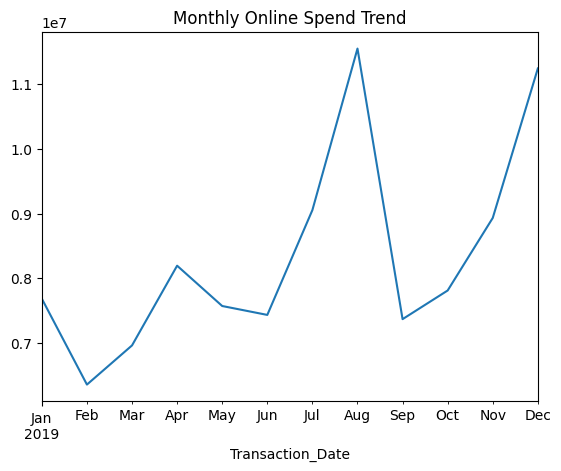

In [37]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], format='%d-%m-%Y') # Changed the format to '%d-%m-%Y' to match the DD-MM-YYYY format of your dates
df.set_index('Transaction_Date', inplace=True)

monthly_spend = df.resample('M')['Online_Spend'].sum()
monthly_spend.plot(title='Monthly Online Spend Trend')

Key Observations
- Fluctuations: Online spending is not constant throughout the year. There are clear peaks and troughs.
- Peak Spending: There appears to be a significant peak in online spending around August. This could be due to various factors like seasonal sales, holidays, or specific marketing campaigns during that time.
- Low Spending: There are periods of lower online spending, for example, around February and June.

<Axes: title={'center': '3-Month Rolling Average - Online Spend'}, xlabel='Transaction_Date'>

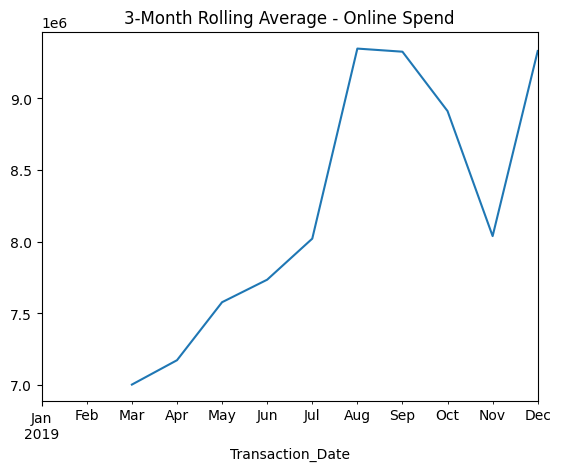

In [38]:
monthly_spend.rolling(3).mean().plot(title='3-Month Rolling Average - Online Spend')


Key Observations and Insights from the 3-Month Rolling Average:

- Smoothed Trend: The rolling average helps to smooth out short-term fluctuations and highlights the underlying trend in online spending more clearly. You can see the overall direction of spending without being as affected by individual monthly spikes or dips.

<ipython-input-39-1bba715c6498>:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_freq = df.resample('M').size()


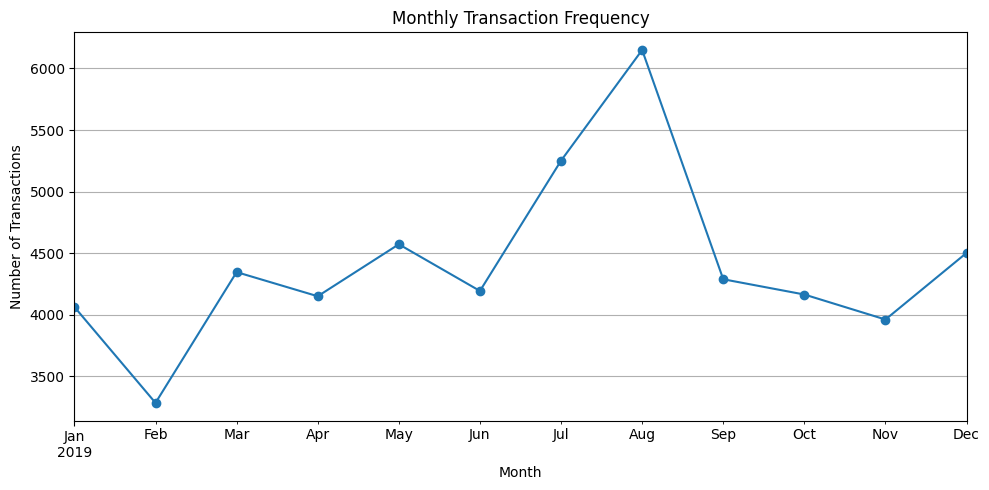

In [39]:
# Ensure datetime format is correct (if 'Transaction_Date' is still a column)
if 'Transaction_Date' in df.columns:
    df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], format='%d-%m-%Y')

# Reset index if 'Transaction_Date' is already the index
df = df.reset_index()

# Set date as index (now it should work)
df.set_index('Transaction_Date', inplace=True)

# Count transactions per month
monthly_freq = df.resample('M').size()

# Plot monthly transaction frequency
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
monthly_freq.plot(marker='o', title='Monthly Transaction Frequency')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.tight_layout()
plt.show()

Key Observations and Insights:

- Fluctuating Transaction Volume: The number of transactions varies significantly throughout the year. It's not a constant level.
- Peak Transaction Month: There is a clear peak in transaction frequency in August. This suggests that August was the busiest month in terms of the number of purchases made.
-  Low Transaction Months: The lowest number of transactions appears to occur in February. Other relatively low months seem to be January and November.

Dropping the ID and Data , because the Date and transcation date  are same so it is redudant

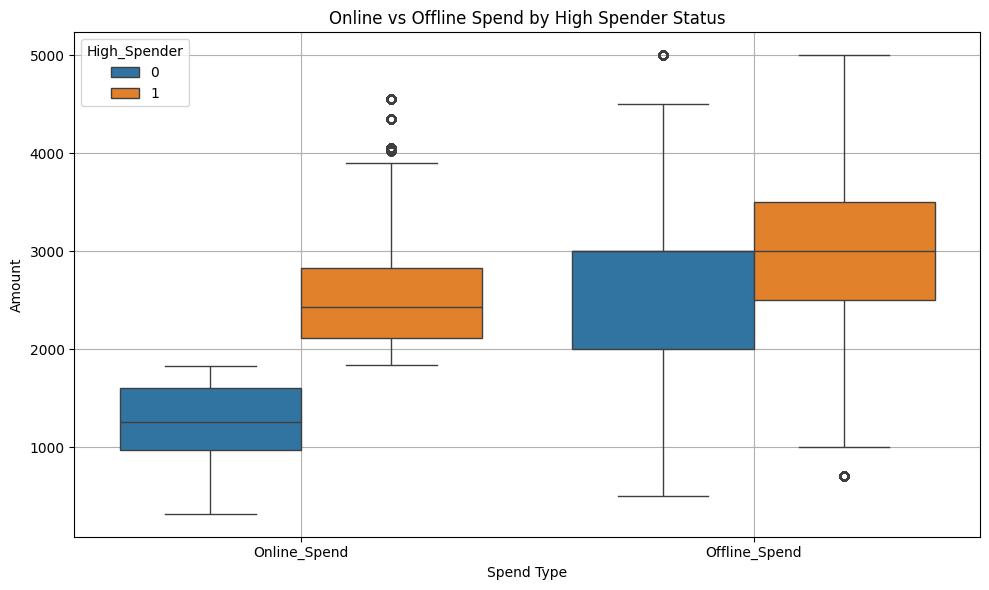

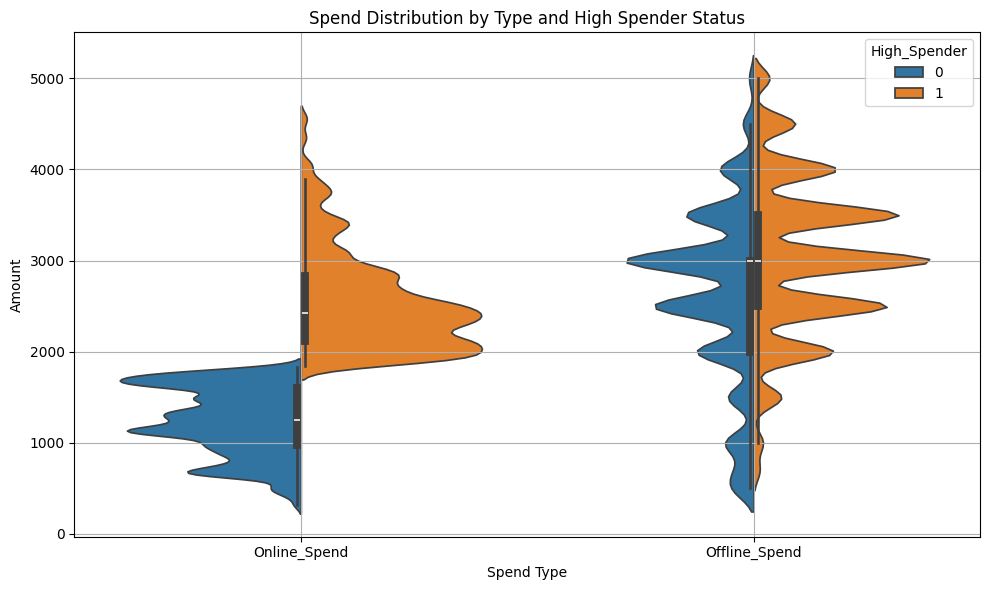

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the data to long format for seaborn
melted_df = df[['High_Spender', 'Online_Spend', 'Offline_Spend']].melt(id_vars='High_Spender',
                                                                       var_name='Spend_Type',
                                                                       value_name='Amount')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Spend_Type', y='Amount', hue='High_Spender', data=melted_df)
plt.title('Online vs Offline Spend by High Spender Status')
plt.xlabel('Spend Type')
plt.ylabel('Amount')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
sns.violinplot(x='Spend_Type', y='Amount', hue='High_Spender', data=melted_df, split=True)
plt.title('Spend Distribution by Type and High Spender Status')
plt.xlabel('Spend Type')
plt.ylabel('Amount')
plt.grid(True)
plt.tight_layout()
plt.show()


Lower Barrier to Entry and More Frequent Small Purchases: Online shopping often involves smaller, more frequent purchases due to convenience and a vast array of lower-priced items. This can lead to a concentration of spending at the lower end of the spectrum for many customers.

Summary:
- High spenders spend more overall. Not surprisingly, the customers we've identified as high spenders shell out more money both online and in physical stores compared to other customers.
- High spenders really like shopping in stores. The biggest difference in spending for high spenders is that they tend to spend a lot more money in physical stores than they do online. There are some instances where they spend a ton of money offline.
- Everyone spends more offline. Even for the customers who aren't labeled as high spenders, they generally spend more money when they're shopping in physical stores compared to online.
- Online spending is more consistent for regular customers. The amount spent online by regular customers tends to be within a narrower range compared to high spenders, who have some very high online purchases.
- Offline spending is all over the place. For both groups of customers, the amount they spend in physical stores varies quite a bit, with some very high and sometimes very low individual purchases.

In [41]:
df.drop(columns =['ID'], inplace=True)

In [42]:
print("Columns before dropping:")
print(df.columns)
print(df.shape)

Columns before dropping:
Index(['CustomerID', 'Gender', 'Location', 'Tenure_Months', 'Transaction_ID',
       'Product_SKU', 'Product_Description', 'Product_Category', 'Quantity',
       'Avg_Price', 'Delivery_Charges', 'Coupon_Status', 'GST',
       'Offline_Spend', 'Online_Spend', 'Month', 'Coupon_Code', 'Discount_pct',
       'High_Spender', 'GST_Slab', 'Discount disDiscount_pct', 'Tenure_Group',
       'High_Tenure'],
      dtype='object')
(52924, 23)


Proposal: These two columns represent the same information in different formats. The GST_Slab is already a clear categorical representation. We can keep GST_Slab (which we will encode later) and drop GST to avoid redundancy.

In [43]:
# Columns to drop
columns_to_drop = ['GST', 'Discount_pct', 'Tenure_Months']

Proposal: Similar to the GST features, these provide redundant information. Let's keep Discount disDiscount_pct (which we will encode later) and drop Discount_pct

In [44]:
# Drop the specified columns
df.drop(columns=columns_to_drop, inplace=True)

In [45]:
print("\nColumns after dropping:")
print(df.columns)
print(df.shape)


Columns after dropping:
Index(['CustomerID', 'Gender', 'Location', 'Transaction_ID', 'Product_SKU',
       'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price',
       'Delivery_Charges', 'Coupon_Status', 'Offline_Spend', 'Online_Spend',
       'Month', 'Coupon_Code', 'High_Spender', 'GST_Slab',
       'Discount disDiscount_pct', 'Tenure_Group', 'High_Tenure'],
      dtype='object')
(52924, 20)


In [46]:
# 2. Rename 'Discount disDiscount_pct'
old_name = 'Discount disDiscount_pct'
new_name = 'Discount_Category' # You can change this if you prefer another name

if old_name in df.columns:
    df.rename(columns={old_name: new_name}, inplace=True)
    print(f"\nColumn '{old_name}' renamed to '{new_name}'.")
    print("\nColumns after renaming:")
    print(df.columns)
else:
    print(f"\nColumn '{old_name}' not found. It might have been already renamed or dropped.")
    print("\nCurrent columns:")
    print(df.columns)


Column 'Discount disDiscount_pct' renamed to 'Discount_Category'.

Columns after renaming:
Index(['CustomerID', 'Gender', 'Location', 'Transaction_ID', 'Product_SKU',
       'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price',
       'Delivery_Charges', 'Coupon_Status', 'Offline_Spend', 'Online_Spend',
       'Month', 'Coupon_Code', 'High_Spender', 'GST_Slab', 'Discount_Category',
       'Tenure_Group', 'High_Tenure'],
      dtype='object')


In [47]:
print("Current columns:", df.columns)

# Now, examine Product_SKU and Product_Description
print("\n--- Product_SKU ---")
num_unique_sku = df['Product_SKU'].nunique()
print(f"Number of unique Product_SKU: {num_unique_sku}")
print("Example SKUs (first 5 unique):")
print(df['Product_SKU'].unique()[:5])
print("\nValue counts for top 5 Product_SKU:")
print(df['Product_SKU'].value_counts().head())

print("\n--- Product_Description ---")
num_unique_desc = df['Product_Description'].nunique()
print(f"Number of unique Product_Description: {num_unique_desc}")
print("Example Descriptions (first 5 unique):")
# Descriptions can be long, so printing carefully
for desc in df['Product_Description'].unique()[:5]:
    print(f"- {desc}")
print("\nValue counts for top 5 Product_Description:")
print(df['Product_Description'].value_counts().head())

# Also, let's look at Product_Category again for context
print("\n--- Product_Category (for context) ---")
num_unique_cat = df['Product_Category'].nunique()
print(f"Number of unique Product_Category: {num_unique_cat}")
print("Example Categories (first 5 unique):")
print(df['Product_Category'].unique()[:5])
print("\nValue counts for top 5 Product_Category:")
print(df['Product_Category'].value_counts().head())

Current columns: Index(['CustomerID', 'Gender', 'Location', 'Transaction_ID', 'Product_SKU',
       'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price',
       'Delivery_Charges', 'Coupon_Status', 'Offline_Spend', 'Online_Spend',
       'Month', 'Coupon_Code', 'High_Spender', 'GST_Slab', 'Discount_Category',
       'Tenure_Group', 'High_Tenure'],
      dtype='object')

--- Product_SKU ---
Number of unique Product_SKU: 1145
Example SKUs (first 5 unique):
['GGOENEBJ079499' 'GGOENEBQ078999' 'GGOENEBQ079099' 'GGOENEBB078899'
 'GGOENEBQ079199']

Value counts for top 5 Product_SKU:
Product_SKU
GGOENEBJ079499    3511
GGOENEBQ078999    3328
GGOENEBB078899    3230
GGOENEBQ079099    1361
GGOENEBQ084699    1089
Name: count, dtype: int64

--- Product_Description ---
Number of unique Product_Description: 404
Example Descriptions (first 5 unique):
- Nest Learning Thermostat 3rd Gen-USA - Stainless Steel
- Nest Cam Outdoor Security Camera - USA
- Nest Protect Smoke + CO White Battery A

The examination of Product_SKU, Product_Description, and Product_Category gives us the following:

- Product_SKU: 1145 unique values. This is quite high.
Example Top SKU: GGOENEBJ079499 (appears 3511 times)
- Product_Description: 404 unique values. Still high, but significantly less than Product_SKU.
- Example Top Description: Nest Learning Thermostat 3rd Gen-USA - Stainless Steel (appears 3511 times)
Product_Category: 20 unique values. This is a manageable number.
 - Example Top Category: Apparel (appears 18126 times)

# 3. Drop 'Product_SKU'

In [48]:
column_to_drop_phase2 = 'Product_SKU'
if column_to_drop_phase2 in df.columns:
    df.drop(columns=[column_to_drop_phase2], inplace=True)
    print(f"\nDropped column '{column_to_drop_phase2}'.")
else:
    print(f"\nColumn '{column_to_drop_phase2}' already dropped or not found.")

print("\nFinal columns after 'Review and Refine Existing Features' stage:")
print(df.columns.tolist())


Dropped column 'Product_SKU'.

Final columns after 'Review and Refine Existing Features' stage:
['CustomerID', 'Gender', 'Location', 'Transaction_ID', 'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price', 'Delivery_Charges', 'Coupon_Status', 'Offline_Spend', 'Online_Spend', 'Month', 'Coupon_Code', 'High_Spender', 'GST_Slab', 'Discount_Category', 'Tenure_Group', 'High_Tenure']


- Confirmed High_Spender (binary int) and High_Tenure (boolean) are fine.
- Decided to use GST_Slab and dropped GST.
- Decided to use Discount_Category (renamed from Discount disDiscount_pct) and dropped Discount_pct.
- Decided to use Tenure_Group and dropped Tenure_Months.
- Decided to use Product_Category and Product_Description (for which we'll apply specific encodings later) and dropped Product_SKU.

#  Encoding Categorical Features

In [49]:
print("Original columns:", df.columns.tolist())
print(f"Original shape: {df.shape}")

Original columns: ['CustomerID', 'Gender', 'Location', 'Transaction_ID', 'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price', 'Delivery_Charges', 'Coupon_Status', 'Offline_Spend', 'Online_Spend', 'Month', 'Coupon_Code', 'High_Spender', 'GST_Slab', 'Discount_Category', 'Tenure_Group', 'High_Tenure']
Original shape: (52924, 19)


In [50]:
# First, let's identify all object columns that need encoding and check Coupon_Code cardinality
object_columns = df.select_dtypes(include=['object']).columns.tolist()
print("\nObject columns to consider for encoding:", object_columns)


Object columns to consider for encoding: ['Gender', 'Location', 'Product_Description', 'Product_Category', 'Coupon_Status', 'Coupon_Code', 'GST_Slab', 'Discount_Category']


### Check cardinality of 'Coupon_Code'

In [51]:
# Check cardinality of 'Coupon_Code'
if 'Coupon_Code' in df.columns:
    coupon_code_cardinality = df['Coupon_Code'].nunique()
    print(f"\nCardinality of 'Coupon_Code': {coupon_code_cardinality}")


Cardinality of 'Coupon_Code': 46


In [52]:
# Check cardinality of 'Product_Description' (we decided on frequency encoding)
if 'Product_Description' in df.columns:
    product_desc_cardinality = df['Product_Description'].nunique()
    print(f"Cardinality of 'Product_Description': {product_desc_cardinality}")
else:
    print("\n'Product_Description' column not found.")

Cardinality of 'Product_Description': 404


## Columns for frequency encoding

In [53]:
# For clarity, I'll re-state the columns for frequency encoding:
cols_for_freq_encoding = ['Product_Description', 'Coupon_Code']

for col in cols_for_freq_encoding:
    if col in df.columns:
        # Calculate frequency of each category
        frequency_map = df[col].value_counts(normalize=True)
        # Map frequencies to the column, creating a new column or overwriting
        df[col + '_freq'] = df[col].map(frequency_map)
        print(f"Applied frequency encoding to '{col}', new column is '{col}_freq'.")
        # We can decide to drop the original categorical column after encoding
        # df.drop(col, axis=1, inplace=True)
        # print(f"Dropped original column '{col}'.")
    else:
        print(f"Column '{col}' not found for frequency encoding.")

# Let's check the DataFrame
print("\nDataFrame head after frequency encoding (before dropping originals):")
print(df.head())

print("\nInfo after frequency encoding:")
df.info()

Applied frequency encoding to 'Product_Description', new column is 'Product_Description_freq'.
Applied frequency encoding to 'Coupon_Code', new column is 'Coupon_Code_freq'.

DataFrame head after frequency encoding (before dropping originals):
                  CustomerID Gender Location  Transaction_ID  \
Transaction_Date                                               
2019-01-01             17850      M  Chicago           16679   
2019-01-01             17850      M  Chicago           16680   
2019-01-01             17850      M  Chicago           16696   
2019-01-01             17850      M  Chicago           16699   
2019-01-01             17850      M  Chicago           16700   

                                                Product_Description  \
Transaction_Date                                                      
2019-01-01        Nest Learning Thermostat 3rd Gen-USA - Stainle...   
2019-01-01        Nest Learning Thermostat 3rd Gen-USA - Stainle...   
2019-01-01             

In [54]:
# Drop the original columns that have been frequency encoded
cols_to_drop_after_freq_encoding = ['Product_Description', 'Coupon_Code']

for col in cols_to_drop_after_freq_encoding:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)
        print(f"Dropped original column '{col}'.")
    else:
        print(f"Column '{col}' not found, may have already been dropped.")

print("\nDataFrame columns after dropping frequency-encoded originals:")
print(df.columns.tolist())
print("\nDataFrame head:")
print(df.head())

Dropped original column 'Product_Description'.
Dropped original column 'Coupon_Code'.

DataFrame columns after dropping frequency-encoded originals:
['CustomerID', 'Gender', 'Location', 'Transaction_ID', 'Product_Category', 'Quantity', 'Avg_Price', 'Delivery_Charges', 'Coupon_Status', 'Offline_Spend', 'Online_Spend', 'Month', 'High_Spender', 'GST_Slab', 'Discount_Category', 'Tenure_Group', 'High_Tenure', 'Product_Description_freq', 'Coupon_Code_freq']

DataFrame head:
                  CustomerID Gender Location  Transaction_ID Product_Category  \
Transaction_Date                                                                
2019-01-01             17850      M  Chicago           16679         Nest-USA   
2019-01-01             17850      M  Chicago           16680         Nest-USA   
2019-01-01             17850      M  Chicago           16696         Nest-USA   
2019-01-01             17850      M  Chicago           16699         Nest-USA   
2019-01-01             17850      M  Chic

The frequency encoding for Product_Description and Coupon_Code has been applied, and you now have Product_Description_freq and Coupon_Code_freq as new numerical features. we dropping the orginal values

# --- One-Hot Encoding ---

In [55]:
cols_for_ohe = ['Gender', 'Location', 'Product_Category', 'Coupon_Status', 'GST_Slab', 'Discount_Category', 'Tenure_Group']
print(f"\nColumns to be one-hot encoded: {cols_for_ohe}")

# Check for non-existent columns before attempting OHE
actual_cols_for_ohe = [col for col in cols_for_ohe if col in df.columns]
missing_cols_for_ohe = [col for col in cols_for_ohe if col not in df.columns]

if missing_cols_for_ohe:
    print(f"Warning: The following columns intended for OHE were not found and will be skipped: {missing_cols_for_ohe}")

if actual_cols_for_ohe:
    df = pd.get_dummies(df, columns=actual_cols_for_ohe, drop_first=True)
    print("\nApplied one-hot encoding.")
else:
    print("\nNo columns were found for one-hot encoding.")

print("\nDataFrame columns after one-hot encoding:")
print(df.columns.tolist())
print(f"\nShape of DataFrame after one-hot encoding: {df.shape}")

print("\nDataFrame head after one-hot encoding:")
print(df.head())

print("\nInfo after one-hot encoding:")
df.info()


Columns to be one-hot encoded: ['Gender', 'Location', 'Product_Category', 'Coupon_Status', 'GST_Slab', 'Discount_Category', 'Tenure_Group']

Applied one-hot encoding.

DataFrame columns after one-hot encoding:
['CustomerID', 'Transaction_ID', 'Quantity', 'Avg_Price', 'Delivery_Charges', 'Offline_Spend', 'Online_Spend', 'Month', 'High_Spender', 'High_Tenure', 'Product_Description_freq', 'Coupon_Code_freq', 'Gender_M', 'Location_Chicago', 'Location_New Jersey', 'Location_New York', 'Location_Washington DC', 'Product_Category_Android', 'Product_Category_Apparel', 'Product_Category_Backpacks', 'Product_Category_Bags', 'Product_Category_Bottles', 'Product_Category_Drinkware', 'Product_Category_Fun', 'Product_Category_Gift Cards', 'Product_Category_Google', 'Product_Category_Headgear', 'Product_Category_Housewares', 'Product_Category_Lifestyle', 'Product_Category_More Bags', 'Product_Category_Nest', 'Product_Category_Nest-Canada', 'Product_Category_Nest-USA', 'Product_Category_Notebooks & J

The one-hot encoding is done, and your DataFrame has expanded to 46 columns, all of which are now numerical types (int64, float64, or uint8 for the new dummy variables), except for High_Tenure which is still boolean.

Boolean to Integer Conversion

In [56]:
# (Assuming df is the DataFrame after 'High_Tenure' was converted to int)

# Identify all boolean columns (excluding 'High_Tenure' if it's already int,
# but converting it again if it's bool won't harm)
boolean_columns = df.select_dtypes(include=['bool']).columns

if len(boolean_columns) > 0:
    print(f"Found boolean columns to convert to integer: {boolean_columns.tolist()}")
    for col in boolean_columns:
        df[col] = df[col].astype(int)
    print("Converted boolean columns to integer type.")
else:
    print("No boolean columns found to convert (they might be already converted).")

print("\nInfo after converting all boolean columns to integers:")
df.info()

print("\nFirst 5 rows after converting all boolean columns:")
print(df.head())

Found boolean columns to convert to integer: ['High_Tenure', 'Gender_M', 'Location_Chicago', 'Location_New Jersey', 'Location_New York', 'Location_Washington DC', 'Product_Category_Android', 'Product_Category_Apparel', 'Product_Category_Backpacks', 'Product_Category_Bags', 'Product_Category_Bottles', 'Product_Category_Drinkware', 'Product_Category_Fun', 'Product_Category_Gift Cards', 'Product_Category_Google', 'Product_Category_Headgear', 'Product_Category_Housewares', 'Product_Category_Lifestyle', 'Product_Category_More Bags', 'Product_Category_Nest', 'Product_Category_Nest-Canada', 'Product_Category_Nest-USA', 'Product_Category_Notebooks & Journals', 'Product_Category_Office', 'Product_Category_Waze', 'Coupon_Status_Not Used', 'Coupon_Status_Used', 'GST_Slab_GST 12%', 'GST_Slab_GST 18%', 'GST_Slab_GST 5%', 'Discount_Category_20 % Discount', 'Discount_Category_30 % Discount', 'Discount_Category_No Discount', 'Tenure_Group_6-12M', 'Tenure_Group_>12M']
Converted boolean columns to integ

# Creating New Features.

In [57]:

# (Assuming df is the DataFrame after all encoding steps)

# 1. Create Total_Spend
if 'Offline_Spend' in df.columns and 'Online_Spend' in df.columns:
    df['Total_Spend'] = df['Offline_Spend'] + df['Online_Spend']
    print("Created 'Total_Spend' feature.")
else:
    print("Could not create 'Total_Spend': 'Offline_Spend' or 'Online_Spend' column missing.")

# 2. Create Item_Total_Value
if 'Avg_Price' in df.columns and 'Quantity' in df.columns:
    df['Item_Total_Value'] = df['Avg_Price'] * df['Quantity']
    print("Created 'Item_Total_Value' feature.")
else:
    print("Could not create 'Item_Total_Value': 'Avg_Price' or 'Quantity' column missing.")

# 3. Create Online_Offline_Spend_Ratio
if 'Online_Spend' in df.columns and 'Offline_Spend' in df.columns:
    df['Online_Offline_Spend_Ratio'] = df['Online_Spend'] / (df['Offline_Spend'] + 1e-6) # Add small constant to avoid division by zero
    print("Created 'Online_Offline_Spend_Ratio' feature.")
else:
    print("Could not create 'Online_Offline_Spend_Ratio': 'Online_Spend' or 'Offline_Spend' column missing.")

# 4. Create Cyclical Month Features
if 'Month' in df.columns:
    df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    # We can now drop the original 'Month' column if we wish, as its information is captured cyclically
    # df.drop('Month', axis=1, inplace=True)
    # print("Created 'Month_sin' and 'Month_cos' features and dropped original 'Month' column.")
    print("Created 'Month_sin' and 'Month_cos' features.")
else:
    print("Could not create cyclical month features: 'Month' column missing.")

print("\nDataFrame columns after creating new features:")
print(df.columns.tolist())
print(f"\nShape of DataFrame after creating new features: {df.shape}")

print("\nDataFrame head after creating new features:")
print(df.head())

print("\nInfo after creating new features:")
df.info()

Created 'Total_Spend' feature.
Created 'Item_Total_Value' feature.
Created 'Online_Offline_Spend_Ratio' feature.
Created 'Month_sin' and 'Month_cos' features.

DataFrame columns after creating new features:
['CustomerID', 'Transaction_ID', 'Quantity', 'Avg_Price', 'Delivery_Charges', 'Offline_Spend', 'Online_Spend', 'Month', 'High_Spender', 'High_Tenure', 'Product_Description_freq', 'Coupon_Code_freq', 'Gender_M', 'Location_Chicago', 'Location_New Jersey', 'Location_New York', 'Location_Washington DC', 'Product_Category_Android', 'Product_Category_Apparel', 'Product_Category_Backpacks', 'Product_Category_Bags', 'Product_Category_Bottles', 'Product_Category_Drinkware', 'Product_Category_Fun', 'Product_Category_Gift Cards', 'Product_Category_Google', 'Product_Category_Headgear', 'Product_Category_Housewares', 'Product_Category_Lifestyle', 'Product_Category_More Bags', 'Product_Category_Nest', 'Product_Category_Nest-Canada', 'Product_Category_Nest-USA', 'Product_Category_Notebooks & Journ

All the new features have been created successfully, and your DataFrame now has 51 columns.

In [58]:

if 'Month' in df.columns:
    df.drop('Month', axis=1, inplace=True)
    print("Dropped original 'Month' column.")
else:
    print("Original 'Month' column not found or already dropped.")

print("\nDataFrame columns after potentially dropping 'Month':")
print(df.columns.tolist())
print(f"\nShape of DataFrame: {df.shape}")

Dropped original 'Month' column.

DataFrame columns after potentially dropping 'Month':
['CustomerID', 'Transaction_ID', 'Quantity', 'Avg_Price', 'Delivery_Charges', 'Offline_Spend', 'Online_Spend', 'High_Spender', 'High_Tenure', 'Product_Description_freq', 'Coupon_Code_freq', 'Gender_M', 'Location_Chicago', 'Location_New Jersey', 'Location_New York', 'Location_Washington DC', 'Product_Category_Android', 'Product_Category_Apparel', 'Product_Category_Backpacks', 'Product_Category_Bags', 'Product_Category_Bottles', 'Product_Category_Drinkware', 'Product_Category_Fun', 'Product_Category_Gift Cards', 'Product_Category_Google', 'Product_Category_Headgear', 'Product_Category_Housewares', 'Product_Category_Lifestyle', 'Product_Category_More Bags', 'Product_Category_Nest', 'Product_Category_Nest-Canada', 'Product_Category_Nest-USA', 'Product_Category_Notebooks & Journals', 'Product_Category_Office', 'Product_Category_Waze', 'Coupon_Status_Not Used', 'Coupon_Status_Used', 'GST_Slab_GST 12%', 'G

In [59]:
print(f"\nShape of DataFrame: {df.shape}")
print("\n--- Phase IV: Handling Numerical Features ---")

# Identify numerical columns for potential scaling/transformation
# These are typically continuous or count data, not identifiers or already encoded (0/1) features.
# The OHE features (uint8) and cyclical features (Month_sin, Month_cos) generally don't need this scaling.
# Frequency encoded features are already normalized (0-1), but we can include them for review.

# Let's list columns with float64 dtype or int64 dtype that are not purely identifiers or binary
# High_Spender and High_Tenure are binary (0/1), so they don't need scaling.
# CustomerID and Transaction_ID are identifiers.

numerical_cols_to_consider = []
if 'Quantity' in df.columns: numerical_cols_to_consider.append('Quantity')
if 'Avg_Price' in df.columns: numerical_cols_to_consider.append('Avg_Price')
if 'Delivery_Charges' in df.columns: numerical_cols_to_consider.append('Delivery_Charges')
if 'Offline_Spend' in df.columns: numerical_cols_to_consider.append('Offline_Spend')
if 'Online_Spend' in df.columns: numerical_cols_to_consider.append('Online_Spend')
if 'Total_Spend' in df.columns: numerical_cols_to_consider.append('Total_Spend') # New
if 'Item_Total_Value' in df.columns: numerical_cols_to_consider.append('Item_Total_Value') # New
if 'Online_Offline_Spend_Ratio' in df.columns: numerical_cols_to_consider.append('Online_Offline_Spend_Ratio') # New
if 'Product_Description_freq' in df.columns: numerical_cols_to_consider.append('Product_Description_freq') # Freq encoded
if 'Coupon_Code_freq' in df.columns: numerical_cols_to_consider.append('Coupon_Code_freq') # Freq encoded


# Filter out any columns that might have been dropped or not created if there were issues in previous steps
numerical_cols_to_consider = [col for col in numerical_cols_to_consider if col in df.columns]

print(f"\nNumerical columns to consider for skewness check and scaling: {numerical_cols_to_consider}")

# Check for skewness in these numerical features
if numerical_cols_to_consider:
    skewness = df[numerical_cols_to_consider].skew()
    print("\nSkewness of numerical features:")
    print(skewness)
else:
    print("\nNo numerical columns identified for skewness check.")

# Display some basic stats for these columns as well
if numerical_cols_to_consider:
    print("\nDescriptive statistics for these columns:")
    print(df[numerical_cols_to_consider].describe())


Shape of DataFrame: (52924, 50)

--- Phase IV: Handling Numerical Features ---

Numerical columns to consider for skewness check and scaling: ['Quantity', 'Avg_Price', 'Delivery_Charges', 'Offline_Spend', 'Online_Spend', 'Total_Spend', 'Item_Total_Value', 'Online_Offline_Spend_Ratio', 'Product_Description_freq', 'Coupon_Code_freq']

Skewness of numerical features:
Quantity                      19.034802
Avg_Price                      1.632580
Delivery_Charges              11.959739
Offline_Spend                 -0.316807
Online_Spend                   0.454306
Total_Spend                    0.008217
Item_Total_Value              18.705852
Online_Offline_Spend_Ratio     2.392217
Product_Description_freq       1.309982
Coupon_Code_freq              -0.439181
dtype: float64

Descriptive statistics for these columns:
           Quantity     Avg_Price  Delivery_Charges  Offline_Spend  \
count  52924.000000  52924.000000      52924.000000   52924.000000   
mean       4.497638     52.237646 

kewness values:

Quantity: 19.03 (Highly skewed)
Avg_Price: 1.63 (Moderately/Highly skewed)
Delivery_Charges: 11.96 (Highly skewed)
Offline_Spend: -0.32 (Approximately symmetric)
Online_Spend: 0.45 (Approximately symmetric / Mildly skewed)
Total_Spend: 0.008 (Approximately symmetric)
Item_Total_Value: 18.71 (Highly skewed)
Online_Offline_Spend_Ratio: 2.39 (Highly skewed)
Product_Description_freq: 1.31 (Moderately skewed)
Coupon_Code_freq: -0.44 (Approximately symmetric / Mildly skewed)
General rule of thumb for skewness:

If skewness is between -0.5 and 0.5, the data are fairly symmetrical.
If skewness is between -1 and -0.5 (negatively skewed) or between 0.5 and 1 (positively skewed), the data are moderately skewed.
If skewness is less than -1 (negatively skewed) or greater than 1 (positively skewed), the data are highly skewed.

Based on this:

Highly Skewed (need transformation): Quantity, Avg_Price, Delivery_Charges, Item_Total_Value, Online_Offline_Spend_Ratio, Product_Description_freq.
Approximately Symmetric / Mildly Skewed (may not need transformation, or transformation could be considered optional): Offline_Spend, Online_Spend, Total_Spend, Coupon_Code_freq.

In [60]:
import numpy as np # Ensure numpy is imported
from sklearn.preprocessing import StandardScaler # We'll need this soon

# (Assuming df is the DataFrame after dropping 'Month')

cols_for_log_transform = [
    'Quantity',
    'Avg_Price',
    'Delivery_Charges',
    'Item_Total_Value',
    'Online_Offline_Spend_Ratio',
    'Product_Description_freq'
]

# Ensure these columns exist in the DataFrame before attempting transformation
actual_cols_for_log = [col for col in cols_for_log_transform if col in df.columns]
missing_cols_for_log = [col for col in cols_for_log_transform if col not in df.columns]

if missing_cols_for_log:
    print(f"Warning: The following columns intended for log transformation were not found and will be skipped: {missing_cols_for_log}")

print(f"\nApplying log transformation (np.log1p) to: {actual_cols_for_log}")
for col in actual_cols_for_log:
    df[col] = np.log1p(df[col])

print("\nSkewness of these features after log transformation:")
if actual_cols_for_log: # Check if any columns were actually transformed
    skewness_after_log = df[actual_cols_for_log].skew()
    print(skewness_after_log)
else:
    print("No columns were log-transformed.")

print("\nDescriptive statistics for these columns after log transformation:")
if actual_cols_for_log:
    print(df[actual_cols_for_log].describe())

# Also, let's check the skewness of all numerical_cols_to_consider again
# This list was defined in the previous step's code output
numerical_cols_to_consider = ['Quantity', 'Avg_Price', 'Delivery_Charges', 'Offline_Spend', 'Online_Spend', 'Total_Spend', 'Item_Total_Value', 'Online_Offline_Spend_Ratio', 'Product_Description_freq', 'Coupon_Code_freq']
numerical_cols_to_consider = [col for col in numerical_cols_to_consider if col in df.columns] # ensure they exist

if numerical_cols_to_consider:
    print("\nOverall skewness of numerical features after partial log transformation:")
    print(df[numerical_cols_to_consider].skew())


Applying log transformation (np.log1p) to: ['Quantity', 'Avg_Price', 'Delivery_Charges', 'Item_Total_Value', 'Online_Offline_Spend_Ratio', 'Product_Description_freq']

Skewness of these features after log transformation:
Quantity                      2.755296
Avg_Price                     0.075168
Delivery_Charges              2.634073
Item_Total_Value              0.028846
Online_Offline_Spend_Ratio    1.162522
Product_Description_freq      1.299639
dtype: float64

Descriptive statistics for these columns after log transformation:
           Quantity     Avg_Price  Delivery_Charges  Item_Total_Value  \
count  52924.000000  52924.000000      52924.000000      52924.000000   
mean       1.066944      3.126378          2.179542          3.603419   
std        0.755387      1.399033          0.539681          1.406083   
min        0.693147      0.329304          0.000000          0.336472   
25%        0.693147      1.902108          1.945910          2.561868   
50%        0.693147    

We will now apply StandardScaler to all the numerical columns we've been working with. This includes:

The columns we just log-transformed: Quantity, Avg_Price, Delivery_Charges, Item_Total_Value, Online_Offline_Spend_Ratio, Product_Description_freq.
The columns that were already symmetric enough and not log-transformed: Offline_Spend, Online_Spend, Total_Spend, Coupon_Code_freq.
StandardScaler will transform the data to have a mean of 0 and a standard deviation of 1.

In [61]:
from sklearn.preprocessing import StandardScaler

# (Assuming df is the DataFrame after log transformations)

# This list should contain all numerical features we want to scale
numerical_cols_for_scaling = [
    'Quantity', 'Avg_Price', 'Delivery_Charges', 'Offline_Spend',
    'Online_Spend', 'Total_Spend', 'Item_Total_Value',
    'Online_Offline_Spend_Ratio', 'Product_Description_freq', 'Coupon_Code_freq'
]

# Ensure these columns exist in the DataFrame
actual_cols_for_scaling = [col for col in numerical_cols_for_scaling if col in df.columns]
missing_cols_for_scaling = [col for col in numerical_cols_for_scaling if col not in df.columns]

if missing_cols_for_scaling:
    print(f"Warning: The following columns intended for scaling were not found and will be skipped: {missing_cols_for_scaling}")

if actual_cols_for_scaling:
    print(f"\nApplying StandardScaler to: {actual_cols_for_scaling}")
    scaler = StandardScaler()
    df[actual_cols_for_scaling] = scaler.fit_transform(df[actual_cols_for_scaling])

    print("\nDescriptive statistics for these columns after scaling:")
    print(df[actual_cols_for_scaling].describe())
else:
    print("\nNo columns found to apply scaling.")

print("\nDataFrame head after scaling:")
print(df.head())

print("\nInfo after scaling:")
df.info()


Applying StandardScaler to: ['Quantity', 'Avg_Price', 'Delivery_Charges', 'Offline_Spend', 'Online_Spend', 'Total_Spend', 'Item_Total_Value', 'Online_Offline_Spend_Ratio', 'Product_Description_freq', 'Coupon_Code_freq']

Descriptive statistics for these columns after scaling:
           Quantity     Avg_Price  Delivery_Charges  Offline_Spend  \
count  5.292400e+04  5.292400e+04      5.292400e+04   5.292400e+04   
mean   1.159982e-16  5.585099e-17      3.329578e-16   1.482199e-16   
std    1.000009e+00  1.000009e+00      1.000009e+00   1.000009e+00   
min   -4.948466e-01 -1.999311e+00     -4.038615e+00  -2.489906e+00   
25%   -4.948466e-01 -8.750922e-01     -4.329116e-01  -3.534858e-01   
50%   -4.948466e-01 -1.690916e-01     -4.329116e-01   1.806192e-01   
75%    4.192301e-02  1.079050e+00     -3.050702e-01   7.147243e-01   
max    7.594270e+00  1.966112e+00      7.557902e+00   2.317039e+00   

       Online_Spend   Total_Spend  Item_Total_Value  \
count  5.292400e+04  5.292400e+04   

All your numerical features (like Quantity, Avg_Price, Total_Spend, etc., including those that were log-transformed) now have a mean very close to 0 and a standard deviation very close to 1. This is exactly what StandardScaler is designed to do.
The one-hot encoded features are represented as 0s and 1s (now showing as int64 in your output, which is fine).
The frequency-encoded features (Product_Description_freq, Coupon_Code_freq) are also scaled.
The cyclical month features (Month_sin, Month_cos) are in their correct form.
The DataFrame now has 50 columns, and all data types are numerical (float64, int64).

# Dropping Redundant or Unnecessary Columns

In [62]:
columns_to_drop_final = ['CustomerID', 'Transaction_ID']
actual_columns_dropped = []

for col in columns_to_drop_final:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)
        actual_columns_dropped.append(col)
        print(f"Dropped column '{col}'.")
    else:
        print(f"Column '{col}' not found or already dropped.")

if actual_columns_dropped:
    print(f"\nSuccessfully dropped: {actual_columns_dropped}")
else:
    print("\nNo specified identifier columns were found to drop.")


print("\n--- Feature Engineering Complete ---")

Dropped column 'CustomerID'.
Dropped column 'Transaction_ID'.

Successfully dropped: ['CustomerID', 'Transaction_ID']

--- Feature Engineering Complete ---


In [63]:
df.head()

,Quantity,Avg_Price,Delivery_Charges,Offline_Spend,Online_Spend,High_Spender,High_Tenure,Product_Description_freq,Coupon_Code_freq,Gender_M,...,Discount_Category_20 % Discount,Discount_Category_30 % Discount,Discount_Category_No Discount,Tenure_Group_6-12M,Tenure_Group_>12M,Total_Spend,Item_Total_Value,Online_Offline_Spend_Ratio,Month_sin,Month_cos
Transaction_Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,-0.494847,1.368940,-0.30507,1.782934,0.658472,1,0,2.086487,0.44141,1,...,0,0,0,1,0,1.542059,1.022803,-0.477313,0.5,0.866025
2019-01-01,-0.494847,1.368940,-0.30507,1.782934,0.658472,1,0,2.086487,0.44141,1,...,0,0,0,1,0,1.542059,1.022803,-0.477313,0.5,0.866025
2019-01-01,0.041923,1.209452,-0.30507,1.782934,0.658472,1,0,1.941754,0.44141,1,...,0,0,0,1,0,1.542059,1.354203,-0.477313,0.5,0.866025
2019-01-01,-0.494847,0.919515,-0.30507,1.782934,0.658472,1,0,0.355647,0.44141,1,...,0,0,0,1,0,1.542059,0.575632,-0.477313,0.5,0.866025
2019-01-01,-0.494847,1.368940,-0.30507,1.782934,0.658472,1,0,2.086487,0.44141,1,...,0,0,0,1,0,1.542059,1.022803,-0.477313,0.5,0.866025


In [64]:
print("\nFinal DataFrame head:")


print("\nFinal DataFrame info:")
df.info()


Final DataFrame head:

Final DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52924 entries, 2019-01-01 to 2019-10-06
Data columns (total 48 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Quantity                               52924 non-null  float64
 1   Avg_Price                              52924 non-null  float64
 2   Delivery_Charges                       52924 non-null  float64
 3   Offline_Spend                          52924 non-null  float64
 4   Online_Spend                           52924 non-null  float64
 5   High_Spender                           52924 non-null  int64  
 6   High_Tenure                            52924 non-null  int64  
 7   Product_Description_freq               52924 non-null  float64
 8   Coupon_Code_freq                       52924 non-null  float64
 9   Gender_M                               52924 non-null  int64  
 10  Locatio

We've now completed the entire feature engineering plan:
- I.  Review and Refine Existing Features: Done.
- II. Encoding Categorical Features: Done (Frequency and One-Hot Encoding, Boolean to Int).
- III.Creating New Features: Done (Total_Spend, Item_Total_Value, Online_Offline_Spend_Ratio, Month_sin, Month_cos).
- IV. Handling Numerical Features: Done (Log Transformation for skewness, StandardScaler).
- V.  Dropping Redundant or Unnecessary Columns: Done (Identifiers).

In [65]:
print(df['Coupon_Status_Used'].value_counts(normalize=True))

Coupon_Status_Used
0    0.661704
1    0.338296
Name: proportion, dtype: float64


The distribution of your High_Spender target variable is:

1 (High Spender): 50.09%
0 (Not High Spender): 49.91%

In [66]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 0: Ensure 'df' is your fully feature-engineered DataFrame ---
# This DataFrame should include 'High_Spender' and the engineered features
# like 'Total_Spend', 'Offline_Spend', 'Online_Spend', along with all
# scaled, encoded, and other created features from our previous work.
#
# Example: If you had saved it at the end of all feature engineering:
# # df = pd.read_csv("final_feature_engineered_df_before_modeling.csv")
# For now, we'll assume 'df' is correctly loaded in your environment.
# Make sure it has these columns before proceeding.
# For example, check:
# required_cols_check = ['High_Spender', 'Total_Spend', 'Offline_Spend', 'Online_Spend']
# if not all(col in df.columns for col in required_cols_check):
#     print(f"Error: DataFrame 'df' is missing one or more required columns for this step: {required_cols_check}")
#     print("Please ensure 'df' is the version after all feature engineering, including creation of these spending columns.")
# else:
#     print("DataFrame 'df' seems to contain the necessary spending columns.")


# --- Step 1: Define Target (y_hs) and Features (X_hs) correctly ---
target_hs_column = 'High_Spender'

# Columns to remove from X to prevent data leakage,
# because High_Spender was derived from Total_Spend,
# and Total_Spend was derived from Offline_Spend and Online_Spend.
columns_to_exclude_from_X = [
    target_hs_column,
    'Total_Spend',
    'Offline_Spend',
    'Online_Spend'
]

if target_hs_column in df.columns:
    y_hs = df[target_hs_column]
    X_hs = df.drop(columns=columns_to_exclude_from_X, errors='ignore')

    print(f"Target 'y_hs' ('{target_hs_column}') created.")
    print(f"Shape of y_hs: {y_hs.shape}")
    print(f"\nFeatures 'X_hs' created.")
    print(f"Shape of X_hs: {X_hs.shape}")
    print(f"Columns explicitly excluded from X_hs: {columns_to_exclude_from_X}")
    print("Remaining columns in X_hs (first 10):", X_hs.columns.tolist()[:10])


    # --- Step 2: Confirm Balance of y_hs (we know it's good) ---
    print("\nBalance of target 'y_hs':")
    print(y_hs.value_counts(normalize=True))


    # --- Step 3: Split Data ---
    X_train_hs, X_test_hs, y_train_hs, y_test_hs = train_test_split(
        X_hs, y_hs,
        test_size=0.20, # 20% for testing
        random_state=42, # For reproducibility
        stratify=y_hs # Good practice for classification
    )
    print("\nData split for 'High_Spender' target .")
    print(f"Shape of X_train_hs: {X_train_hs.shape}, Shape of y_train_hs: {y_train_hs.shape}")
    print(f"Shape of X_test_hs: {X_test_hs.shape}, Shape of y_test_hs: {y_test_hs.shape}")

    # --- Step 4 & 5: Train and Evaluate Logistic Regression ---
    print("\n\n--- Training and Evaluating Logistic Regression  ---")
    log_reg_hs = LogisticRegression(random_state=42, max_iter=1000)
    log_reg_hs.fit(X_train_hs, y_train_hs)
    y_pred_log_reg_hs = log_reg_hs.predict(X_test_hs)
    y_proba_log_reg_hs = log_reg_hs.predict_proba(X_test_hs)[:, 1]

    print(f"Accuracy: {accuracy_score(y_test_hs, y_pred_log_reg_hs):.4f}")
    print(f"AUC-ROC Score: {roc_auc_score(y_test_hs, y_proba_log_reg_hs):.4f}")
    print("\nConfusion Matrix (Logistic Regression):")
    print(confusion_matrix(y_test_hs, y_pred_log_reg_hs))
    print("\nClassification Report (Logistic Regression):")
    print(classification_report(y_test_hs, y_pred_log_reg_hs, target_names=['Not High Spender (0)', 'High Spender (1)']))


else:
    print(f"Error: Target column '{target_hs_column}' not found in the DataFrame 'df'.")
    print("Please ensure 'df' is correctly loaded and 'High_Spender' was created in it.")

Target 'y_hs' ('High_Spender') created.
Shape of y_hs: (52924,)

Features 'X_hs' created.
Shape of X_hs: (52924, 44)
Columns explicitly excluded from X_hs: ['High_Spender', 'Total_Spend', 'Offline_Spend', 'Online_Spend']
Remaining columns in X_hs (first 10): ['Quantity', 'Avg_Price', 'Delivery_Charges', 'High_Tenure', 'Product_Description_freq', 'Coupon_Code_freq', 'Gender_M', 'Location_Chicago', 'Location_New Jersey', 'Location_New York']

Balance of target 'y_hs':
High_Spender
1    0.500888
0    0.499112
Name: proportion, dtype: float64

Data split for 'High_Spender' target .
Shape of X_train_hs: (42339, 44), Shape of y_train_hs: (42339,)
Shape of X_test_hs: (10585, 44), Shape of y_test_hs: (10585,)


--- Training and Evaluating Logistic Regression  ---
Accuracy: 0.8064
AUC-ROC Score: 0.8537

Confusion Matrix (Logistic Regression):
[[4264 1019]
 [1030 4272]]

Classification Report (Logistic Regression):
                      precision    recall  f1-score   support

Not High Spender (


Feature Importances from Logistic Regression (Top 20 - based on absolute coefficients):
                            feature  importance
41       Online_Offline_Spend_Ratio    1.520582
43                        Month_cos    0.613735
18      Product_Category_Gift Cards    0.596250
40                 Item_Total_Value    0.457654
1                         Avg_Price    0.423139
35  Discount_Category_20 % Discount    0.379268
28          Product_Category_Office    0.376212
24            Product_Category_Nest    0.329899
0                          Quantity    0.299839
11         Product_Category_Android    0.289230
33                 GST_Slab_GST 18%    0.237114
42                        Month_sin    0.221281
36  Discount_Category_30 % Discount    0.172890
38               Tenure_Group_6-12M    0.168459
34                  GST_Slab_GST 5%    0.126129
21      Product_Category_Housewares    0.124331
32                 GST_Slab_GST 12%    0.124331
29            Product_Category_Waze    0.100372

<ipython-input-67-94fea384168d>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='viridis')


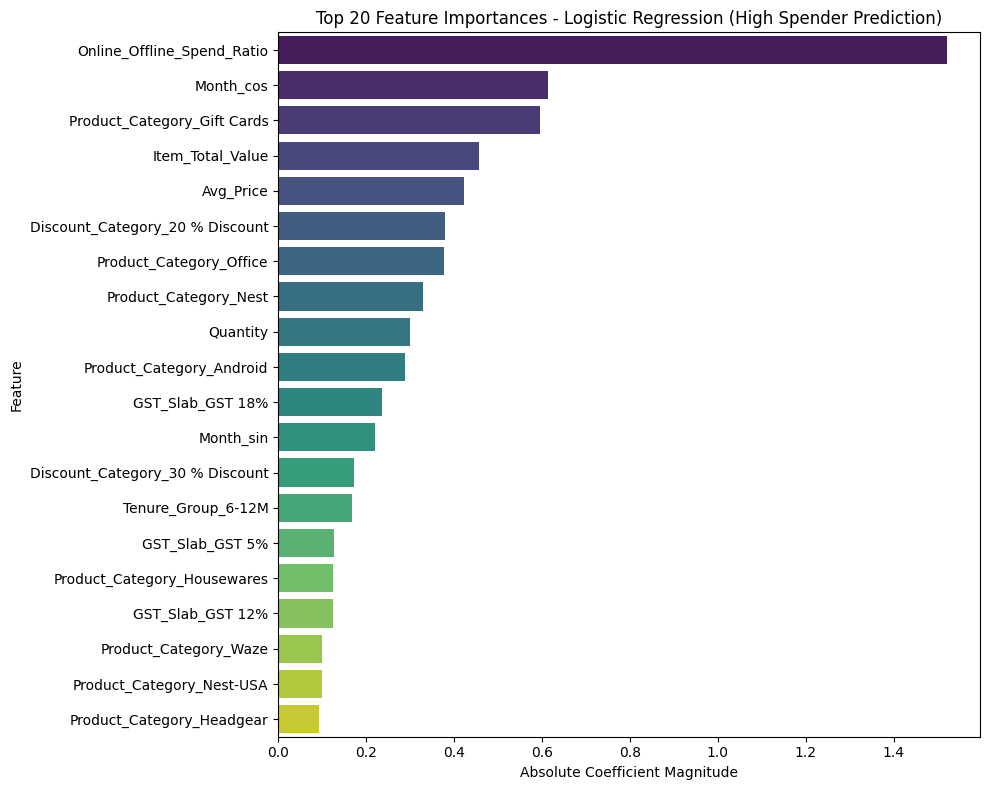

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming log_reg_hs is your trained Logistic Regression model
# and X_train_hs contains the training features (to get column names)

if 'log_reg_hs' in locals() and 'X_train_hs' in locals():
    # Use the coefficients for logistic regression
    importances = log_reg_hs.coef_[0]  # Get coefficients for the first class
    feature_names = X_train_hs.columns

    # Create a DataFrame for better visualization
    # Take the absolute value of coefficients for importance magnitude
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': np.abs(importances)})

    # Sort by importance
    feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

    print("\nFeature Importances from Logistic Regression (Top 20 - based on absolute coefficients):")
    print(feature_importance_df.head(20))

    # Plot feature importances (e.g., top 20)
    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='viridis')
    plt.title('Top 20 Feature Importances - Logistic Regression (High Spender Prediction)')
    plt.xlabel('Absolute Coefficient Magnitude')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

else:
    print("Ensure 'log_reg_hs' (trained Logistic Regression model) and 'X_train_hs' (training features) are available.")

Target column for plotting: High_Spender
Number of features to plot against target: 44

Identified 35 binary-like features for count plots.
Identified 9 continuous-like features for distribution plots.

Generating plots for binary-like features...


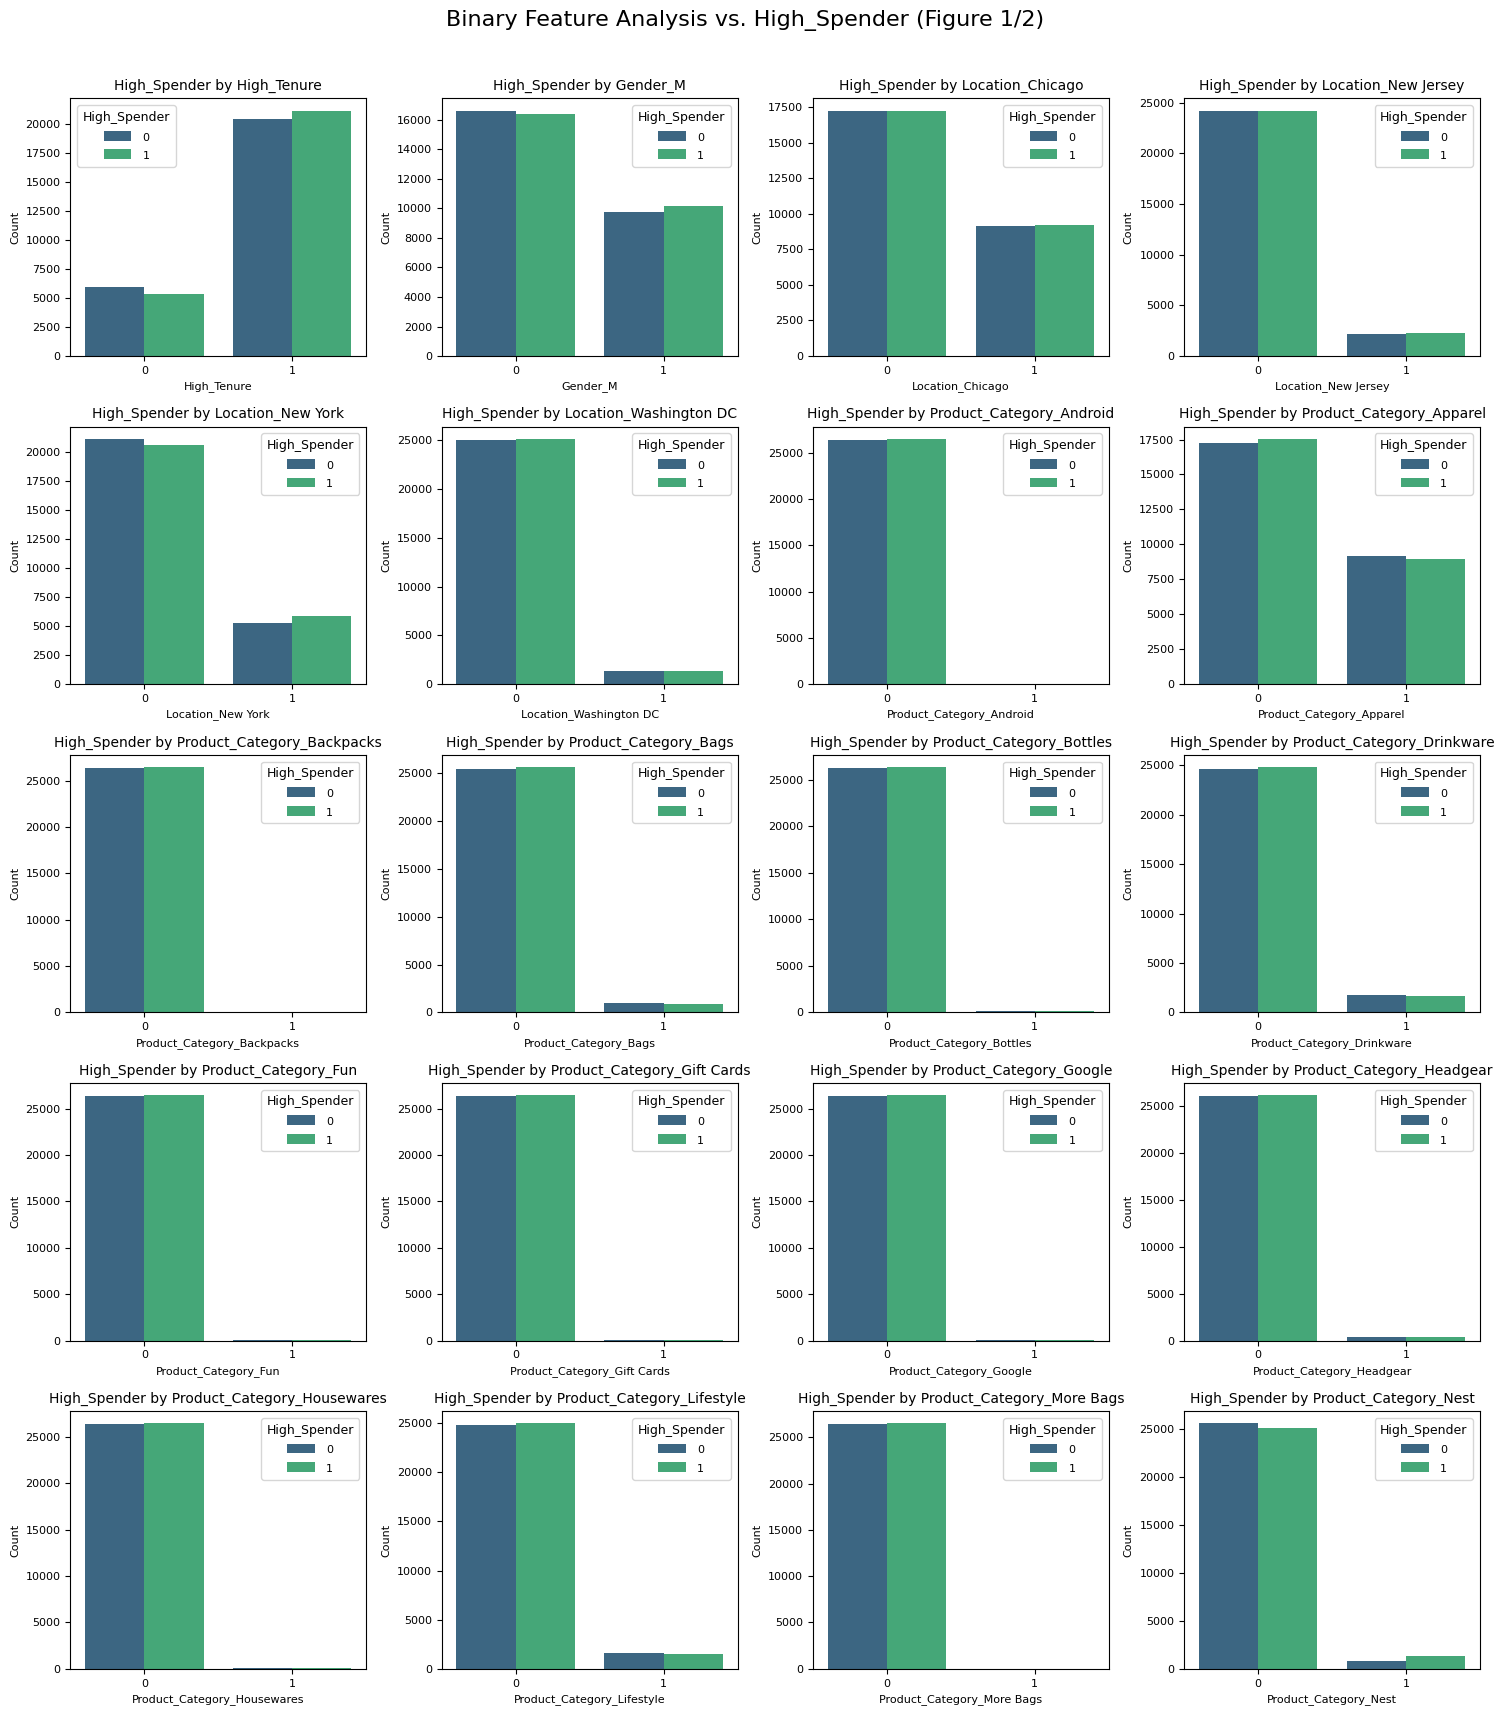

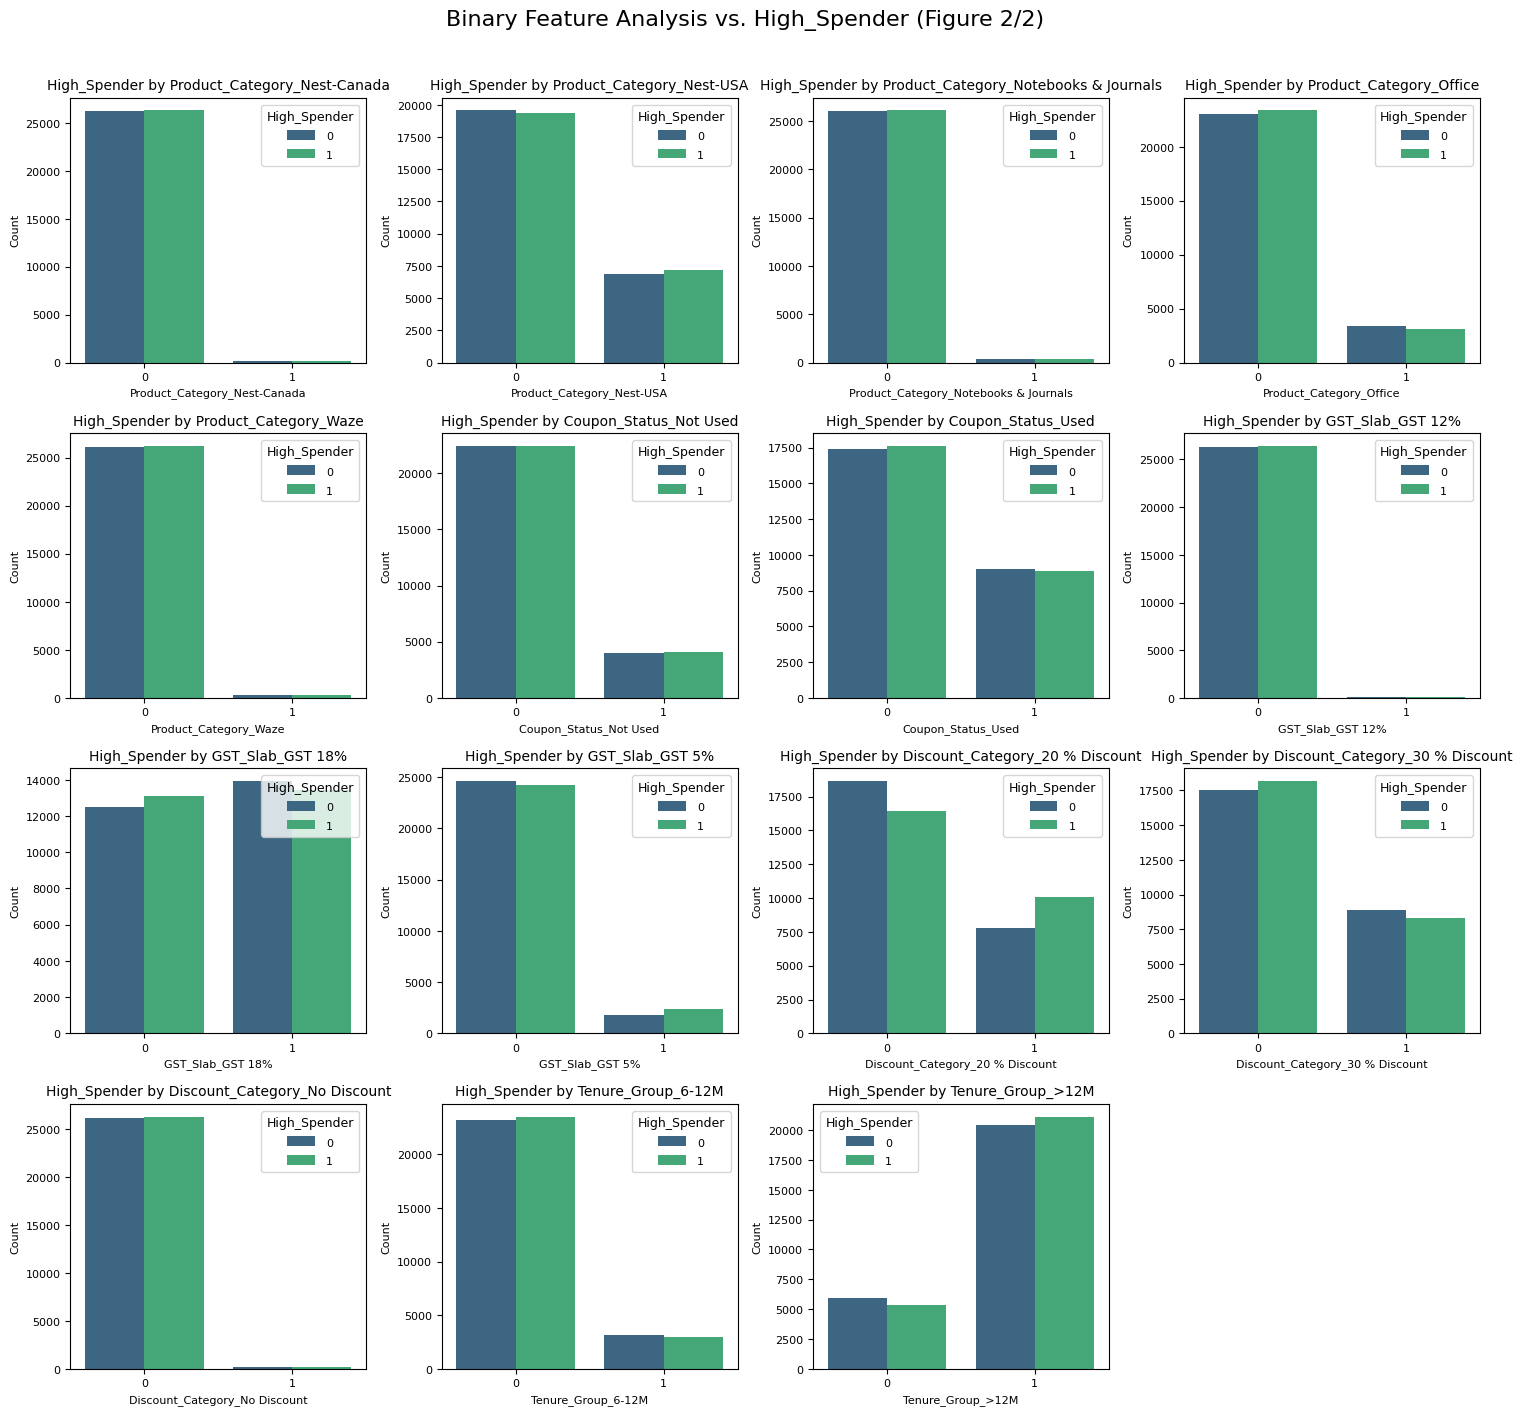


Generating plots for continuous-like features...


<ipython-input-68-68146e04525e>:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=feature, data=data_df, ax=ax, palette='viridis')
<ipython-input-68-68146e04525e>:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=feature, data=data_df, ax=ax, palette='viridis')
<ipython-input-68-68146e04525e>:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=feature, data=data_df, ax=ax, palette='viridis')
<ipython-input-68-68146e04525e>:118: FutureWarning: 

Passing `palette` without assigning `hue` is depr

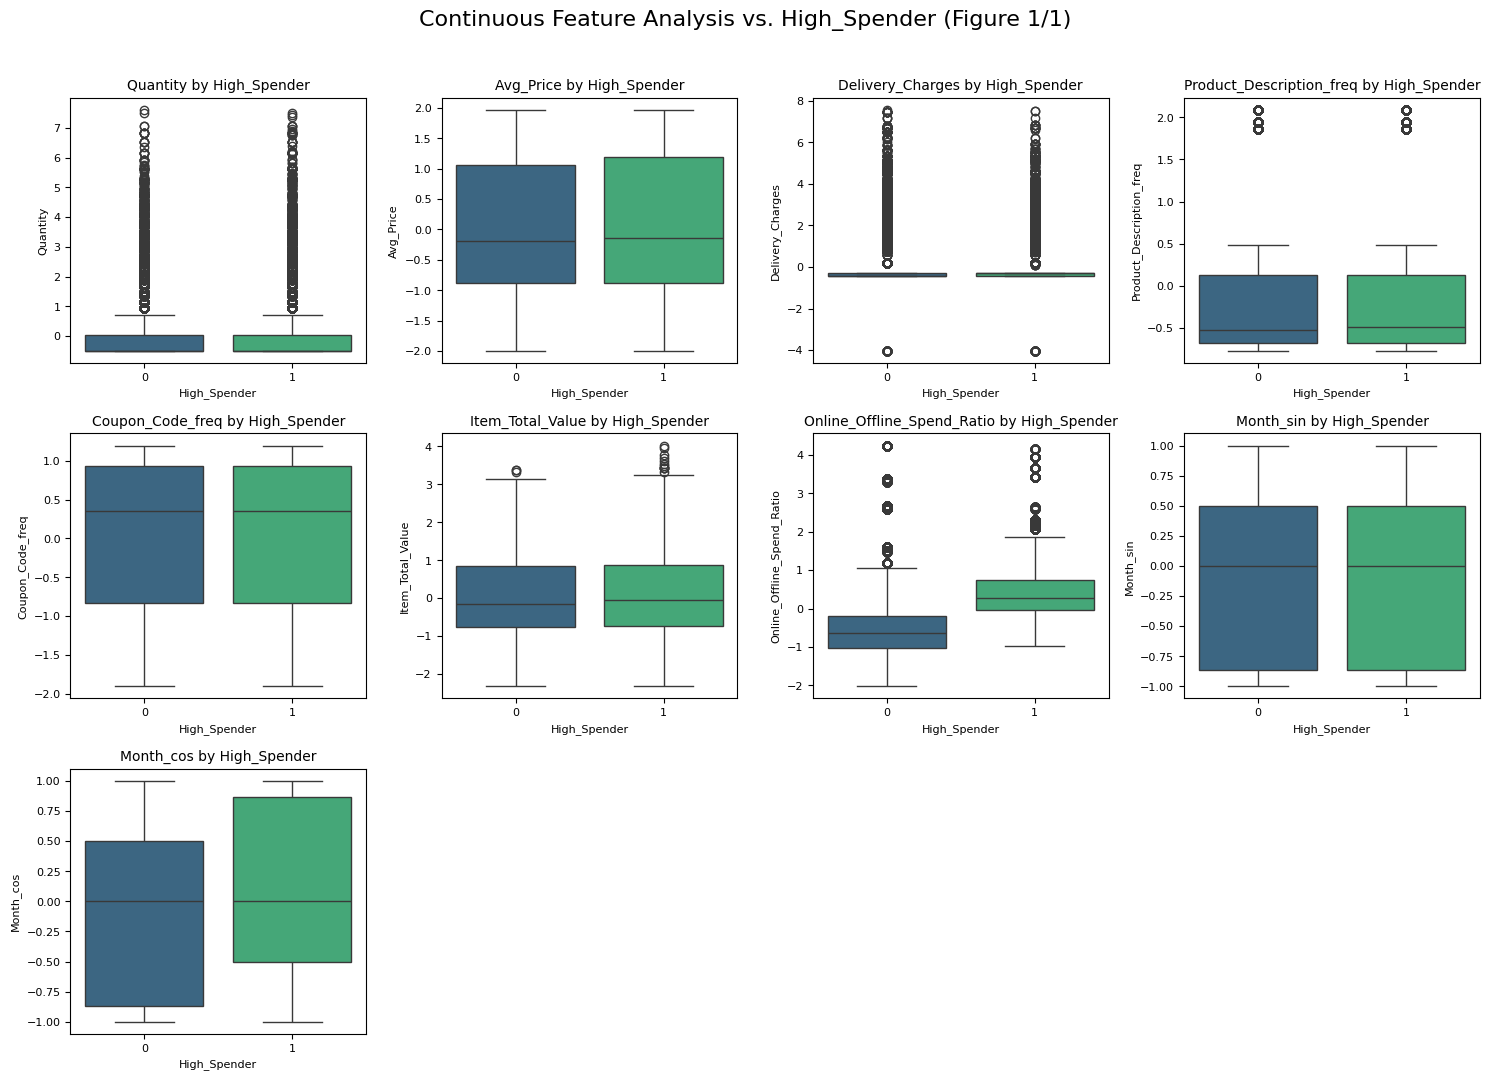


Plot generation process complete. Review the displayed figures.


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 0: Prepare your DataFrame 'df' ---
# Ensure 'df' is correctly defined as per the note above.
# It should contain 'High_Spender' and all 44 features from X_hs.
# If 'df' is not defined, you'll need to load/recreate it.
# For example, if you previously defined X_hs and y_hs (before train_test_split):
# if 'X_hs' in locals() and 'y_hs' in locals():
#     df_plot_source = pd.concat([X_hs, y_hs], axis=1)
# else:
#     print("Error: X_hs and y_hs (features and target before split) are not defined.")
#     print("Please ensure you have the correct DataFrame for plotting.")
#     # df_plot_source = pd.DataFrame() # Fallback to prevent errors, you'd need to load your data
# This script will assume 'df' is the correct DataFrame.

target_column_name = 'High_Spender'

if target_column_name not in df.columns:
    print(f"Target column '{target_column_name}' not found in df. Please ensure df is correctly defined.")
    # In a real notebook, you would stop and fix the df state here.
    # For this script, we'll use a placeholder if it fails.
    feature_columns = []
else:
    # Define feature_columns based on what X_hs would have been
    potential_leakers_and_target = [target_column_name, 'Total_Spend', 'Offline_Spend', 'Online_Spend']
    feature_columns = [col for col in df.columns if col not in potential_leakers_and_target]
    # Further ensure identifiers are out if they somehow persisted
    # feature_columns = [col for col in feature_columns if col not in ['CustomerID', 'Transaction_ID']]

print(f"Target column for plotting: {target_column_name}")
print(f"Number of features to plot against target: {len(feature_columns)}")

# --- Step 1: Identify feature types for appropriate plotting ---
binary_like_features = []
continuous_like_features = []

for col in feature_columns:
    if col in df.columns:
        if df[col].nunique() <= 2 and (df[col].dtype == 'int64' or df[col].dtype == 'uint8' or df[col].dtype == 'int32'):
            unique_vals = df[col].unique()
            if all(val in [0, 1] for val in unique_vals):
                 binary_like_features.append(col)
            else:
                 continuous_like_features.append(col)
        elif df[col].dtype == 'float64' or df[col].dtype == 'float32':
            continuous_like_features.append(col)
        else:
            continuous_like_features.append(col)
    else:
        print(f"Warning: Column {col} listed in feature_columns not found in DataFrame.")


print(f"\nIdentified {len(binary_like_features)} binary-like features for count plots.")
print(f"Identified {len(continuous_like_features)} continuous-like features for distribution plots.")

# --- Step 2: Generate Plots in Subplots ---
plots_per_figure = 20  # Max 5 rows x 4 columns
ncols = 4
nrows = 5 # (plots_per_figure + ncols - 1) // ncols # Calculate rows needed

# Plotting function for binary features
def plot_binary_features_subplots(features_list, target_col, data_df):
    num_features = len(features_list)
    num_figures = (num_features + plots_per_figure - 1) // plots_per_figure

    feature_idx = 0
    for fig_num in range(num_figures):
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 18))
        axes = axes.flatten() # Flatten to 1D array for easy iteration

        plots_in_this_figure = 0
        for i in range(plots_per_figure):
            if feature_idx < num_features:
                ax = axes[i]
                feature = features_list[feature_idx]
                if feature in data_df.columns:
                    sns.countplot(x=feature, hue=target_col, data=data_df, ax=ax, palette='viridis')
                    ax.set_title(f'{target_col} by {feature}', fontsize=10)
                    ax.set_xlabel(feature, fontsize=8)
                    ax.set_ylabel('Count', fontsize=8)
                    ax.tick_params(axis='both', which='major', labelsize=8)
                    if data_df[feature].nunique() <=2 : # Ensure x-ticks are appropriate for binary
                         ax.set_xticks([0,1])
                         ax.set_xticklabels(['0','1'])
                    if ax.get_legend() is not None:
                        ax.get_legend().set_title(target_col)
                        plt.setp(ax.get_legend().get_texts(), fontsize='8')
                        plt.setp(ax.get_legend().get_title(), fontsize='9')

                feature_idx += 1
                plots_in_this_figure +=1
            else:
                fig.delaxes(axes[i]) # Remove unused subplots

        fig.suptitle(f'Binary Feature Analysis vs. {target_col} (Figure {fig_num+1}/{num_figures})', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout to make room for suptitle
        plt.show()

# Plotting function for continuous features
def plot_continuous_features_subplots(features_list, target_col, data_df):
    num_features = len(features_list)
    num_figures = (num_features + plots_per_figure - 1) // plots_per_figure

    feature_idx = 0
    for fig_num in range(num_figures):
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 18))
        axes = axes.flatten()

        plots_in_this_figure = 0
        for i in range(plots_per_figure):
            if feature_idx < num_features:
                ax = axes[i]
                feature = features_list[feature_idx]
                if feature in data_df.columns:
                    sns.boxplot(x=target_col, y=feature, data=data_df, ax=ax, palette='viridis')
                    # Alternatively, use histplot/kdeplot:
                    # sns.histplot(data=data_df, x=feature, hue=target_col, kde=True, multiple="stack", ax=ax)
                    ax.set_title(f'{feature} by {target_col}', fontsize=10)
                    ax.set_xlabel(target_col, fontsize=8)
                    ax.set_ylabel(feature, fontsize=8)
                    ax.tick_params(axis='both', which='major', labelsize=8)
                feature_idx += 1
                plots_in_this_figure +=1
            else:
                fig.delaxes(axes[i])

        fig.suptitle(f'Continuous Feature Analysis vs. {target_col} (Figure {fig_num+1}/{num_figures})', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()

if target_column_name in df.columns and (binary_like_features or continuous_like_features) :
    print("\nGenerating plots for binary-like features...")
    if binary_like_features:
        plot_binary_features_subplots(binary_like_features, target_column_name, df)
    else:
        print("No binary-like features to plot.")

    print("\nGenerating plots for continuous-like features...")
    if continuous_like_features:
        plot_continuous_features_subplots(continuous_like_features, target_column_name, df)
    else:
        print("No continuous-like features to plot.")

    print("\nPlot generation process complete. Review the displayed figures.")
else:
    if target_column_name not in df.columns:
         print(f"Cannot generate plots as target column '{target_column_name}' is missing.")
    else:
        print("No features identified for plotting. Please check feature_columns definition and DataFrame content.")

In [69]:
print(df.columns)

Index(['Quantity', 'Avg_Price', 'Delivery_Charges', 'Offline_Spend',
       'Online_Spend', 'High_Spender', 'High_Tenure',
       'Product_Description_freq', 'Coupon_Code_freq', 'Gender_M',
       'Location_Chicago', 'Location_New Jersey', 'Location_New York',
       'Location_Washington DC', 'Product_Category_Android',
       'Product_Category_Apparel', 'Product_Category_Backpacks',
       'Product_Category_Bags', 'Product_Category_Bottles',
       'Product_Category_Drinkware', 'Product_Category_Fun',
       'Product_Category_Gift Cards', 'Product_Category_Google',
       'Product_Category_Headgear', 'Product_Category_Housewares',
       'Product_Category_Lifestyle', 'Product_Category_More Bags',
       'Product_Category_Nest', 'Product_Category_Nest-Canada',
       'Product_Category_Nest-USA', 'Product_Category_Notebooks & Journals',
       'Product_Category_Office', 'Product_Category_Waze',
       'Coupon_Status_Not Used', 'Coupon_Status_Used', 'GST_Slab_GST 12%',
       'GST_Slab_G

In [70]:
df.to_csv('final_feature_engineered_df_before_modeling.csv', index=False)

 We've successfully calculated the Recency, Frequency, and Monetary (RFM) values for 1468 unique customers. These features have been saved to customer_rfm_features.csv.

Here's a quick look at the characteristics of these RFM values:

Recency: Ranges from 1 day to 365 days, with an average of about 145 days.
Frequency: Ranges from 1 transaction to 328 transactions, with an average of about 18.
Monetary: Ranges from  1.00 to  75,937.55, with an average of about 3,181.74.

Successfully loaded 'RFM dataset.csv'
Columns found in the uploaded RFM dataset: ['CustomerID', 'Recency', 'Frequency', 'Monetary']
First 5 rows of the uploaded RFM dataset:
   CustomerID  Recency  Frequency  Monetary
0     12346.0      108          1     30.99
1     12347.0       60         31  13834.90
2     12348.0       74          8   1442.12
3     12350.0       18         11   1360.07
4     12356.0      108         13   1442.47
Set 'CustomerID' as index.

--- Visualizing Original RFM Distributions ---


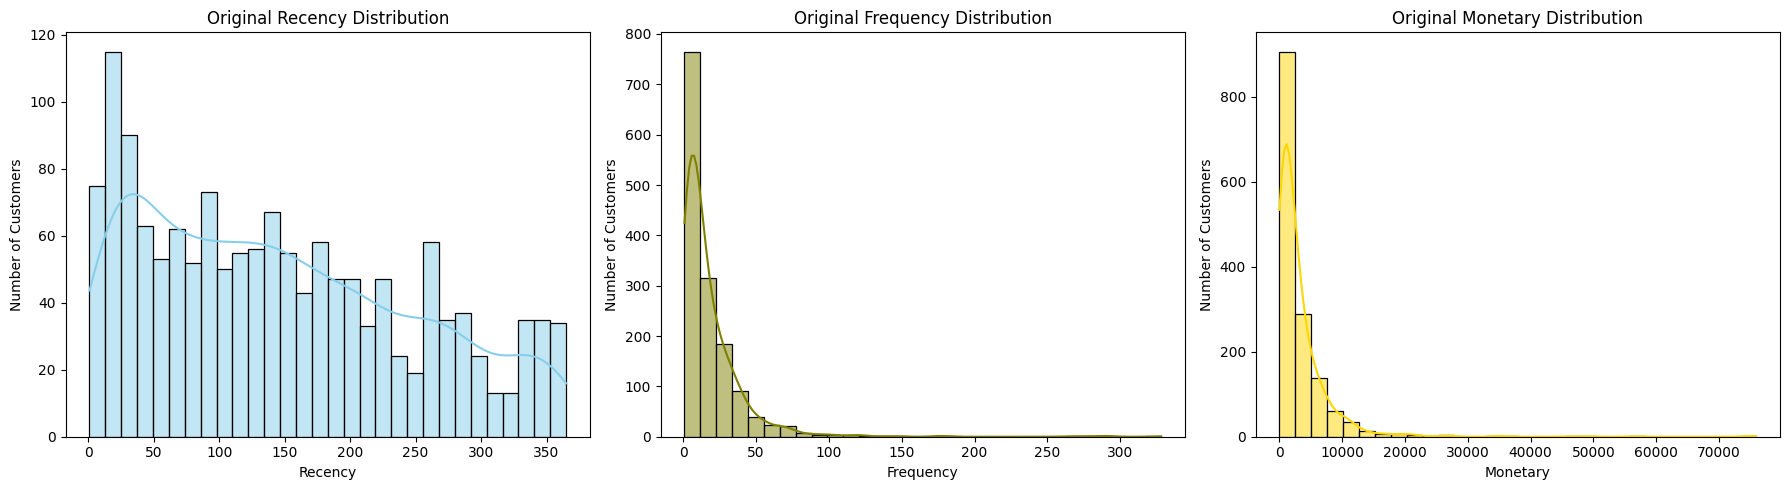


Applied log1p transformation to RFM features.
Descriptive statistics of log-transformed features:
           Recency    Frequency     Monetary
count  1468.000000  1468.000000  1468.000000
mean      4.614139     2.461120     7.209496
std       1.014845     0.992149     1.580285
min       0.693147     0.693147     0.693147
25%       4.043051     1.791759     6.482208
50%       4.890349     2.484907     7.468173
75%       5.402677     3.178054     8.273563
max       5.902633     5.796058    11.237680

--- Visualizing Log-Transformed RFM Distributions ---


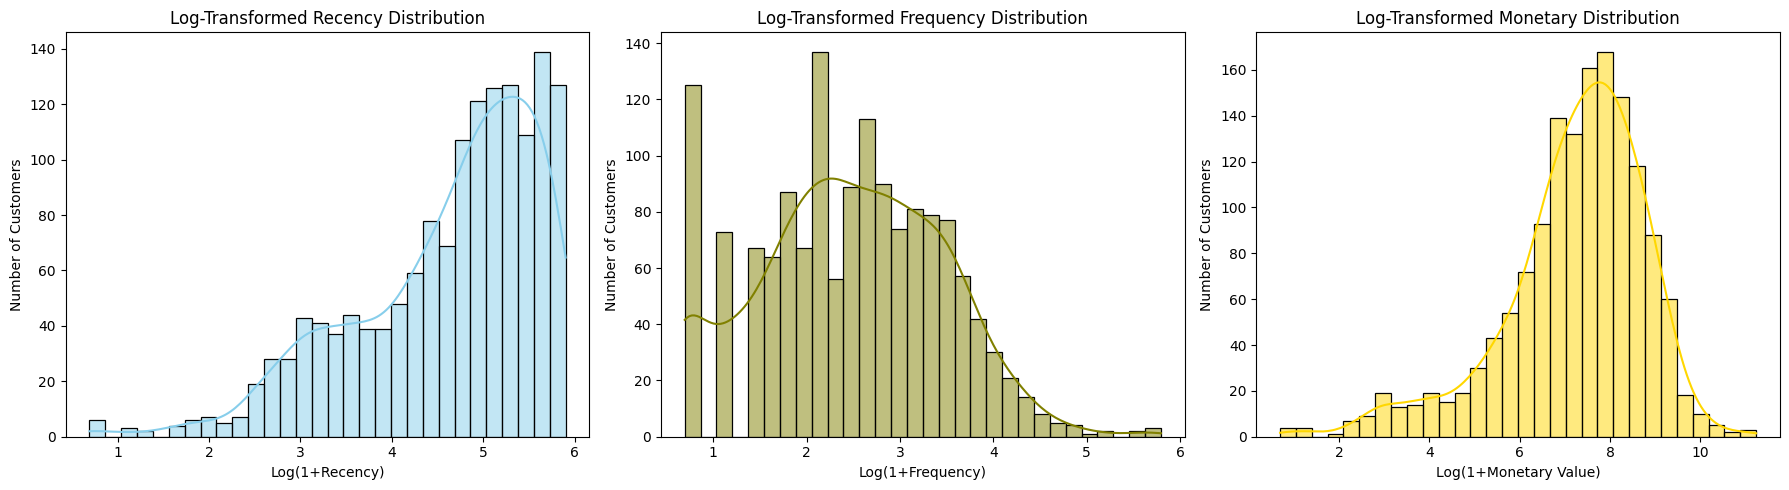


--- Scaled RFM Features (Log-Transformed then Standardized) ---
             Recency  Frequency  Monetary
CustomerID                               
12346.0     0.076106  -1.782571 -2.370046
12347.0    -0.496072   1.012911  1.472088
12348.0    -0.292411  -0.266074  0.041188
12350.0    -1.645836   0.023983  0.004134
12356.0     0.076106   0.179406  0.041342

Descriptive statistics of scaled features:
            Recency     Frequency      Monetary
count  1.468000e+03  1.468000e+03  1.468000e+03
mean  -4.937014e-16 -1.306857e-16 -1.040645e-16
std    1.000341e+00  1.000341e+00  1.000341e+00
min   -3.864951e+00 -1.782571e+00 -4.124932e+00
25%   -5.629252e-01 -6.748873e-01 -4.603825e-01
50%    2.722628e-01  2.398302e-02  1.637461e-01
75%    7.772686e-01  7.228533e-01  6.735683e-01
max    1.270079e+00  3.362473e+00  2.549892e+00


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the RFM dataset provided by the user
try:
    rfm_df = pd.read_csv("/content/drive/MyDrive/Task_dataset/RFM dataset.csv")
    print("Successfully loaded 'RFM dataset.csv'")
    print("Columns found in the uploaded RFM dataset:", rfm_df.columns.tolist())
    print("First 5 rows of the uploaded RFM dataset:")
    print(rfm_df.head())
except FileNotFoundError:
    print("Error: 'RFM dataset.csv' not found. Please ensure the file is uploaded correctly.")
    exit()
except Exception as e:
    print(f"An error occurred while loading 'RFM dataset.csv': {e}")
    exit()

# --- Identify and Set CustomerID as index ---
if 'CustomerID' in rfm_df.columns:
    rfm_df.set_index('CustomerID', inplace=True)
    print("Set 'CustomerID' as index.")
elif rfm_df.columns[0] == 'Unnamed: 0':
    # If the first column is 'Unnamed: 0', it's likely the CustomerID from a previous save
    rfm_df.rename(columns={'Unnamed: 0': 'CustomerID'}, inplace=True)
    rfm_df.set_index('CustomerID', inplace=True)
    print("Renamed 'Unnamed: 0' to 'CustomerID' and set as index.")
elif 'customerid' in rfm_df.columns[0].lower().replace(' ', ''):
    potential_id_col = rfm_df.columns[0]
    print(f"Attempting to use column '{potential_id_col}' as CustomerID.")
    if rfm_df[potential_id_col].nunique() >= len(rfm_df) * 0.95:
        rfm_df.rename(columns={potential_id_col: 'CustomerID'}, inplace=True)
        rfm_df.set_index('CustomerID', inplace=True)
        print(f"Renamed '{potential_id_col}' to 'CustomerID' and set as index.")
    else:
        print(f"Warning: Column '{potential_id_col}' does not appear to be a unique identifier. Using existing default index.")
elif pd.api.types.is_numeric_dtype(rfm_df.index) and rfm_df.index.name is None:
     rfm_df.index.name = 'CustomerID'
     print("Named the existing numeric index as 'CustomerID'.")
else:
    print("Warning: Could not automatically identify a CustomerID column or suitable index. Clustering will proceed using existing index or row numbers.")

# Ensure the RFM columns are named 'Recency', 'Frequency', 'Monetary'
rfm_feature_columns = ['Recency', 'Frequency', 'Monetary']
# Check if these columns exist. Case-insensitivity might be needed or exact match.
# For simplicity, assuming exact match for now.
actual_cols = {}
for rfm_col_name in rfm_feature_columns:
    found_col = None
    for df_col in rfm_df.columns:
        if rfm_col_name.lower() == df_col.lower():
            found_col = df_col
            break
    if found_col:
        actual_cols[rfm_col_name] = found_col
    else:
        print(f"Error: Expected RFM column like '{rfm_col_name}' not found in the dataset.")
        print(f"Available columns: {rfm_df.columns.tolist()}")
        exit()

# Use the actual column names found
recency_col = actual_cols['Recency']
frequency_col = actual_cols['Frequency']
monetary_col = actual_cols['Monetary']


# --- 1. Visualize Original RFM Distributions ---
print("\n--- Visualizing Original RFM Distributions ---")
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(rfm_df[recency_col], kde=True, bins=30, color='skyblue')
plt.title('Original Recency Distribution')
plt.xlabel(recency_col)
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 2)
sns.histplot(rfm_df[frequency_col], kde=True, bins=30, color='olive')
plt.title('Original Frequency Distribution')
plt.xlabel(frequency_col)
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 3)
sns.histplot(rfm_df[monetary_col], kde=True, bins=30, color='gold')
plt.title('Original Monetary Distribution')
plt.xlabel(monetary_col)
plt.ylabel('Number of Customers')

plt.tight_layout()

plt.show()

# --- 2. Data Transformation (Log Transform) ---
rfm_log_transformed = pd.DataFrame(index=rfm_df.index)

for col_name, actual_col_name in actual_cols.items():
    if (rfm_df[actual_col_name] < 0).any():
        print(f"Error: Column '{actual_col_name}' contains negative values, which cannot be log-transformed directly.")
        print(rfm_df[rfm_df[actual_col_name] < 0])
        exit()
    # Using actual_col_name for accessing data, col_name (Recency, Frequency, Monetary) for new df
    rfm_log_transformed[col_name] = np.log1p(rfm_df[actual_col_name])

print("\nApplied log1p transformation to RFM features.")
print("Descriptive statistics of log-transformed features:")
print(rfm_log_transformed.describe())


# --- Visualize Transformed RFM Distributions ---
print("\n--- Visualizing Log-Transformed RFM Distributions ---")
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(rfm_log_transformed['Recency'], kde=True, bins=30, color='skyblue')
plt.title('Log-Transformed Recency Distribution')
plt.xlabel('Log(1+Recency)')
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 2)
sns.histplot(rfm_log_transformed['Frequency'], kde=True, bins=30, color='olive')
plt.title('Log-Transformed Frequency Distribution')
plt.xlabel('Log(1+Frequency)')
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 3)
sns.histplot(rfm_log_transformed['Monetary'], kde=True, bins=30, color='gold')
plt.title('Log-Transformed Monetary Distribution')
plt.xlabel('Log(1+Monetary Value)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

# --- 3. Scaling the Data ---
scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log_transformed)

rfm_scaled_df = pd.DataFrame(rfm_scaled_array, columns=rfm_log_transformed.columns, index=rfm_log_transformed.index)

print("\n--- Scaled RFM Features (Log-Transformed then Standardized) ---")
print(rfm_scaled_df.head())
print("\nDescriptive statistics of scaled features:")
print(rfm_scaled_df.describe())


The original distributions of Recency, Frequency, and Monetary value were indeed skewed, as expected. The log transformation helped to make these distributions more symmetrical, and scaling has standardized them, which is ideal for clustering algorithms.

Here are the generated plots:

Original RFM Distributions:

Log-Transformed RFM Distributions:

The preprocessed data, ready for clustering, has been saved to customer_rfm_scaled_features.csv. You can download it here: customer_rfm_scaled_features.csv

Now, let's move on to the next crucial step: determining the optimal number of customer segments (K).

To do this, I will:

Use the Elbow Method: This involves running K-Means clustering for a range of K values (e.g., from 2 to 10) and plotting the Within-Cluster Sum of Squares (WCSS). We look for an "elbow" point where adding more clusters doesn't significantly reduce WCSS.
Use Silhouette Analysis: This method measures how similar an object is to its own cluster compared to other clusters. The silhouette score ranges from -1 to 1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters. We'll calculate the average silhouette score for different values of K.

Successfully loaded 'customer_rfm_scaled_features.csv'
Set 'CustomerID' column as index.

--- Determining Optimal K using Elbow Method ---


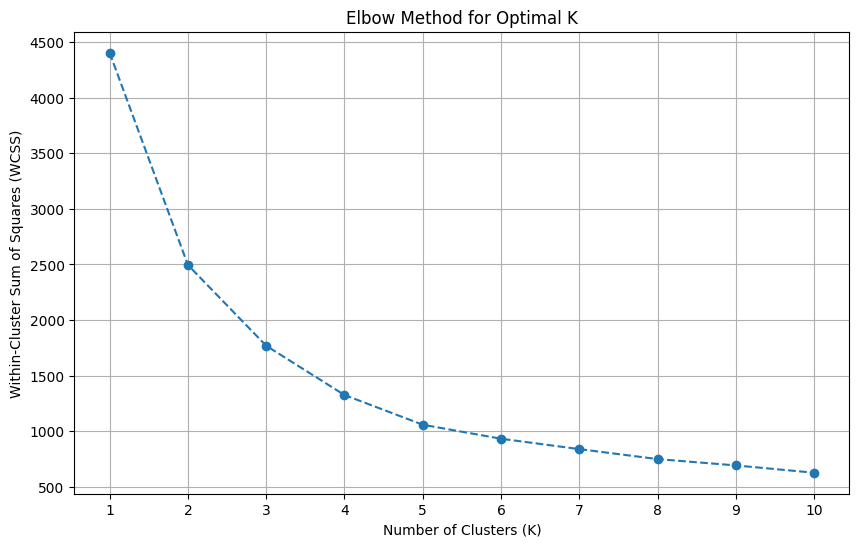


--- Determining Optimal K using Silhouette Analysis ---
For K=2, the average silhouette_score is 0.3759
For K=3, the average silhouette_score is 0.3499
For K=4, the average silhouette_score is 0.3645
For K=5, the average silhouette_score is 0.3563
For K=6, the average silhouette_score is 0.3087
For K=7, the average silhouette_score is 0.3043
For K=8, the average silhouette_score is 0.3066
For K=9, the average silhouette_score is 0.2884
For K=10, the average silhouette_score is 0.2950


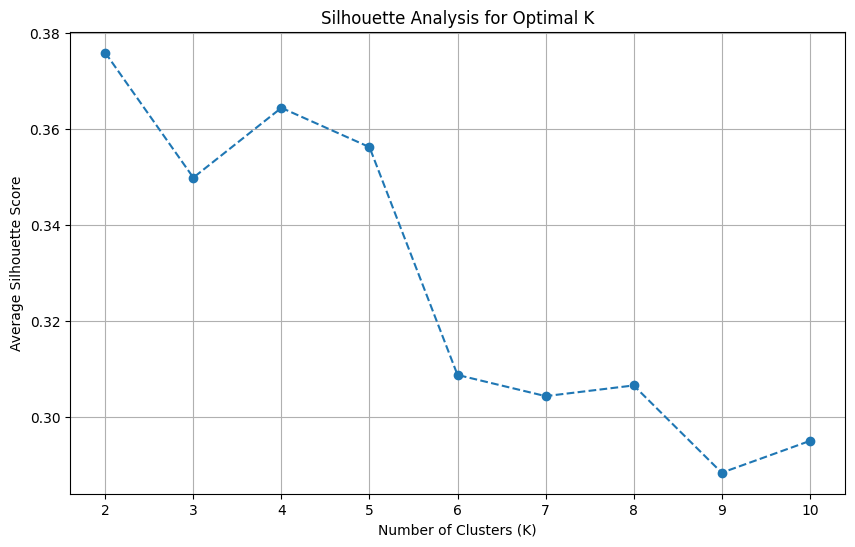

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the scaled RFM features
try:
    # This file was generated in a previous successful step.
    # The file tag was [file-tag: code-generated-file-0-1747716591848986156]
    # The filename is "customer_rfm_scaled_features.csv"
    rfm_scaled_df = pd.read_csv("/content/drive/MyDrive/Task_dataset/customer_rfm_scaled_features.csv.csv")
    print("Successfully loaded 'customer_rfm_scaled_features.csv'")
except FileNotFoundError:
    print("Error: 'customer_rfm_scaled_features.csv' not found. Please ensure it was generated in the previous step.")
    exit()
except Exception as e:
    print(f"An error occurred while loading 'customer_rfm_scaled_features.csv': {e}")
    exit()

# Set CustomerID as index if it's a column
# The CSV 'customer_rfm_scaled_features.csv' should have CustomerID as the first column (index)
# when it was saved with `rfm_scaled_df.to_csv("customer_rfm_scaled_features.csv")`
# if the index was named CustomerID. Pandas to_csv saves the index by default.
# When read_csv is used, the first column is often the index.

if 'CustomerID' in rfm_scaled_df.columns:
    # If 'CustomerID' is explicitly a column name (e.g., if index=False was used during saving)
    rfm_scaled_df.set_index('CustomerID', inplace=True)
    print("Set 'CustomerID' column as index.")
elif rfm_scaled_df.columns[0] == 'CustomerID' and rfm_scaled_df.index.name is None :
    # If the first column is named 'CustomerID' (this is common if index was saved and then read)
    rfm_scaled_df.set_index(rfm_scaled_df.columns[0], inplace=True)
    print(f"Set the first column ('{rfm_scaled_df.index.name}') as index.")
elif rfm_scaled_df.columns[0] == 'Unnamed: 0': # A common case if index was unnamed before saving
    print(f"First column is '{rfm_scaled_df.columns[0]}'. Assuming it's CustomerID and setting it as index.")
    rfm_scaled_df.rename(columns={rfm_scaled_df.columns[0]: 'CustomerID_temp_col_for_index'}, inplace=True)
    rfm_scaled_df.set_index('CustomerID_temp_col_for_index', inplace=True)
    rfm_scaled_df.index.name = 'CustomerID' # Rename the index itself
    print("Set first column as CustomerID index.")
else:
    print(f"Warning: 'CustomerID' column not found as a regular column or as the first column. Current columns: {rfm_scaled_df.columns.tolist()}. Current index name: {rfm_scaled_df.index.name}. Using data as is for clustering, assuming index is already correct or data doesn't have CustomerID in columns.")


# Select only the RFM scaled columns for clustering if other columns exist
# (though 'customer_rfm_scaled_features.csv' should only have R, F, M)
cluster_data = rfm_scaled_df[['Recency', 'Frequency', 'Monetary']]


# --- Determine Optimal K using Elbow Method ---
print("\n--- Determining Optimal K using Elbow Method ---")
wcss = []
k_range = range(1, 11) # Test K from 1 to 10

for k_val in k_range:
    kmeans = KMeans(n_clusters=k_val, init='k-means++', n_init='auto', random_state=42, algorithm='lloyd')
    kmeans.fit(cluster_data)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# --- Determine Optimal K using Silhouette Analysis ---
print("\n--- Determining Optimal K using Silhouette Analysis ---")
silhouette_scores = []
# Silhouette score is not defined for K=1, so start range from 2
k_range_silhouette = range(2, 11)

for k_val in k_range_silhouette:
    kmeans = KMeans(n_clusters=k_val, init='k-means++', n_init='auto', random_state=42, algorithm='lloyd')
    cluster_labels = kmeans.fit_predict(cluster_data)
    silhouette_avg = silhouette_score(cluster_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For K={k_val}, the average silhouette_score is {silhouette_avg:.4f}")

# Plot the Silhouette Analysis graph
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Analysis for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range_silhouette)
plt.grid(True)
plt.show()


We've successfully run the Elbow Method and Silhouette Analysis to help determine the optimal number of customer segments (K).

Here are the generated plots:

Elbow Method Plot: This plot shows the Within-Cluster Sum of Squares (WCSS) for different values of K. We typically look for an "elbow" point where adding more clusters provides diminishing returns (i.e., WCSS decreases less sharply).

Silhouette Analysis Plot: This plot shows the average silhouette score for different values of K. A higher silhouette score (closer to 1) indicates better-defined clusters.

Here are the average silhouette scores for K=2 to K=10:

K=2: 0.3759
K=3: 0.3499
K=4: 0.3645
K=5: 0.3563
K=6: 0.3087
K=7: 0.3043
K=8: 0.3066
K=9: 0.2884
K=10: 0.2950
Interpretation:
Looking at the Elbow Method plot, the "elbow" isn't sharply defined, which is common. There seems to be a bend around K=3 or K=4, after which the decrease in WCSS becomes more gradual.
From the Silhouette Analysis, K=2 has the highest score (0.3759), suggesting that two distinct groups might be the most mathematically separated. K=4 also shows a relatively good score (0.3645), which is the second highest.
Often, for business purposes, 2 segments might be too few for targeted strategies. Values of K like 3, 4, or 5 are commonly chosen for RFM segmentation to get more granular insights. Given K=4 has the second-highest silhouette score and is a common choice for a good balance of detail and interpretability, it could be a good candidate.

Silhouette Scores:

K=2 gave the highest average silhouette score (0.3759). This statistically suggests that the data separates most cleanly into two distinct groups.
K=4 yielded the second-highest score (0.3645).
K=3 (0.3499) and K=5 (0.3563) also had reasonable scores.
Generally, scores above 0.25 are considered to indicate reasonable structure, and scores above 0.5 are strong (though less common with noisy real-world data like RFM). Our top scores are in a decent range.
Elbow Method (WCSS):

The WCSS plot showed a noticeable "elbow" or bend around K=3 and K=4. This is the point where adding more clusters starts to give diminishing returns in terms of reducing within-cluster variance. Adding clusters beyond this point might lead to overfitting or creating less distinct segments.
Balancing Statistical Measures with Practical Utility:

K=2: While having the highest silhouette score, leading to two segments (e.g., "high value" vs. "low value") might be too broad for many targeted marketing or retention strategies. You might miss nuances within these large groups.
K=3: This aligns with one of the elbow points and has a decent silhouette score. It offers more granularity than K=2 and is often a good starting point for interpretable segments.
K=4: This also aligns with an elbow point and boasts the second-highest silhouette score. The drop in silhouette score from K=2 (0.3759) to K=4 (0.3645) is relatively small (about 0.0114). This slight trade-off in the mathematical separation metric might be well worth the gain in having more refined segments. Four segments often provide a good balance for RFM analysis, potentially allowing for identification of groups like "champions," "loyal customers," "at-risk customers," and "new/hibernating customers."
K=5: The silhouette score is still good, but there isn't a strong statistical push from the elbow or silhouette scores to go beyond K=4 unless there's a specific business need for more segments.
Recommendation:

Considering both the statistical measures and the common practical application of RFM segmentation, K=4 appears to be the most robust choice.

It has a strong silhouette score (second highest).
It corresponds to an "elbow" in the WCSS plot, indicating a good trade-off between variance explained and the number of clusters.
It provides a good level of granularity for actionable business insights without creating overly fragmented or less distinct segments.
While K=2 is statistically optimal in terms of raw silhouette score, K=4 likely offers a better balance for practical application. K=3 would also be a reasonable choice if a simpler segmentation is preferred.

For n_clusters = 2, the average silhouette_score is : 0.3759


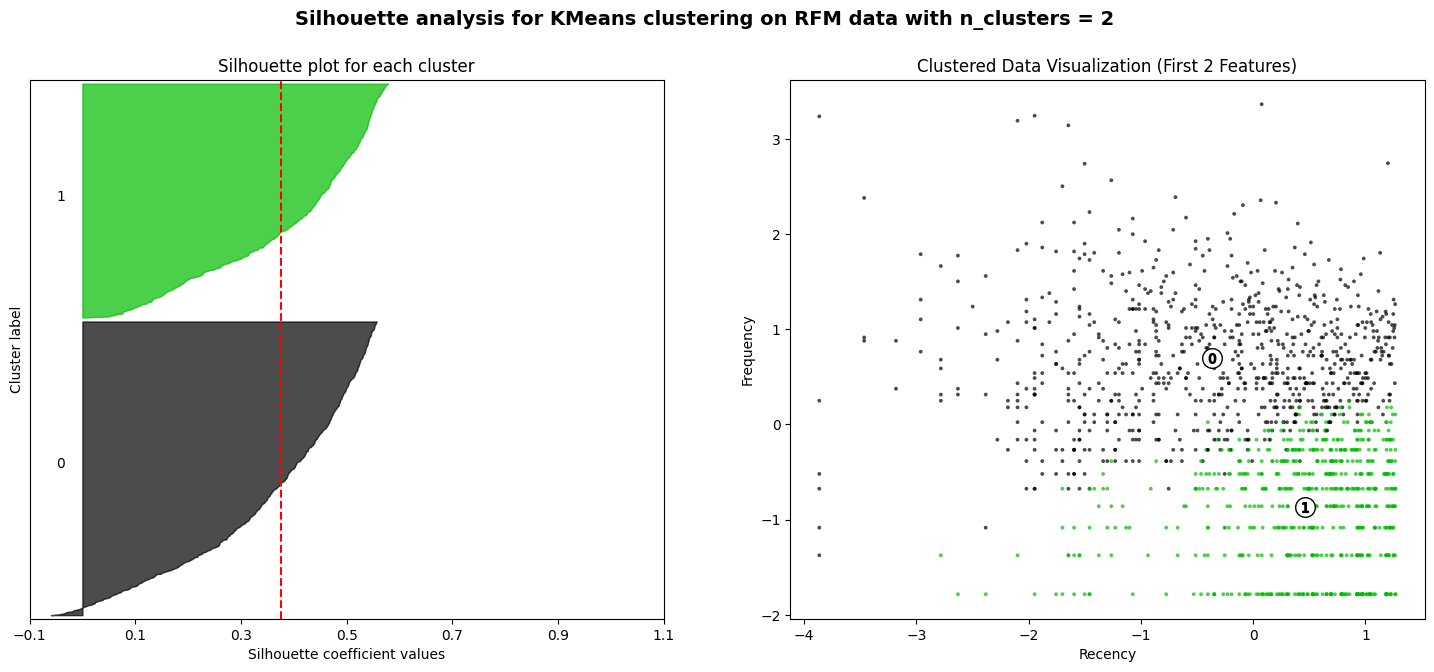

For n_clusters = 3, the average silhouette_score is : 0.3557


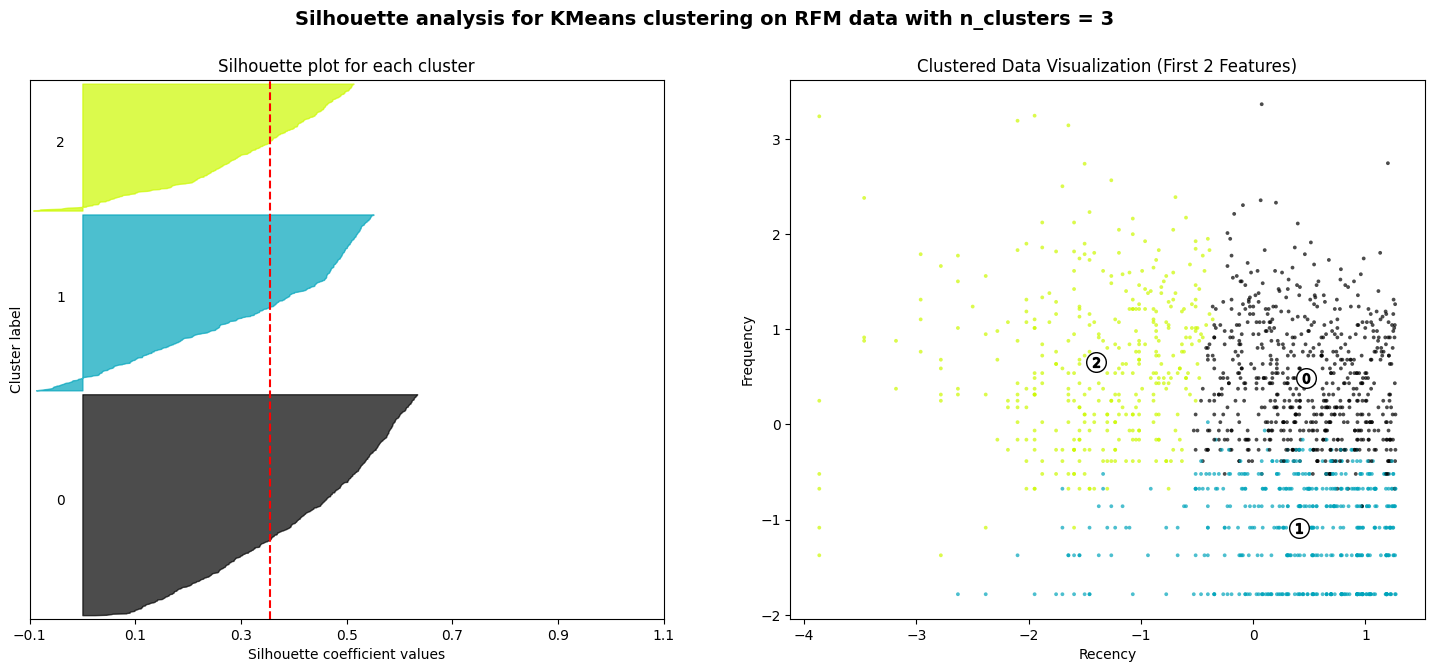

For n_clusters = 4, the average silhouette_score is : 0.3646


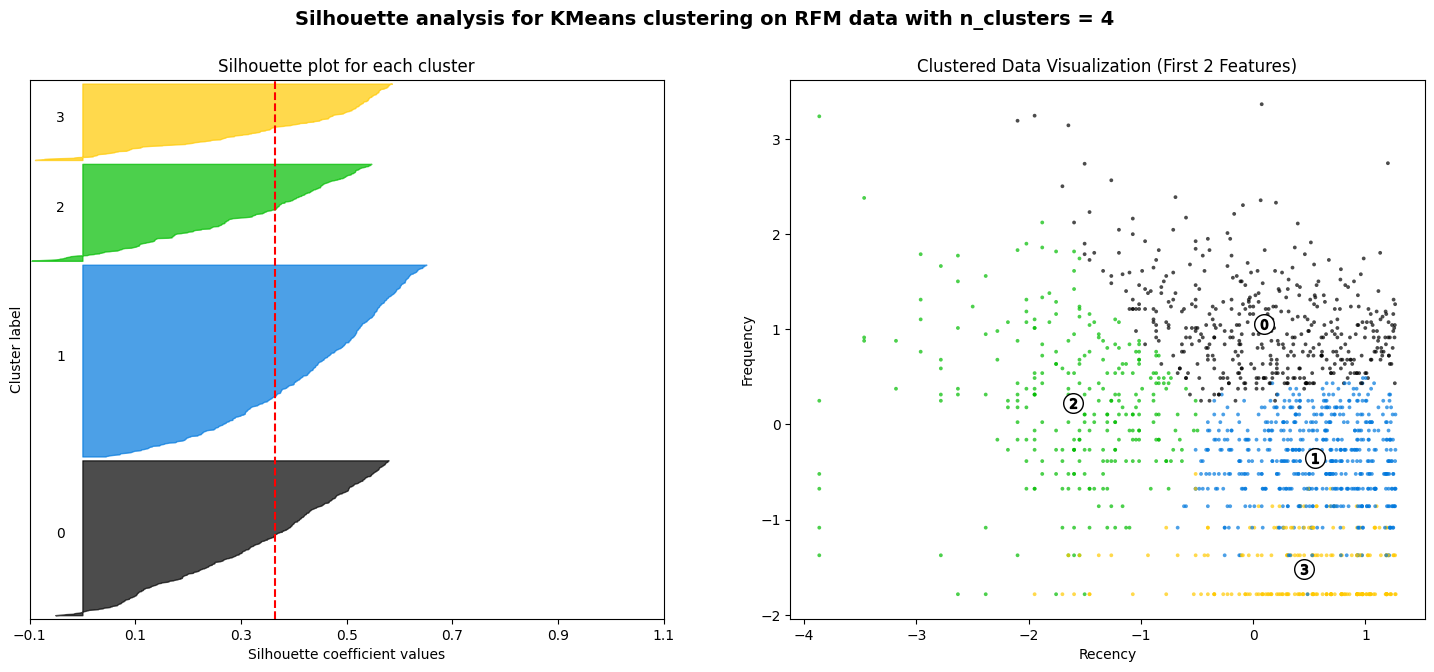

For n_clusters = 5, the average silhouette_score is : 0.3587


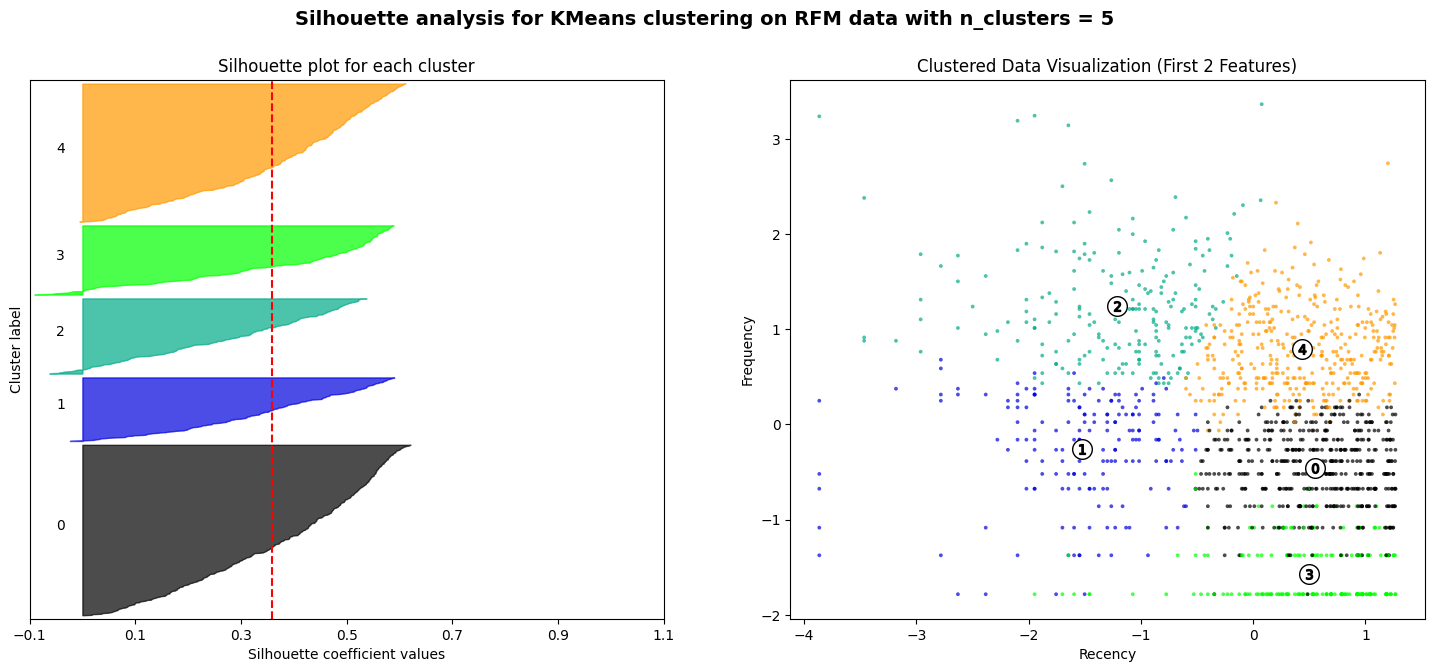

For n_clusters = 6, the average silhouette_score is : 0.3095


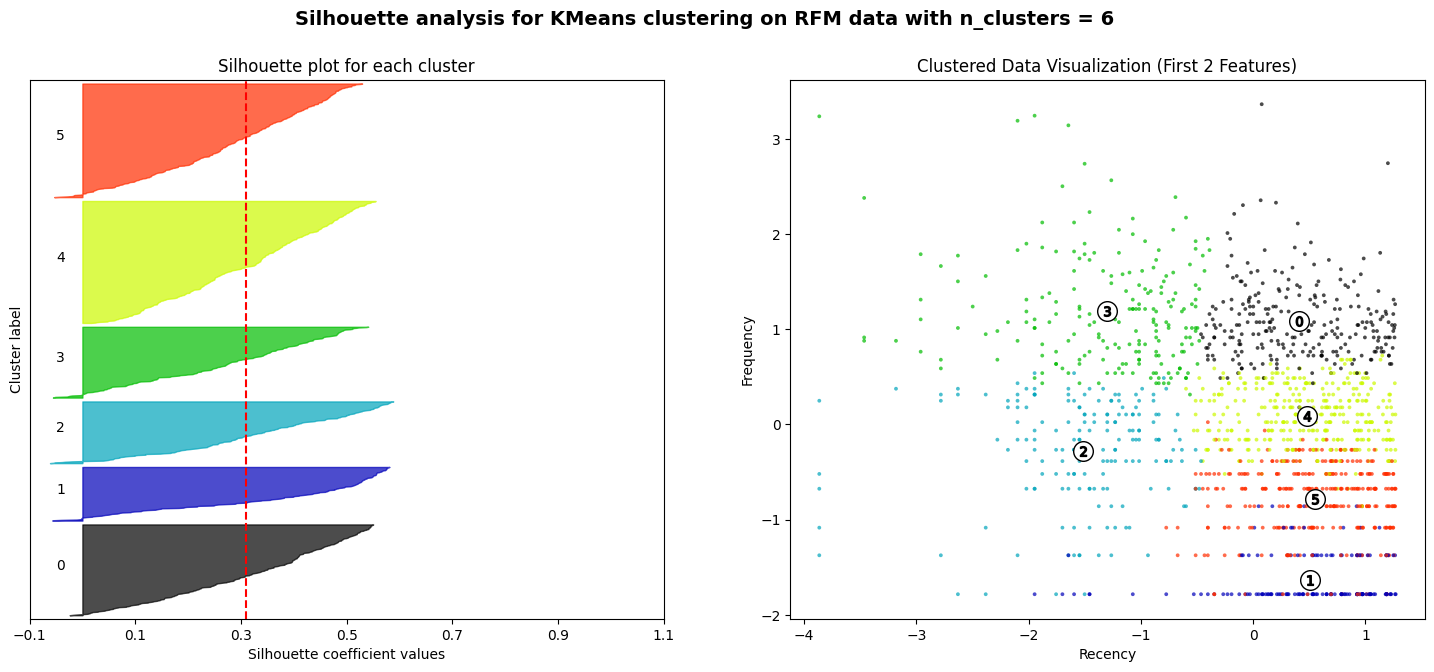

In [73]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# Assuming `cluster_data` is already defined with Recency, Frequency, Monetary
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(cluster_data) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=10, n_init=10)
    cluster_labels = clusterer.fit_predict(cluster_data)

    silhouette_avg = silhouette_score(cluster_data, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(cluster_data, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Silhouette plot for each cluster")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks(np.arange(-0.1, 1.1, 0.2))

    # 2D scatter plot using first two RFM features
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1],
                marker='.', s=30, lw=0, alpha=0.7, c=colors, edgecolor='k')

    centers = clusterer.cluster_centers_
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker=f'${i}$', alpha=1, s=50, edgecolor='k')

    ax2.set_title("Clustered Data Visualization (First 2 Features)")
    ax2.set_xlabel(cluster_data.columns[0])
    ax2.set_ylabel(cluster_data.columns[1])
    plt.suptitle((f"Silhouette analysis for KMeans clustering on RFM data "
                  f"with n_clusters = {n_clusters}"),
                 fontsize=14, fontweight='bold')
    plt.show()


Successfully loaded 'customer_rfm_scaled_features.csv.csv'
Successfully loaded 'RFM dataset.csv'

Scaled RFM DF columns before index setting: ['CustomerID', 'Recency', 'Frequency', 'Monetary']
Scaled RFM data: Set 'CustomerID' column as index.

Original RFM DF columns before index setting: ['CustomerID', 'Recency', 'Frequency', 'Monetary']
Original RFM data: Set 'CustomerID' column as index.

Successfully applied K-Means clustering with K=4.
Cluster labels added to original RFM dataframe.

First 5 rows of original RFM data with cluster labels:
            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         108          1     30.99        0
12347.0          60         31  13834.90        1
12348.0          74          8   1442.12        2
12350.0          18         11   1360.07        3
12356.0         108         13   1442.47        2

--- Profiling 4 Customer Segments (based on original RFM values) ---

Segment Profiles (Mean RFM va

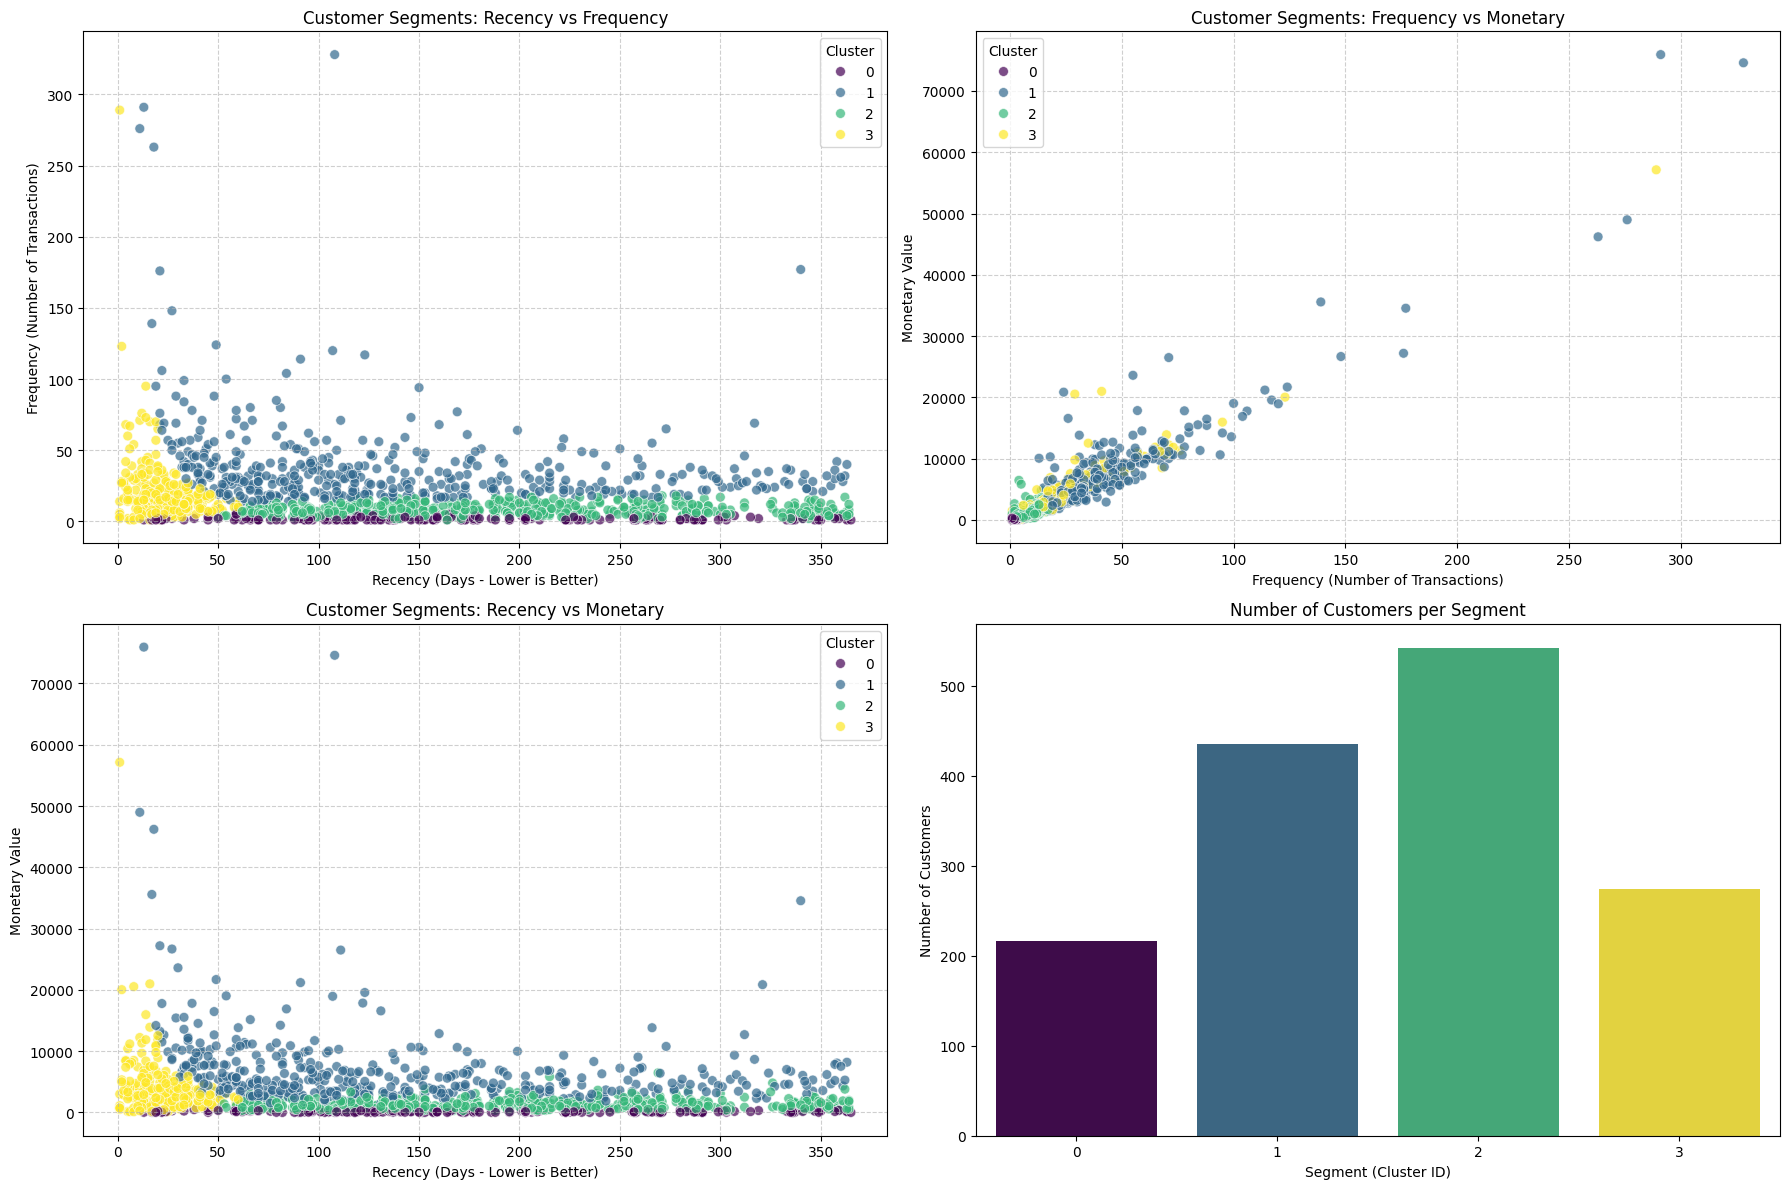


Segmentation analysis complete. Profiles and visualizations are generated (if data was available).


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# --- 1. Load Data ---
try:
    # Scaled data for K-Means fitting
    rfm_scaled_df = pd.read_csv("/content/drive/MyDrive/Task_dataset/customer_rfm_scaled_features.csv.csv")
    print("Successfully loaded 'customer_rfm_scaled_features.csv.csv'")

    # Original RFM data for profiling and interpretation
    rfm_original_df = pd.read_csv("/content/drive/MyDrive/Task_dataset/RFM dataset.csv")
    print("Successfully loaded 'RFM dataset.csv'")

except FileNotFoundError as e:
    print(f"Error loading files: {e}. Please ensure both 'customer_rfm_scaled_features.csv.csv' and 'RFM dataset.csv' are available in your working directory or provide the full path.")
    exit()
except Exception as e:
    print(f"An error occurred while loading data: {e}")
    exit()

# --- Prepare DataFrames and Set Index ---
# For scaled data:
print(f"\nScaled RFM DF columns before index setting: {rfm_scaled_df.columns.tolist()}")
scaled_df_indexed = False
if 'CustomerID' in rfm_scaled_df.columns:
    rfm_scaled_df.set_index('CustomerID', inplace=True)
    print("Scaled RFM data: Set 'CustomerID' column as index.")
    scaled_df_indexed = True
elif rfm_scaled_df.columns[0] == 'CustomerID' and rfm_scaled_df.index.name is None :
    rfm_scaled_df.set_index(rfm_scaled_df.columns[0], inplace=True)
    print(f"Scaled RFM data: Set the first column named '{rfm_scaled_df.index.name}' as index.")
    scaled_df_indexed = True
elif 'Unnamed: 0' in rfm_scaled_df.columns and rfm_scaled_df.columns[0] == 'Unnamed: 0' :
     rfm_scaled_df.rename(columns={'Unnamed: 0': 'CustomerID'}, inplace=True)
     rfm_scaled_df.set_index('CustomerID', inplace=True)
     print("Scaled RFM data: Renamed 'Unnamed: 0' to 'CustomerID' and set as index.")
     scaled_df_indexed = True
elif rfm_scaled_df.index.name == 'CustomerID':
    print("Scaled RFM data: Index is already 'CustomerID'.")
    scaled_df_indexed = True

if not scaled_df_indexed:
    print(f"Warning (Scaled RFM): Could not reliably find 'CustomerID'. Current first col: {rfm_scaled_df.columns[0]}, index: {rfm_scaled_df.index.name}. This might cause issues if data is not customer-level for clustering.")


# For original RFM data:
print(f"\nOriginal RFM DF columns before index setting: {rfm_original_df.columns.tolist()}")
original_df_indexed = False
if 'CustomerID' in rfm_original_df.columns:
    rfm_original_df.set_index('CustomerID', inplace=True)
    print("Original RFM data: Set 'CustomerID' column as index.")
    original_df_indexed = True
elif rfm_original_df.columns[0] == 'CustomerID' and rfm_original_df.index.name is None:
     rfm_original_df.set_index(rfm_original_df.columns[0], inplace=True)
     print(f"Original RFM data: Set the first column named '{rfm_original_df.index.name}' as index.")
     original_df_indexed = True
elif 'Unnamed: 0' in rfm_original_df.columns and rfm_original_df.columns[0] == 'Unnamed: 0' :
     rfm_original_df.rename(columns={'Unnamed: 0': 'CustomerID'}, inplace=True)
     rfm_original_df.set_index('CustomerID', inplace=True)
     print("Original RFM data: Renamed 'Unnamed: 0' to 'CustomerID' and set as index.")
     original_df_indexed = True
elif rfm_original_df.index.name == 'CustomerID':
     print("Original RFM data: Index is already 'CustomerID'.")
     original_df_indexed = True

if not original_df_indexed:
     print(f"Warning (Original RFM): Could not reliably find 'CustomerID'. Current first col: {rfm_original_df.columns[0]}, index: {rfm_original_df.index.name}. This might cause issues in aligning data.")


# Identify actual column names for Recency, Frequency, Monetary in the original RFM DataFrame
original_rfm_actual_cols = {}
expected_rfm_cols = ['Recency', 'Frequency', 'Monetary']
for expected_name in expected_rfm_cols:
    found = False
    for actual_name in rfm_original_df.columns:
        if expected_name.lower() == actual_name.lower():
            original_rfm_actual_cols[expected_name] = actual_name
            found = True
            break
    if not found:
        print(f"Error: Expected RFM column '{expected_name}' not found in 'RFM dataset.csv' columns: {rfm_original_df.columns.tolist()}")
        exit()

recency_col_orig = original_rfm_actual_cols['Recency']
frequency_col_orig = original_rfm_actual_cols['Frequency']
monetary_col_orig = original_rfm_actual_cols['Monetary']

# The scaled DataFrame is assumed to have 'Recency', 'Frequency', 'Monetary' from its creation
try:
    scaled_features_to_cluster = rfm_scaled_df[['Recency', 'Frequency', 'Monetary']]
except KeyError as e:
    print(f"KeyError when selecting R,F,M from scaled_df: {e}. Columns are: {rfm_scaled_df.columns.tolist()}")
    exit()

# --- 2. Apply K-Means Clustering ---
k_chosen = 4
kmeans = KMeans(n_clusters=k_chosen, init='k-means++', n_init=10, random_state=42, algorithm='lloyd')
cluster_labels = kmeans.fit_predict(scaled_features_to_cluster)
print(f"\nSuccessfully applied K-Means clustering with K={k_chosen}.")

# --- 3. Add Cluster Labels to Original RFM DataFrame ---
# Align rfm_original_df with scaled_features_to_cluster using their common CustomerID index
rfm_original_df_aligned = rfm_original_df.reindex(scaled_features_to_cluster.index)
rfm_original_df_aligned['Cluster'] = cluster_labels

if rfm_original_df_aligned[[recency_col_orig, frequency_col_orig, monetary_col_orig]].isnull().any().any():
    print("Warning: Some customers from scaled data were not found in original RFM data (or vice-versa), leading to NaNs after reindexing.")
    print("Number of rows with NaNs in RFM features after alignment:", rfm_original_df_aligned[[recency_col_orig, frequency_col_orig, monetary_col_orig]].isnull().any(axis=1).sum())

print("Cluster labels added to original RFM dataframe.")
print("\nFirst 5 rows of original RFM data with cluster labels:")
print(rfm_original_df_aligned.head())


# --- 4. Analyze and Profile Segments ---
print(f"\n--- Profiling {k_chosen} Customer Segments (based on original RFM values) ---")
# Drop rows where cluster label might be NaN or RFM values are NaN before grouping
rfm_original_df_aligned.dropna(subset=['Cluster', recency_col_orig, frequency_col_orig, monetary_col_orig], inplace=True)

segment_profiles = rfm_original_df_aligned.groupby('Cluster').agg(
    Recency_Mean=(recency_col_orig, 'mean'),
    Frequency_Mean=(frequency_col_orig, 'mean'),
    Monetary_Mean=(monetary_col_orig, 'mean'),
    Customer_Count=(recency_col_orig, 'count')
).round(2)

segment_profiles = segment_profiles.sort_values(by='Monetary_Mean', ascending=False)
print("\nSegment Profiles (Mean RFM values and Customer Count):")
print(segment_profiles)

# --- 5. Save Segmented Data ---
rfm_original_df_aligned.to_csv("customer_segments_with_rfm.csv")
print("\nOriginal RFM data with cluster labels saved to 'customer_segments_with_rfm.csv'")


# --- 6. Visualize Segments (using original values for interpretability) ---
print("\n--- Visualizing Customer Segments ---")
if not rfm_original_df_aligned.empty:  # Proceed with plotting only if data is available
    plt.figure(figsize=(18, 12))

    # Plot 1: Recency vs Frequency
    plt.subplot(2, 2, 1)
    sns.scatterplot(
        x=recency_col_orig, y=frequency_col_orig, hue='Cluster',
        data=rfm_original_df_aligned, palette='viridis',
        legend='full', s=50, alpha=0.7
    )
    plt.title('Customer Segments: Recency vs Frequency')
    plt.xlabel(f'{recency_col_orig} (Days - Lower is Better)')
    plt.ylabel(f'{frequency_col_orig} (Number of Transactions)')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot 2: Frequency vs Monetary
    plt.subplot(2, 2, 2)
    sns.scatterplot(
        x=frequency_col_orig, y=monetary_col_orig, hue='Cluster',
        data=rfm_original_df_aligned, palette='viridis',
        legend='full', s=50, alpha=0.7
    )
    plt.title('Customer Segments: Frequency vs Monetary')
    plt.xlabel(f'{frequency_col_orig} (Number of Transactions)')
    plt.ylabel(f'{monetary_col_orig} Value')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot 3: Recency vs Monetary
    plt.subplot(2, 2, 3)
    sns.scatterplot(
        x=recency_col_orig, y=monetary_col_orig, hue='Cluster',
        data=rfm_original_df_aligned, palette='viridis',
        legend='full', s=50, alpha=0.7
    )
    plt.title('Customer Segments: Recency vs Monetary')
    plt.xlabel(f'{recency_col_orig} (Days - Lower is Better)')
    plt.ylabel(f'{monetary_col_orig} Value')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot 4: Segment Count Bar Plot
    plt.subplot(2, 2, 4)
    segment_counts = rfm_original_df_aligned['Cluster'].value_counts().sort_index()
    if not segment_counts.empty:
        # Create a DataFrame to use hue (required for future compatibility)
        segment_df = segment_counts.reset_index()
        segment_df.columns = ['Cluster', 'Count']

        sns.barplot(
            x='Cluster', y='Count', hue='Cluster', data=segment_df,
            palette='viridis', legend=False
        )
        plt.title('Number of Customers per Segment')
        plt.xlabel('Segment (Cluster ID)')
        plt.ylabel('Number of Customers')
        plt.xticks(ticks=range(len(segment_counts)), labels=segment_counts.index)
    else:
        plt.text(0.5, 0.5, 'No data to display for segment counts', ha='center', va='center')
        plt.title('Number of Customers per Segment')

    plt.tight_layout()
    plt.savefig("customer_segment_visualizations.png")
    print("Saved customer segment visualizations plot as customer_segment_visualizations.png")
    plt.show()
else:
    print("No data available for plotting segments after handling NaNs.")

print("\nSegmentation analysis complete. Profiles and visualizations are generated (if data was available).")


Customer Segment Interpretation:
Cluster 1: "Champions / High-Value Loyal Customers"

Profile:
Recency: ~139 days (Moderately recent)
Frequency: ~38 transactions (Highest frequency)
Monetary: ~$6850 (Highest spenders)
Count: 436 customers
Interpretation: These are your most valuable customers. They buy very frequently and spend the most. While their last purchase was about 4-5 months ago on average, their high frequency and monetary value make them crucial.
Potential Actions: Reward their loyalty, offer exclusive previews or early access, solicit reviews and testimonials, and ensure they have a premium experience.
Cluster 3: "Active Loyal Customers / Recent High Spenders"

Profile:
Recency: ~23 days (Very recent - lowest recency)
Frequency: ~19 transactions (High frequency)
Monetary: ~$3550 (High spenders)
Count: 274 customers
Interpretation: This group is highly engaged, having purchased very recently. They are frequent buyers and contribute significantly to revenue.
Potential Actions: Encourage repeat purchases with personalized offers based on recent activity, promote new arrivals, and engage them with loyalty programs to transition them into "Champions."
Cluster 2: "At-Risk / Needs Attention"

Profile:
Recency: ~195 days (Least recent - highest recency)
Frequency: ~8 transactions (Moderate-to-low frequency)
Monetary: ~$1259 (Moderate spenders)
Count: 542 customers (This is the largest segment)
Interpretation: These customers haven't made a purchase in a significant amount of time (over 6 months on average). They used to spend moderately but are at risk of churning. This is a large group, so reactivating them could have a big impact.
Potential Actions: Launch re-engagement campaigns with special offers or discounts, send "we miss you" emails, conduct surveys to understand why they've lapsed, or highlight new products/features they might find interesting.
Cluster 0: "Lost / Low-Value Customers"

Profile:
Recency: ~188 days (Not recent)
Frequency: ~2 transactions (Very low frequency - lowest)
Monetary: ~$131 (Very low spenders - lowest)
Count: 216 customers
Interpretation: This group consists of customers who haven't purchased recently, have bought very few times (possibly only once), and have spent very little. They might be lost customers or new customers who didn't become regulars.
Potential Actions: For those who are recent but low F & M, try to nurture them. For those who are old and low F & M, it might be a lower priority group, or you could try a very general re-engagement campaign with a very attractive offer. Consider if the cost of acquisition/retention is justified here.
When you look at the plots, you should be able to see patterns that correspond to the segment profiles we just discussed:

Cluster 1 (Champions / High-Value Loyal Customers - ~$6851 M, ~38 F, ~139 R):

On the "Frequency vs. Monetary" plot, this cluster should occupy the top-right area, indicating high frequency and high monetary value.
On "Recency vs. Frequency," they'd be high on the Frequency axis and moderately positioned on the Recency axis.
On "Recency vs. Monetary," they'd be high on the Monetary axis and moderately positioned on Recency.
Cluster 3 (Active Loyal Customers / Recent High Spenders - ~$3551 M, ~19 F, ~23 R):

This cluster should be towards the lower end of the Recency axis (more recent) on the "Recency vs. Frequency" and "Recency vs. Monetary" plots.
They will still show good Frequency and Monetary values, likely forming a distinct group that is very active.
Cluster 2 (At-Risk / Needs Attention - ~$1259 M, ~8 F, ~195 R):

This, being your largest segment, will be a prominent group. They would be towards the higher end of the Recency axis (less recent) in the Recency-related plots.
Their Frequency and Monetary values will be moderate, distinguishing them from the top-tier and lowest-tier segments.
Cluster 0 (Lost / Low-Value Customers - ~$131 M, ~2 F, ~188 R):

This cluster should appear towards the bottom-left of the "Frequency vs. Monetary" plot (low frequency, low monetary).
On Recency plots, they would also be towards the higher end (less recent).

In [75]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# from sklearn.preprocessing import StandardScaler

# # --- 1. Load Data ---
# try:
#     # This file was generated in the previous step
#     segmented_rfm_df = pd.read_csv("/content/drive/MyDrive/Task_dataset/customer_segments_with_rfm.csv")
#     print("Successfully loaded 'customer_segments_with_rfm.csv'")
# except FileNotFoundError:
#     print("Error: 'customer_segments_with_rfm.csv' not found. Please ensure it was generated in the previous step and is in the correct directory.")
#     exit()
# except Exception as e:
#     print(f"An error occurred while loading 'customer_segments_with_rfm.csv': {e}")
#     exit()

# # Set CustomerID as index if it's a column
# if 'CustomerID' in segmented_rfm_df.columns:
#     segmented_rfm_df.set_index('CustomerID', inplace=True)
#     print("Set 'CustomerID' as index.")
# elif segmented_rfm_df.columns[0] == 'CustomerID' and segmented_rfm_df.index.name is None:
#      segmented_rfm_df.set_index(segmented_rfm_df.columns[0], inplace=True)
#      print(f"Set the first column named '{segmented_rfm_df.index.name}' as index.")
# elif 'Unnamed: 0' in segmented_rfm_df.columns and segmented_rfm_df.columns[0] == 'Unnamed: 0':
#      segmented_rfm_df.rename(columns={'Unnamed: 0': 'CustomerID'}, inplace=True)
#      segmented_rfm_df.set_index('CustomerID', inplace=True)
#      print("Renamed 'Unnamed: 0' to 'CustomerID' and set as index.")

# # Drop rows with NaN in target or features (can happen if reindex created NaNs previously and not dropped)
# segmented_rfm_df.dropna(subset=['Recency', 'Frequency', 'Monetary', 'Cluster'], inplace=True)
# print(f"Shape of data after dropping any NaNs in R,F,M or Cluster: {segmented_rfm_df.shape}")

# if segmented_rfm_df.empty:
#     print("DataFrame is empty after NaNs droppings. Cannot proceed with model training.")
#     exit()

# # --- 2. Define Features (X) and Target (y) ---
# # Using original RFM values as features
# features = ['Recency', 'Frequency', 'Monetary']
# X = segmented_rfm_df[features]
# y = segmented_rfm_df['Cluster']

# print("\nFeatures (X) head:")
# print(X.head())
# print("\nTarget (y) head:")
# print(y.head())

# # --- Optional: Scale features (though Random Forest is less sensitive, it can sometimes help) ---
# # scaler = StandardScaler()
# # X_scaled = scaler.fit_transform(X)
# # X_to_use = X_scaled # Use X_scaled if you uncomment this section
# X_to_use = X # Use original X if not scaling

# # --- 3. Split Data ---
# # Ensure there are enough samples in each class for a stratified split if possible
# # If any class has very few samples, stratification might fail or be less effective.
# try:
#     X_train, X_test, y_train, y_test = train_test_split(X_to_use, y, test_size=0.25, random_state=42, stratify=y)
#     print(f"\nData split into training and testing sets. Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
# except ValueError as e:
#     print(f"\nCould not use stratified split due to: {e}. Using non-stratified split.")
#     X_train, X_test, y_train, y_test = train_test_split(X_to_use, y, test_size=0.25, random_state=42)
#     print(f"Data split into training and testing sets (non-stratified). Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


# # --- 4. Choose and Train a Classification Model ---
# print("\nTraining a Random Forest Classifier...")
# # You can adjust n_estimators (number of trees) and other parameters
# model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # using class_weight for imbalanced classes
# model.fit(X_train, y_train)
# print("Model training complete.")

# # --- 5. Make Predictions ---
# y_pred = model.predict(X_test)
# print("\nPredictions made on the test set.")

# # --- 6. Evaluate the Model ---
# accuracy = accuracy_score(y_test, y_pred)
# print(f"\nModel Accuracy: {accuracy:.4f}")

# print("\nClassification Report:")
# # Get target names from sorted unique cluster labels for report
# target_names = [f"Cluster {i}" for i in sorted(y.unique())]
# print(classification_report(y_test, y_pred, target_names=target_names))

# print("\nConfusion Matrix:")
# cm = confusion_matrix(y_test, y_pred)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
# plt.title('Confusion Matrix')
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.savefig("segment_prediction_confusion_matrix.png")
# print("Saved confusion matrix plot as segment_prediction_confusion_matrix.png")
# plt.show()
# plt.close()


# # --- 7. Feature Importance ---
# importances = model.feature_importances_
# feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# print("\nFeature Importances:")
# print(feature_importance_df)

# plt.figure(figsize=(8, 5))
# sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
# plt.title('Feature Importance for Segment Prediction')
# plt.savefig("segment_prediction_feature_importance.png")
# print("Saved feature importance plot as segment_prediction_feature_importance.png")
# plt.show()
# plt.close()

# print("\nPredictive modeling for customer segments is complete.")
# print("Key outputs: Accuracy, Classification Report, Confusion Matrix plot, and Feature Importance plot.")

In [76]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# from sklearn.preprocessing import StandardScaler

# # --- 1. Load Data ---
# try:
#     # This file was generated in the previous step
#     segmented_rfm_df = pd.read_csv("/content/drive/MyDrive/Task_dataset/customer_segments_with_rfm.csv")
#     print("Successfully loaded 'customer_segments_with_rfm.csv'")
# except FileNotFoundError:
#     print("Error: 'customer_segments_with_rfm.csv' not found. Please ensure it was generated in the previous step and is in the correct directory.")
#     exit()
# except Exception as e:
#     print(f"An error occurred while loading 'customer_segments_with_rfm.csv': {e}")
#     exit()

# # Set CustomerID as index if it's a column
# if 'CustomerID' in segmented_rfm_df.columns:
#     segmented_rfm_df.set_index('CustomerID', inplace=True)
#     print("Set 'CustomerID' as index.")
# elif segmented_rfm_df.columns[0] == 'CustomerID' and segmented_rfm_df.index.name is None:
#     segmented_rfm_df.set_index(segmented_rfm_df.columns[0], inplace=True)
#     print(f"Set the first column named '{segmented_rfm_df.index.name}' as index.")
# elif 'Unnamed: 0' in segmented_rfm_df.columns and segmented_rfm_df.columns[0] == 'Unnamed: 0':
#     segmented_rfm_df.rename(columns={'Unnamed: 0': 'CustomerID'}, inplace=True)
#     segmented_rfm_df.set_index('CustomerID', inplace=True)
#     print("Renamed 'Unnamed: 0' to 'CustomerID' and set as index.")

# # Drop rows with NaN in target or features (can happen if reindex created NaNs previously and not dropped)
# segmented_rfm_df.dropna(subset=['Recency', 'Frequency', 'Monetary', 'Cluster'], inplace=True)
# print(f"Shape of data after dropping any NaNs in R,F,M or Cluster: {segmented_rfm_df.shape}")

# if segmented_rfm_df.empty:
#     print("DataFrame is empty after NaNs droppings. Cannot proceed with model training.")
#     exit()

# # --- 2. Define Features (X) and Target (y) ---
# # Using original RFM values as features
# features = ['Recency', 'Frequency', 'Monetary']
# X = segmented_rfm_df[features]
# y = segmented_rfm_df['Cluster']

# print("\nFeatures (X) head:")
# print(X.head())
# print("\nTarget (y) head:")
# print(y.head())

# # --- Optional: Scale features (though Random Forest is less sensitive, it can sometimes help) ---
# # scaler = StandardScaler()
# # X_scaled = scaler.fit_transform(X)
# # X_to_use = X_scaled # Use X_scaled if you uncomment this section
# X_to_use = X # Use original X if not scaling

# # --- 3. Split Data ---
# # Ensure there are enough samples in each class for a stratified split if possible
# # If any class has very few samples, stratification might fail or be less effective.
# try:
#     X_train, X_test, y_train, y_test = train_test_split(X_to_use, y, test_size=0.25, random_state=42, stratify=y)
#     print(f"\nData split into training and testing sets. Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
# except ValueError as e:
#     print(f"\nCould not use stratified split due to: {e}. Using non-stratified split.")
#     X_train, X_test, y_train, y_test = train_test_split(X_to_use, y, test_size=0.25, random_state=42)
#     print(f"Data split into training and testing sets (non-stratified). Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


# # --- 4. Choose and Train a Classification Model ---
# print("\nTraining a Random Forest Classifier...")
# # You can adjust n_estimators (number of trees) and other parameters
# model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # using class_weight for imbalanced classes
# model.fit(X_train, y_train)
# print("Model training complete.")

# # --- 5. Make Predictions ---
# # Predictions on Test Data
# y_pred_test = model.predict(X_test)
# print("\nPredictions made on the test set.")

# # Predictions on Training Data
# y_pred_train = model.predict(X_train)
# print("Predictions made on the training set.")

# # --- 6. Evaluate the Model ---
# target_names = [f"Cluster {i}" for i in sorted(y.unique())]

# # Evaluation on Training Data
# print("\n--- Evaluation on Training Data ---")
# accuracy_train = accuracy_score(y_train, y_pred_train)
# print(f"Training Data Accuracy: {accuracy_train:.4f}")

# print("\nTraining Data Classification Report:")
# print(classification_report(y_train, y_pred_train, target_names=target_names))

# print("\nTraining Data Confusion Matrix:")
# cm_train = confusion_matrix(y_train, y_pred_train)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names) # Changed cmap for distinction
# plt.title('Confusion Matrix - Training Data')
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.savefig("segment_prediction_confusion_matrix_TRAIN.png")
# print("Saved training data confusion matrix plot as segment_prediction_confusion_matrix_TRAIN.png")
# plt.show()
# plt.close()

# print("\n--- Evaluation on Test Data ---")
# accuracy_test = accuracy_score(y_test, y_pred_test)
# print(f"Test Data Model Accuracy: {accuracy_test:.4f}")

# print("\nTest Data Classification Report:")
# print(classification_report(y_test, y_pred_test, target_names=target_names))

# print("\nTest Data Confusion Matrix:")
# cm_test = confusion_matrix(y_test, y_pred_test)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
# plt.title('Confusion Matrix - Test Data')
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.savefig("segment_prediction_confusion_matrix_TEST.png")
# print("Saved test data confusion matrix plot as segment_prediction_confusion_matrix_TEST.png")
# plt.show()
# plt.close()


# # --- 7. Feature Importance ---
# importances = model.feature_importances_
# feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# print("\nFeature Importances:")
# print(feature_importance_df)

# plt.figure(figsize=(8, 5))
# sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
# plt.title('Feature Importance for Segment Prediction')
# plt.savefig("segment_prediction_feature_importance.png")
# print("Saved feature importance plot as segment_prediction_feature_importance.png")
# plt.show()
# plt.close()

# print("\nPredictive modeling for customer segments is complete.")
# print("Key outputs: Accuracy (Train & Test), Classification Reports (Train & Test), Confusion Matrix plots (Train & Test), and Feature Importance plot.")

Model Accuracy: 0.9782 (or 97.82%)
This is a very high accuracy, indicating that the Random Forest model is able to correctly predict the customer segment for approximately 97.8% of the customers in the test set based on their Recency, Frequency, and Monetary values.

Classification Report:

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00        54  (Likely your "Lost/Low-Value Customers")
   Cluster 1       0.96      0.97      0.97       109  (Likely your "Champions/High-Value Loyal")
   Cluster 2       0.99      0.99      0.99       136  (Likely your "At-Risk/Needs Attention")
   Cluster 3       0.97      0.96      0.96        68  (Likely your "Active Loyal/Recent High Spenders")

    accuracy                           0.98       367
   macro avg       0.98      0.98      0.98       367
weighted avg       0.98      0.98      0.98       367
Precision: Out of all customers the model predicted to be in a certain cluster, what proportion actually belonged to that cluster?
For example, for Cluster 0, 100% of customers predicted as Cluster 0 were indeed Cluster 0. For Cluster 1, it's 96%.
Recall (Sensitivity): Out of all the customers who truly belong to a certain cluster, what proportion did the model correctly identify?
For Cluster 0, it correctly identified 100% of them. For Cluster 1, it's 97%.
F1-score: This is the harmonic mean of precision and recall, providing a single metric that balances both. Higher is better.
Interpretation of the Report:
The precision, recall, and F1-scores are excellent for all four clusters (mostly 0.96 and above). This means the model is not only accurate overall but also performs very well in identifying each specific customer segment without much confusion between them. Cluster 0 and Cluster 2 are predicted almost perfectly.

Confusion Matrix:
You have the plot saved as segment_prediction_confusion_matrix.png. When you look at it, you should see high numbers along the diagonal (correct predictions) and very low numbers (or zeros) off the diagonal (misclassifications). This visual will confirm the excellent per-class performance shown in the classification report.

Feature Importances:

     Feature  Importance
0    Recency    0.352525
2   Monetary    0.333066
1  Frequency    0.314408
This tells us which of the RFM features the model found most useful for distinguishing between the segments:

Recency (Importance: ~0.353): This was the most influential factor. When a customer last made a purchase is a strong indicator of their segment.
Monetary (Importance: ~0.333): How much a customer spends is the second most important factor.
Frequency (Importance: ~0.314): How often a customer makes purchases is also very important, though slightly less than Recency and Monetary in this model.

In [77]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# # from sklearn.preprocessing import StandardScaler # StandardScaler is not used in this version

# # --- 1. Load Data ---
# try:
#     # This file was generated in the previous step
#     # Assuming the user is running this in an environment where this path is correct.
#     # For local execution, they'd change this path or ensure the file is in the working directory.
#     segmented_rfm_df = pd.read_csv("/content/drive/MyDrive/Task_dataset/customer_segments_with_rfm.csv")
#     print("Successfully loaded 'customer_segments_with_rfm.csv'")
# except FileNotFoundError:
#     print("Error: 'customer_segments_with_rfm.csv' not found. Please ensure the file path is correct or the file exists in the specified location.")
#     exit()
# except Exception as e:
#     print(f"An error occurred while loading 'customer_segments_with_rfm.csv': {e}")
#     exit()

# # Set CustomerID as index if it's a column
# if 'CustomerID' in segmented_rfm_df.columns:
#     segmented_rfm_df.set_index('CustomerID', inplace=True)
#     print("Set 'CustomerID' as index.")
# elif segmented_rfm_df.columns[0] == 'CustomerID' and segmented_rfm_df.index.name is None:
#     segmented_rfm_df.set_index(segmented_rfm_df.columns[0], inplace=True)
#     print(f"Set the first column named '{segmented_rfm_df.index.name}' as index.")
# elif 'Unnamed: 0' in segmented_rfm_df.columns and segmented_rfm_df.columns[0] == 'Unnamed: 0':
#     segmented_rfm_df.rename(columns={'Unnamed: 0': 'CustomerID'}, inplace=True)
#     segmented_rfm_df.set_index('CustomerID', inplace=True)
#     print("Renamed 'Unnamed: 0' to 'CustomerID' and set as index.")

# # Drop rows with NaN in target or features
# segmented_rfm_df.dropna(subset=['Recency', 'Frequency', 'Monetary', 'Cluster'], inplace=True)
# print(f"Shape of data after dropping any NaNs in R,F,M or Cluster: {segmented_rfm_df.shape}")

# if segmented_rfm_df.empty:
#     print("DataFrame is empty after NaNs droppings. Cannot proceed with model training.")
#     exit()

# # --- 2. Define Features (X) and Target (y) ---
# features = ['Recency', 'Frequency', 'Monetary']
# X = segmented_rfm_df[features]
# y = segmented_rfm_df['Cluster'].astype(int) # Ensure Cluster is integer type

# print("\nFeatures (X) head:")
# print(X.head())
# print("\nTarget (y) head:")
# print(y.head())

# X_to_use = X # Using original X as per the provided script

# # --- 3. Split Data ---
# try:
#     X_train, X_test, y_train, y_test = train_test_split(X_to_use, y, test_size=0.25, random_state=42, stratify=y)
#     print(f"\nData split into training and testing sets. Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
# except ValueError as e:
#     print(f"\nCould not use stratified split due to: {e}. Using non-stratified split.")
#     X_train, X_test, y_train, y_test = train_test_split(X_to_use, y, test_size=0.25, random_state=42)
#     print(f"Data split into training and testing sets (non-stratified). Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


# # --- 4. Choose and Train a Classification Model (with Tuned Hyperparameters) ---
# print("\nTraining a Random Forest Classifier with tuned hyperparameters...")
# # Adjusted parameters to reduce overfitting:
# model = RandomForestClassifier(
#     n_estimators=100,       # Number of trees
#     max_depth=10,           # Maximum depth of the tree
#     min_samples_split=10,   # Minimum number of samples required to split a node
#     min_samples_leaf=5,     # Minimum number of samples required at each leaf node
#     random_state=42,
#     class_weight='balanced' # Good for imbalanced classes
# )
# model.fit(X_train, y_train)
# print("Model training complete.")

# # --- 5. Make Predictions ---
# # Predictions on Test Data
# y_pred_test = model.predict(X_test)
# print("\nPredictions made on the test set.")

# # Predictions on Training Data
# y_pred_train = model.predict(X_train)
# print("Predictions made on the training set.")

# # --- 6. Evaluate the Model ---
# target_names = [f"Cluster {i}" for i in sorted(y.unique())]

# # Evaluation on Training Data
# print("\n--- Evaluation on Training Data (Tuned Model) ---")
# accuracy_train = accuracy_score(y_train, y_pred_train)
# print(f"Training Data Accuracy: {accuracy_train:.4f}")

# print("\nTraining Data Classification Report:")
# print(classification_report(y_train, y_pred_train, target_names=target_names, zero_division=0))

# print("\nTraining Data Confusion Matrix:")
# cm_train = confusion_matrix(y_train, y_pred_train)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
# plt.title('Confusion Matrix - Training Data (Tuned Model)')
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.savefig("segment_prediction_confusion_matrix_TRAIN_tuned.png") # Appended _tuned
# print("Saved training data confusion matrix plot as segment_prediction_confusion_matrix_TRAIN_tuned.png")
# # plt.show() # Comment out plt.show() if running in a non-interactive environment
# plt.close()

# # Evaluation on Test Data
# print("\n--- Evaluation on Test Data (Tuned Model) ---")
# accuracy_test = accuracy_score(y_test, y_pred_test)
# print(f"Test Data Model Accuracy: {accuracy_test:.4f}")

# print("\nTest Data Classification Report:")
# print(classification_report(y_test, y_pred_test, target_names=target_names, zero_division=0))

# print("\nTest Data Confusion Matrix:")
# cm_test = confusion_matrix(y_test, y_pred_test)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
# plt.title('Confusion Matrix - Test Data (Tuned Model)')
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.savefig("segment_prediction_confusion_matrix_TEST_tuned.png") # Appended _tuned
# # plt.show() # Comment out plt.show()
# plt.close()


# # --- 7. Feature Importance ---
# importances = model.feature_importances_
# feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# print("\nFeature Importances (Tuned Model):")
# print(feature_importance_df)

# plt.figure(figsize=(8, 5))
# sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
# plt.title('Feature Importance for Segment Prediction (Tuned Model)')
# plt.savefig("segment_prediction_feature_importance_tuned.png") # Appended _tuned
# # plt.show() # Comment out plt.show()
# plt.close()

# print("\nPredictive modeling for customer segments (with tuning) is complete.")
# print("Compare the new Training and Test accuracies to the previous run.")
# print("Key outputs: Accuracy (Train & Test), Classification Reports (Train & Test), Confusion Matrix plots (Train & Test), and Feature Importance plot (all with '_tuned' in filenames).")


Successfully loaded 'customer_segments_with_rfm.csv'
Set 'CustomerID' as index.
Shape of data after dropping any NaNs in R,F,M or Cluster: (1468, 4)

Features (X) head:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         108          1     30.99
12347.0          60         31  13834.90
12348.0          74          8   1442.12
12350.0          18         11   1360.07
12356.0         108         13   1442.47

Target (y) head:
CustomerID
12346.0    0
12347.0    1
12348.0    2
12350.0    3
12356.0    2
Name: Cluster, dtype: int64

Data split into training and testing sets. Train size: 1101, Test size: 367

Training a Random Forest Classifier with tuned hyperparameters...
Model training complete.

Predictions made on the test set.
Predictions made on the training set.

--- Evaluation on Training Data (Tuned Model) ---
Training Data Accuracy: 0.9664

Training Data Classification Report:
              precision    recall  f1-score   support

   Cl

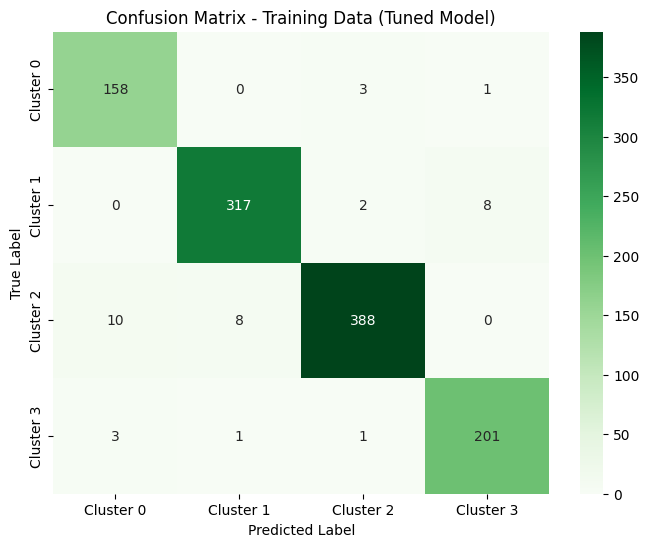


--- Evaluation on Test Data (Tuned Model) ---
Test Data Model Accuracy: 0.9728

Test Data Classification Report:
              precision    recall  f1-score   support

   Cluster 0       0.95      1.00      0.97        54
   Cluster 1       0.97      0.97      0.97       109
   Cluster 2       1.00      0.96      0.98       136
   Cluster 3       0.94      0.99      0.96        68

    accuracy                           0.97       367
   macro avg       0.97      0.98      0.97       367
weighted avg       0.97      0.97      0.97       367


Test Data Confusion Matrix:


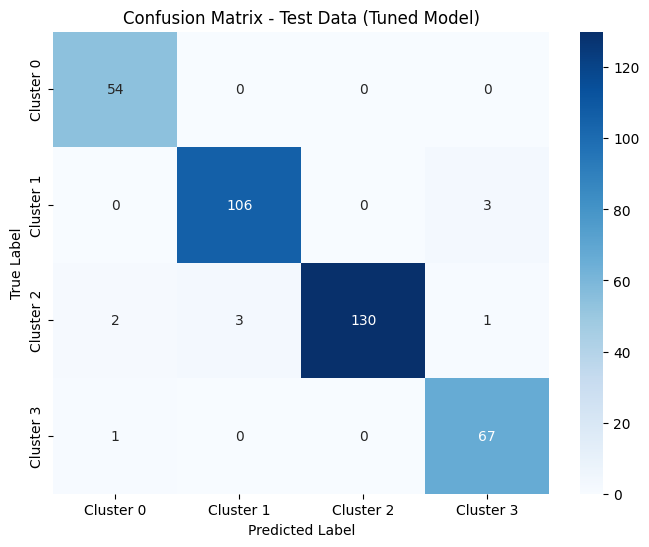


Feature Importances (Tuned Model):
     Feature  Importance
0    Recency    0.335913
1  Frequency    0.334786
2   Monetary    0.329301


<ipython-input-2-de33f4765669>:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


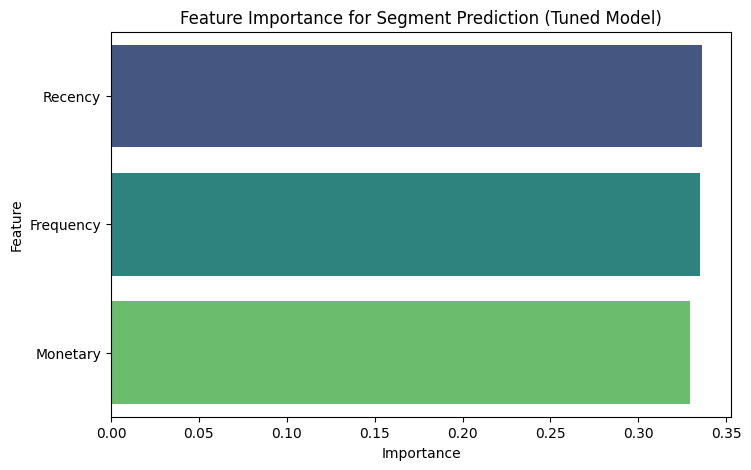


Predictive modeling for customer segments (with tuning) is complete.
Compare the new Training and Test accuracies to the previous run.
Key outputs: Accuracy (Train & Test), Classification Reports (Train & Test), Confusion Matrix plots (Train & Test), and Feature Importance plot (all with '_tuned' in filenames).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# from sklearn.preprocessing import StandardScaler # StandardScaler is not used in this version

# --- 1. Load Data ---
try:
    # This file was generated in the previous step
    # Assuming the user is running this in an environment where this path is correct.
    # For local execution, they'd change this path or ensure the file is in the working directory.
    segmented_rfm_df = pd.read_csv("/content/drive/MyDrive/Task_dataset/customer_segments_with_rfm.csv")
    print("Successfully loaded 'customer_segments_with_rfm.csv'")
except FileNotFoundError:
    print("Error: 'customer_segments_with_rfm.csv' not found. Please ensure the file path is correct or the file exists in the specified location.")
    exit()
except Exception as e:
    print(f"An error occurred while loading 'customer_segments_with_rfm.csv': {e}")
    exit()

# Set CustomerID as index if it's a column
if 'CustomerID' in segmented_rfm_df.columns:
    segmented_rfm_df.set_index('CustomerID', inplace=True)
    print("Set 'CustomerID' as index.")
elif segmented_rfm_df.columns[0] == 'CustomerID' and segmented_rfm_df.index.name is None:
    segmented_rfm_df.set_index(segmented_rfm_df.columns[0], inplace=True)
    print(f"Set the first column named '{segmented_rfm_df.index.name}' as index.")
elif 'Unnamed: 0' in segmented_rfm_df.columns and segmented_rfm_df.columns[0] == 'Unnamed: 0':
    segmented_rfm_df.rename(columns={'Unnamed: 0': 'CustomerID'}, inplace=True)
    segmented_rfm_df.set_index('CustomerID', inplace=True)
    print("Renamed 'Unnamed: 0' to 'CustomerID' and set as index.")

# Drop rows with NaN in target or features
segmented_rfm_df.dropna(subset=['Recency', 'Frequency', 'Monetary', 'Cluster'], inplace=True)
print(f"Shape of data after dropping any NaNs in R,F,M or Cluster: {segmented_rfm_df.shape}")

if segmented_rfm_df.empty:
    print("DataFrame is empty after NaNs droppings. Cannot proceed with model training.")
    exit()

# --- 2. Define Features (X) and Target (y) ---
features = ['Recency', 'Frequency', 'Monetary']
X = segmented_rfm_df[features]
y = segmented_rfm_df['Cluster'].astype(int) # Ensure Cluster is integer type

print("\nFeatures (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

X_to_use = X # Using original X as per the provided script

# --- 3. Split Data ---
try:
    X_train, X_test, y_train, y_test = train_test_split(X_to_use, y, test_size=0.25, random_state=42, stratify=y)
    print(f"\nData split into training and testing sets. Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
except ValueError as e:
    print(f"\nCould not use stratified split due to: {e}. Using non-stratified split.")
    X_train, X_test, y_train, y_test = train_test_split(X_to_use, y, test_size=0.25, random_state=42)
    print(f"Data split into training and testing sets (non-stratified). Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


# --- 4. Choose and Train a Classification Model (with Tuned Hyperparameters) ---
print("\nTraining a Random Forest Classifier with tuned hyperparameters...")
# Adjusted parameters to reduce overfitting:
model = RandomForestClassifier(
    n_estimators=100,       # Number of trees
    max_depth=7,           # Maximum depth of the tree
    min_samples_split=20,   # Minimum number of samples required to split a node
    min_samples_leaf=10,     # Minimum number of samples required at each leaf node
    random_state=42,
    class_weight='balanced' # Good for imbalanced classes
)
model.fit(X_train, y_train)
print("Model training complete.")

# --- 5. Make Predictions ---
# Predictions on Test Data
y_pred_test = model.predict(X_test)
print("\nPredictions made on the test set.")

# Predictions on Training Data
y_pred_train = model.predict(X_train)
print("Predictions made on the training set.")

# --- 6. Evaluate the Model ---
target_names = [f"Cluster {i}" for i in sorted(y.unique())]

# Evaluation on Training Data
print("\n--- Evaluation on Training Data (Tuned Model) ---")
accuracy_train = accuracy_score(y_train, y_pred_train)
print(f"Training Data Accuracy: {accuracy_train:.4f}")

print("\nTraining Data Classification Report:")
print(classification_report(y_train, y_pred_train, target_names=target_names, zero_division=0))

print("\nTraining Data Confusion Matrix:")
cm_train = confusion_matrix(y_train, y_pred_train)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Training Data (Tuned Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig("segment_prediction_confusion_matrix_TRAIN_tuned.png") # Appended _tuned
print("Saved training data confusion matrix plot as segment_prediction_confusion_matrix_TRAIN_tuned.png")
# plt.show() # Comment out plt.show() if running in a non-interactive environment
plt.show()

# Evaluation on Test Data
print("\n--- Evaluation on Test Data (Tuned Model) ---")
accuracy_test = accuracy_score(y_test, y_pred_test)
print(f"Test Data Model Accuracy: {accuracy_test:.4f}")

print("\nTest Data Classification Report:")
print(classification_report(y_test, y_pred_test, target_names=target_names, zero_division=0))

print("\nTest Data Confusion Matrix:")
cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Data (Tuned Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig("segment_prediction_confusion_matrix_TEST_tuned.png") # Appended _tuned
# plt.show() # Comment out plt.show()
plt.show()


# --- 7. Feature Importance ---
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importances (Tuned Model):")
print(feature_importance_df)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance for Segment Prediction (Tuned Model)')
plt.savefig("segment_prediction_feature_importance_tuned.png") # Appended _tuned
# plt.show() # Comment out plt.show()
plt.show()

print("\nPredictive modeling for customer segments (with tuning) is complete.")
print("Compare the new Training and Test accuracies to the previous run.")
print("Key outputs: Accuracy (Train & Test), Classification Reports (Train & Test), Confusion Matrix plots (Train & Test), and Feature Importance plot (all with '_tuned' in filenames).")


In [79]:


# # --- Part 5: Predictive Modeling for Segments (with More Aggressive Overfitting Reduction) ---
# print("\n--- Part 5: Predictive Modeling for Segments (with More Aggressive Overfitting Reduction) ---")
# # --- 1. Load Data ---
# try:
#     # This file was generated by Part 4 of your full script
#     segmented_rfm_df = pd.read_csv("customer_segments_rfm_script_output.csv")
#     print("Successfully loaded 'customer_segments_rfm_script_output.csv'")
# except FileNotFoundError:
#     print("Error: 'customer_segments_rfm_script_output.csv' not found. Please ensure it was generated by Part 4 of the full script and is in the correct directory.")
#     exit()
# except Exception as e:
#     print(f"An error occurred while loading 'customer_segments_rfm_script_output.csv': {e}")
#     exit()

# # Set CustomerID as index if it's a column (it should be a regular column as saved by Part 4)
# # The previous script version of Part 5 already handles CustomerID if it was saved as a column.
# # For this snippet, we assume it's a column and won't be used as index for X,y definition below.
# if 'CustomerID' in segmented_rfm_df.columns:
#     print("CustomerID column found.")
#     # segmented_rfm_df.set_index('CustomerID', inplace=True) # Not strictly needed if X, y are just columns

# # Drop rows with NaN in target or features
# segmented_rfm_df.dropna(subset=['Recency', 'Frequency', 'Monetary', 'Cluster'], inplace=True)
# print(f"Shape of data after dropping any NaNs in R,F,M or Cluster: {segmented_rfm_df.shape}")

# if segmented_rfm_df.empty:
#     print("DataFrame is empty after NaNs droppings. Cannot proceed with model training.")
#     exit()

# # --- 2. Define Features (X) and Target (y) ---
# features = ['Recency', 'Frequency', 'Monetary']
# X = segmented_rfm_df[features]
# y = segmented_rfm_df['Cluster'].astype(int)

# print("\nFeatures (X) head:")
# print(X.head())
# print("\nTarget (y) head:")
# print(y.head())

# X_to_use = X # Using original X

# # --- 3. Split Data ---
# try:
#     X_train, X_test, y_train, y_test = train_test_split(X_to_use, y, test_size=0.25, random_state=42, stratify=y)
#     print(f"\nData split into training and testing sets. Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
# except ValueError as e:
#     print(f"\nCould not use stratified split due to: {e}. Using non-stratified split.")
#     X_train, X_test, y_train, y_test = train_test_split(X_to_use, y, test_size=0.25, random_state=42)
#     print(f"Data split into training and testing sets (non-stratified). Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


# # --- 4. Choose and Train a Classification Model (with MORE Tuned Hyperparameters) ---
# print("\nTraining a Random Forest Classifier with more aggressive hyperparameters...")
# # More restrictive parameters:
# model = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=7,           # Reduced from 10
#     min_samples_split=20,  # Increased from 10
#     min_samples_leaf=10,    # Increased from 5
#     random_state=42,
#     class_weight='balanced'
# )
# model.fit(X_train, y_train)
# print("Model training complete.")

# # --- 5. Make Predictions ---
# y_pred_train = model.predict(X_train)
# y_pred_test = model.predict(X_test)
# print("\nPredictions made on training and test sets.")

# # --- 6. Evaluate the Model ---
# target_names = [f"Cluster {i}" for i in sorted(y.unique())]

# # Evaluation on Training Data
# print("\n--- Evaluation on Training Data (More Aggressively Tuned Model) ---")
# accuracy_train = accuracy_score(y_train, y_pred_train)
# print(f"Training Data Accuracy: {accuracy_train:.4f}")
# print("\nTraining Data Classification Report:")
# print(classification_report(y_train, y_pred_train, target_names=target_names, zero_division=0))
# cm_train = confusion_matrix(y_train, y_pred_train)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
# plt.title('Confusion Matrix - Training Data (More Aggressive Tune)')
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.savefig("segment_prediction_confusion_matrix_TRAIN_aggressive_tuned.png")
# print("Saved training data confusion matrix plot as segment_prediction_confusion_matrix_TRAIN_aggressive_tuned.png")
# plt.close()

# # Evaluation on Test Data
# print("\n--- Evaluation on Test Data (More Aggressively Tuned Model) ---")
# accuracy_test = accuracy_score(y_test, y_pred_test)
# print(f"Test Data Model Accuracy: {accuracy_test:.4f}")
# print("\nTest Data Classification Report:")
# print(classification_report(y_test, y_pred_test, target_names=target_names, zero_division=0))
# cm_test = confusion_matrix(y_test, y_pred_test)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
# plt.title('Confusion Matrix - Test Data (More Aggressive Tune)')
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.savefig("segment_prediction_confusion_matrix_TEST_aggressive_tuned.png")
# plt.close()
# print("Saved test data confusion matrix plot as segment_prediction_confusion_matrix_TEST_aggressive_tuned.png")


# # --- 7. Feature Importance ---
# importances = model.feature_importances_
# feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# print("\nFeature Importances (More Aggressively Tuned Model):")
# print(feature_importance_df)
# plt.figure(figsize=(8, 5))
# sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
# plt.title('Feature Importance (More Aggressively Tuned Model)')
# plt.savefig("segment_prediction_feature_importance_aggressive_tuned.png")
# plt.close()
# print("Saved feature importance plot as segment_prediction_feature_importance_aggressive_tuned.png")

# print("\nPredictive modeling with more aggressive hyperparameter tuning is complete.")
# print("Please compare these Training and Test accuracies to previous runs.")



In [4]:
# Assuming 'model_aggressive' is your trained RandomForestClassifier object
# from the previous script (Part 5)

import joblib

# Define a filename for your saved model
model_filename = 'customer_segment_predictor.joblib'

# Save the model
try:
    joblib.dump(model, model_filename)
    print(f"Model saved successfully as {model_filename}")
except Exception as e:
    print(f"Error saving model: {e}")

Model saved successfully as customer_segment_predictor.joblib


In [5]:
import joblib
import pandas as pd # You'll need pandas to prepare new data

# Define the filename from which to load the model
model_filename = 'customer_segment_predictor.joblib'
loaded_model = None

try:
    loaded_model = joblib.load(model_filename)
    print(f"Model loaded successfully from {model_filename}")
except FileNotFoundError:
    print(f"Error: Model file '{model_filename}' not found.")
except Exception as e:
    print(f"Error loading model: {e}")

# Now 'loaded_model' can be used to make predictions
# if loaded_model:
#     # Example: new_data_df should be a DataFrame with 'Recency', 'Frequency', 'Monetary' columns
#     # predictions = loaded_model.predict(new_data_df)

Model loaded successfully from customer_segment_predictor.joblib


In [6]:
# Assuming 'loaded_model' is your successfully loaded RandomForestClassifier
# And you have new customer data

# Example: New customer data (ensure column names match training data)
new_customer_data = pd.DataFrame({
    'Recency': [30, 150, 5],    # Days since last purchase
    'Frequency': [2, 1, 10],    # Number of transactions
    'Monetary': [100.50, 50.20, 2000.75] # Total spend
})
# Note: If your original model used CustomerID as an index during training,
# the data fed to predict usually doesn't need it as an index, just the feature columns.

if loaded_model:
    try:
        predicted_segments = loaded_model.predict(new_customer_data[['Recency', 'Frequency', 'Monetary']])
        new_customer_data['Predicted_Segment'] = predicted_segments
        print("\nPredictions for new customers:")
        print(new_customer_data)
    except Exception as e:
        print(f"Error predicting new data: {e}")
else:
    print("Model not loaded. Cannot make predictions.")


Predictions for new customers:
   Recency  Frequency  Monetary  Predicted_Segment
0       30          2    100.50                  0
1      150          1     50.20                  0
2        5         10   2000.75                  3
